# Firehose Emergence With An Eigenmode Seed

This notebook isolates the firehose study from the larger anisotropic MHD notebook and uses a **linear unstable eigenmode** as the initial perturbation.

In the CGL model, the firehose instability appears when pressure along the magnetic field becomes so large that magnetic tension can no longer straighten bent field lines. In the simplest 1D setting used here, the working margin is

$$
\Lambda_{\mathrm{fh}} = p_\parallel - p_\perp - B^2,
$$

with closure

$$
p_\parallel = \rho^3 / B^2, \qquad p_\perp = \rho B.
$$

If $\Lambda_{\mathrm{fh}} > 0$, the equilibrium is already on the unstable side of the CGL firehose threshold. That still does not guarantee a useful nonlinear run: dissipation may damp the relevant Fourier mode, or the numerics may lose resolution before the physical growth is interpretable. This notebook therefore connects three layers on purpose:

- equilibrium diagnostics that say whether the background is firehose-prone at all,
- a dissipative linear eigenanalysis that finds a specific growing transverse mode,
- guarded nonlinear Dedalus runs that test whether that mode produces bounded early-time growth in practice.

Goals:
- pick a dense uniform CGL equilibrium with positive firehose drive,
- find a Fourier mode with positive linear growth after viscosity and resistivity are included,
- seed the nonlinear Dedalus run with that eigenmode,
- tune dissipation and amplitude so the solution stays finite in time and does not simply blow up numerically.

Code organization:
- reusable numerical kernels, Dedalus runners, and analysis utilities live in `firehose_eigenmode_helpers.py`,
- notebook cells focus on parameter studies, plotting, and interpretation,
- when the helper file changes, rerun the helper import cell to refresh the notebook namespace.

Reading guide: increasing $\rho_0$ boosts $p_\parallel$ quickly, while increasing the guide field $B_{x0}$ strengthens magnetic tension and usually suppresses the instability. The scan section below is essentially measuring where that balance flips after dissipation is included.

### Setup and Imports

Load standard scientific Python packages (NumPy, Pandas, Matplotlib, PyTorch) and set global CGL closure parameters used throughout every calculation:

| Symbol | Value | Meaning |
|--------|-------|---------|
| $\gamma_\parallel$ | 3.0 | Parallel adiabatic index (CGL) |
| $\gamma_\perp$ | 2.0 | Perpendicular adiabatic index (CGL) |
| `B_floor` | $10^{-6}$ | Small regularisation to avoid division by zero in $|B|$ |

The helper module `firehose_eigenmode_helpers` (`fh`) is imported from the local `notebooks/` directory. It contains all reusable numerical kernels: CGL closure evaluation, linearised eigenvalue problems, Dedalus IVP runner, ML model definition, and training loops. The module is `reload()`-ed so that edits to the helper file take effect without restarting the kernel.

In [1]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'          # or 'dejavusans'
mpl.rcParams['font.family'] = 'STIXGeneral'       # optional: prefer STIXGeneral
import torch

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Import helpers from the local notebooks directory so the notebook stays relocatable.
NOTEBOOK_DIR = Path('/Users/u0167590/github/dedalus/notebooks')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# CGL closure parameters and a small field floor used throughout the study.
gamma_par = 3.0
gamma_perp = 2.0
B_floor = 1e-6

ml_device = 'cpu'
torch.set_default_dtype(torch.float64)

In [2]:
import firehose_eigenmode_helpers as fh
# Reload during iterative notebook work so helper edits take effect without restarting the kernel.
fh = reload(fh)
print(f'Loaded notebook helpers from {fh.__file__}')

Loaded notebook helpers from /Users/u0167590/github/dedalus/notebooks/firehose_eigenmode_helpers.py


## Linear Scan For A Dense Unstable Equilibrium

The scan below includes viscosity and resistivity directly in the linear operator

$$
\partial_t q = \left(-i k A - k^2 D\right) q,
$$

so the selected mode is already being tested against the same damping model used later in the nonlinear run.

Two details matter here:

- We are not merely looking for the largest algebraic eigenvalue. The helper logic also prefers a strongly transverse eigenvector, because the firehose branch of interest should bend the field rather than behave mainly like a compressive acoustic fluctuation.
- A positive equilibrium firehose margin is necessary but not sufficient. The mode still has to keep a positive real growth rate after dissipation is applied.

The purpose of this section is therefore to find a background state and wavelength that are both physically firehose-prone and numerically viable as an initial condition.

,rho0,Bx0,mode_number,k_phys,firehose_margin,growth_rate,frequency,transverse_fraction
0,3.0000,0.500000,4,2.094395,106.250000,12.452448,0.0,1.0
1,2.6875,0.500000,4,2.094395,76.049805,11.129201,0.0,1.0
2,2.3750,0.500000,4,2.094395,52.148437,9.801566,0.0,1.0
3,3.0000,0.500000,3,1.570796,106.250000,9.341529,0.0,1.0
4,3.0000,0.708333,4,2.094395,51.186413,8.639484,0.0,1.0
5,2.0625,0.500000,4,2.094395,33.813477,8.467183,0.0,1.0
6,2.6875,0.500000,3,1.570796,76.049805,8.349158,0.0,1.0
7,2.6875,0.708333,4,2.094395,36.282064,7.683350,0.0,1.0
8,2.3750,0.500000,3,1.570796,52.148437,7.353512,0.0,1.0
9,1.7500,0.500000,4,2.094395,20.312500,7.121663,0.0,1.0


Selected equilibrium parameters:


,rho0,Bx0,mode_number,k_phys,growth_rate,frequency,firehose_margin
0,2.6875,1.125,1,0.523599,1.060858,0.0,11.047936


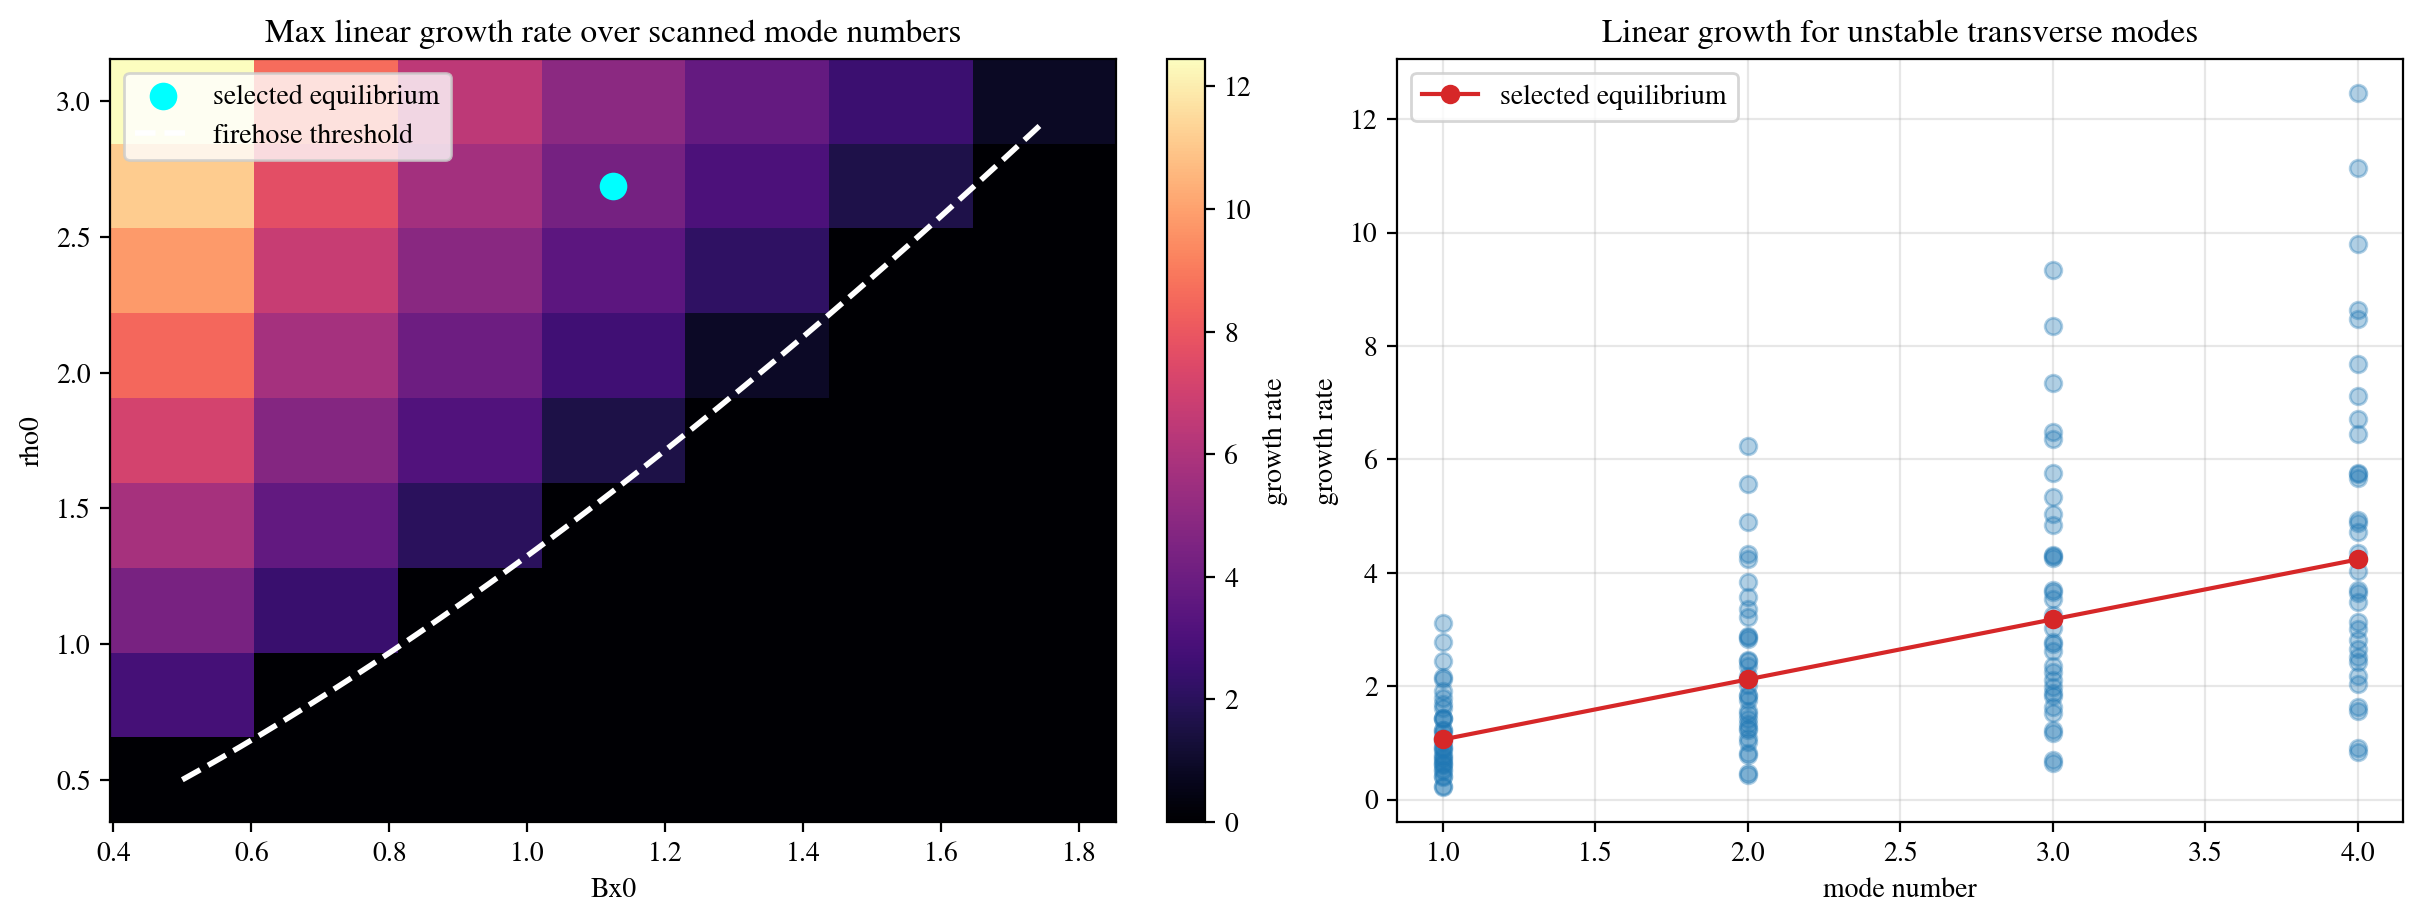

Selected equilibrium: rho0=2.688, Bx0=1.125, mode=1, growth=1.0609e+00


In [33]:
Lx = 12.0
# ── Dissipation for the linear scan ──────────────────────────────────────
scan_mu  = 4.0e-3  # Intermediate dissipation — between conservative (5e-3) and hard (3e-3).
scan_eta = 4.0e-3

# ── Scan window: moderately wide ─────────────────────────────────────────
scan_B_min, scan_B_max     = 0.5, 1.75 #0.75, 1.5
scan_rho_min, scan_rho_max = 0.5, 3.0 #1.0, 2.25  # Moderately into the unstable region
rho_values   = np.linspace(scan_rho_min, scan_rho_max, 9)
Bx_values    = np.linspace(scan_B_min, scan_B_max, 7)
mode_numbers = np.arange(1, 5)

scan_rows = []
for rho0 in rho_values:
    for Bx0 in Bx_values:
        p_par0, p_perp0, B2_0, _ = fh.cgl_pressures_np(
            rho0, Bx0, 0.0, 0.0,
            gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=B_floor,
        )
        margin0 = float(p_par0 - p_perp0 - B2_0)

        for mode_number in mode_numbers:
            k_phys = 2.0 * np.pi * mode_number / Lx
            lin = fh.build_linear_operator(
                rho0, Bx0, k_phys, scan_mu, scan_eta,
                gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=B_floor,
            )
            sigma = lin['best_sigma']
            scan_rows.append({
                'rho0': float(rho0),
                'Bx0': float(Bx0),
                'mode_number': int(mode_number),
                'k_phys': float(k_phys),
                'firehose_margin': margin0,
                'growth_rate': float(np.real(sigma)),
                'frequency': float(np.imag(sigma)),
                'transverse_fraction': float(lin['transverse_fraction'][lin['best_idx']]),
            })

scan_df = pd.DataFrame(scan_rows).sort_values(
    ['growth_rate', 'rho0'], ascending=[False, False],
).reset_index(drop=True)
display(scan_df.head(12))

unstable_df = scan_df[
    (scan_df['growth_rate'] > 0.0) & (scan_df['transverse_fraction'] > 0.75)
].copy()
if len(unstable_df) == 0:
    raise RuntimeError('No linearly unstable transverse firehose mode found in the scan.')

# ── Selection: upper quartile of growth — harder but not the hardest ─────
preferred_df = unstable_df[
    (unstable_df['mode_number'] >= 1)
    & (unstable_df['mode_number'] <= 3)
    & (unstable_df['growth_rate'] > 0.1)
    & (unstable_df['growth_rate'] < 3.0)  # intermediate cap
].copy()
if len(preferred_df) == 0:
    preferred_df = unstable_df.copy()
preferred_df['mode_priority'] = np.abs(preferred_df['mode_number'] - 2)
preferred_df = preferred_df.sort_values(
    ['mode_priority', 'growth_rate'], ascending=[True, True],
)
# Pick 60th percentile — intermediate difficulty.
selected_row = preferred_df.iloc[3 * len(preferred_df) // 5]

selected_equilibrium = {
    'rho0': float(selected_row['rho0']),
    'Bx0': float(selected_row['Bx0']),
    'mode_number': int(selected_row['mode_number']),
    'k_phys': float(selected_row['k_phys']),
    'growth_rate': float(selected_row['growth_rate']),
    'frequency': float(selected_row['frequency']),
    'firehose_margin': float(selected_row['firehose_margin']),
}
print("Selected equilibrium parameters:")
display(pd.DataFrame([selected_equilibrium]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
pivot_growth = scan_df.pivot_table(index='rho0', columns='Bx0', values='growth_rate', aggfunc='max')
mesh = axes[0].pcolormesh(pivot_growth.columns.values, pivot_growth.index.values, pivot_growth.values, shading='auto', cmap='magma')
axes[0].scatter(selected_equilibrium['Bx0'], selected_equilibrium['rho0'], color='cyan', s=80, label='selected equilibrium')
axes[0].set_xlabel('Bx0')
axes[0].set_ylabel('rho0')
axes[0].set_title('Max linear growth rate over scanned mode numbers')
axes[0].legend(loc='best')
bx_threshold = np.linspace(Bx_values.min(), Bx_values.max(), 400)
rho_threshold = np.full_like(bx_threshold, np.nan, dtype=float)
for i, bx in enumerate(bx_threshold):
    coeffs = [1.0, 0.0, -bx**3, -bx**4]
    roots = np.roots(coeffs)
    real_positive_roots = roots[np.isclose(roots.imag, 0.0, atol=1e-10) & (roots.real > 0.0)].real
    if len(real_positive_roots):
        rho_threshold[i] = real_positive_roots.max()
axes[0].plot(bx_threshold, rho_threshold, color='white', lw=2.0, ls='--', label='firehose threshold')
axes[0].legend(loc='best')
fig.colorbar(mesh, ax=axes[0], label='growth rate')

axes[1].plot(unstable_df['mode_number'], unstable_df['growth_rate'], 'o', alpha=0.35)
mask = (unstable_df['rho0'] == selected_equilibrium['rho0']) & (unstable_df['Bx0'] == selected_equilibrium['Bx0'])
axes[1].plot(unstable_df.loc[mask, 'mode_number'], unstable_df.loc[mask, 'growth_rate'], 'o-', color='tab:red', label='selected equilibrium')
axes[1].set_xlabel('mode number')
axes[1].set_ylabel('growth rate')
axes[1].set_title('Linear growth for unstable transverse modes')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')
plt.show()

print(f"Selected equilibrium: rho0={selected_equilibrium['rho0']:.3f}, Bx0={selected_equilibrium['Bx0']:.3f}, "
      f"mode={selected_equilibrium['mode_number']}, growth={selected_equilibrium['growth_rate']:.4e}")

### Eigenmode Initial-Condition Preview

Before running the full nonlinear solver, we visualise the spatial structure of the seeded perturbation. The procedure is:

1. **Build the linearised operator** at the selected equilibrium $(\rho_0, B_{x0})$ with the chosen viscosity and resistivity. This yields the $7 \times 7$ matrix $L = -ikA - k^2 D$ and its eigendecomposition.
2. **Extract the fastest-growing firehose eigenvector** — the one with the largest real part of $\sigma$ and a strongly transverse polarisation (dominated by $B_y$, $B_z$, $m_y$, $m_z$ components).
3. **Convert the complex eigenvector to a real spatial profile** by rotating its phase so that the $B_y$ component is real, then multiplying by $e^{ikx}$ and taking the real part. This gives a single-mode perturbation at the physical wavenumber.
4. **Add a small broadband cosine perturbation** on top to break perfect symmetry and let the nonlinear solver develop secondary structure if the physics supports it.

The three subplots show:
- **Top**: the perturbed density $\rho(x) = \rho_0 + \delta\rho(x)$,
- **Middle**: all three magnetic-field components $B_x$, $B_y$, $B_z$,
- **Bottom**: all three momentum components $m_x$, $m_y$, $m_z$.

The printed diagnostics give the linear e-folding time $1/\sigma_r$ and the minimum seeded density (which must stay positive for the Dedalus solver to remain physical).

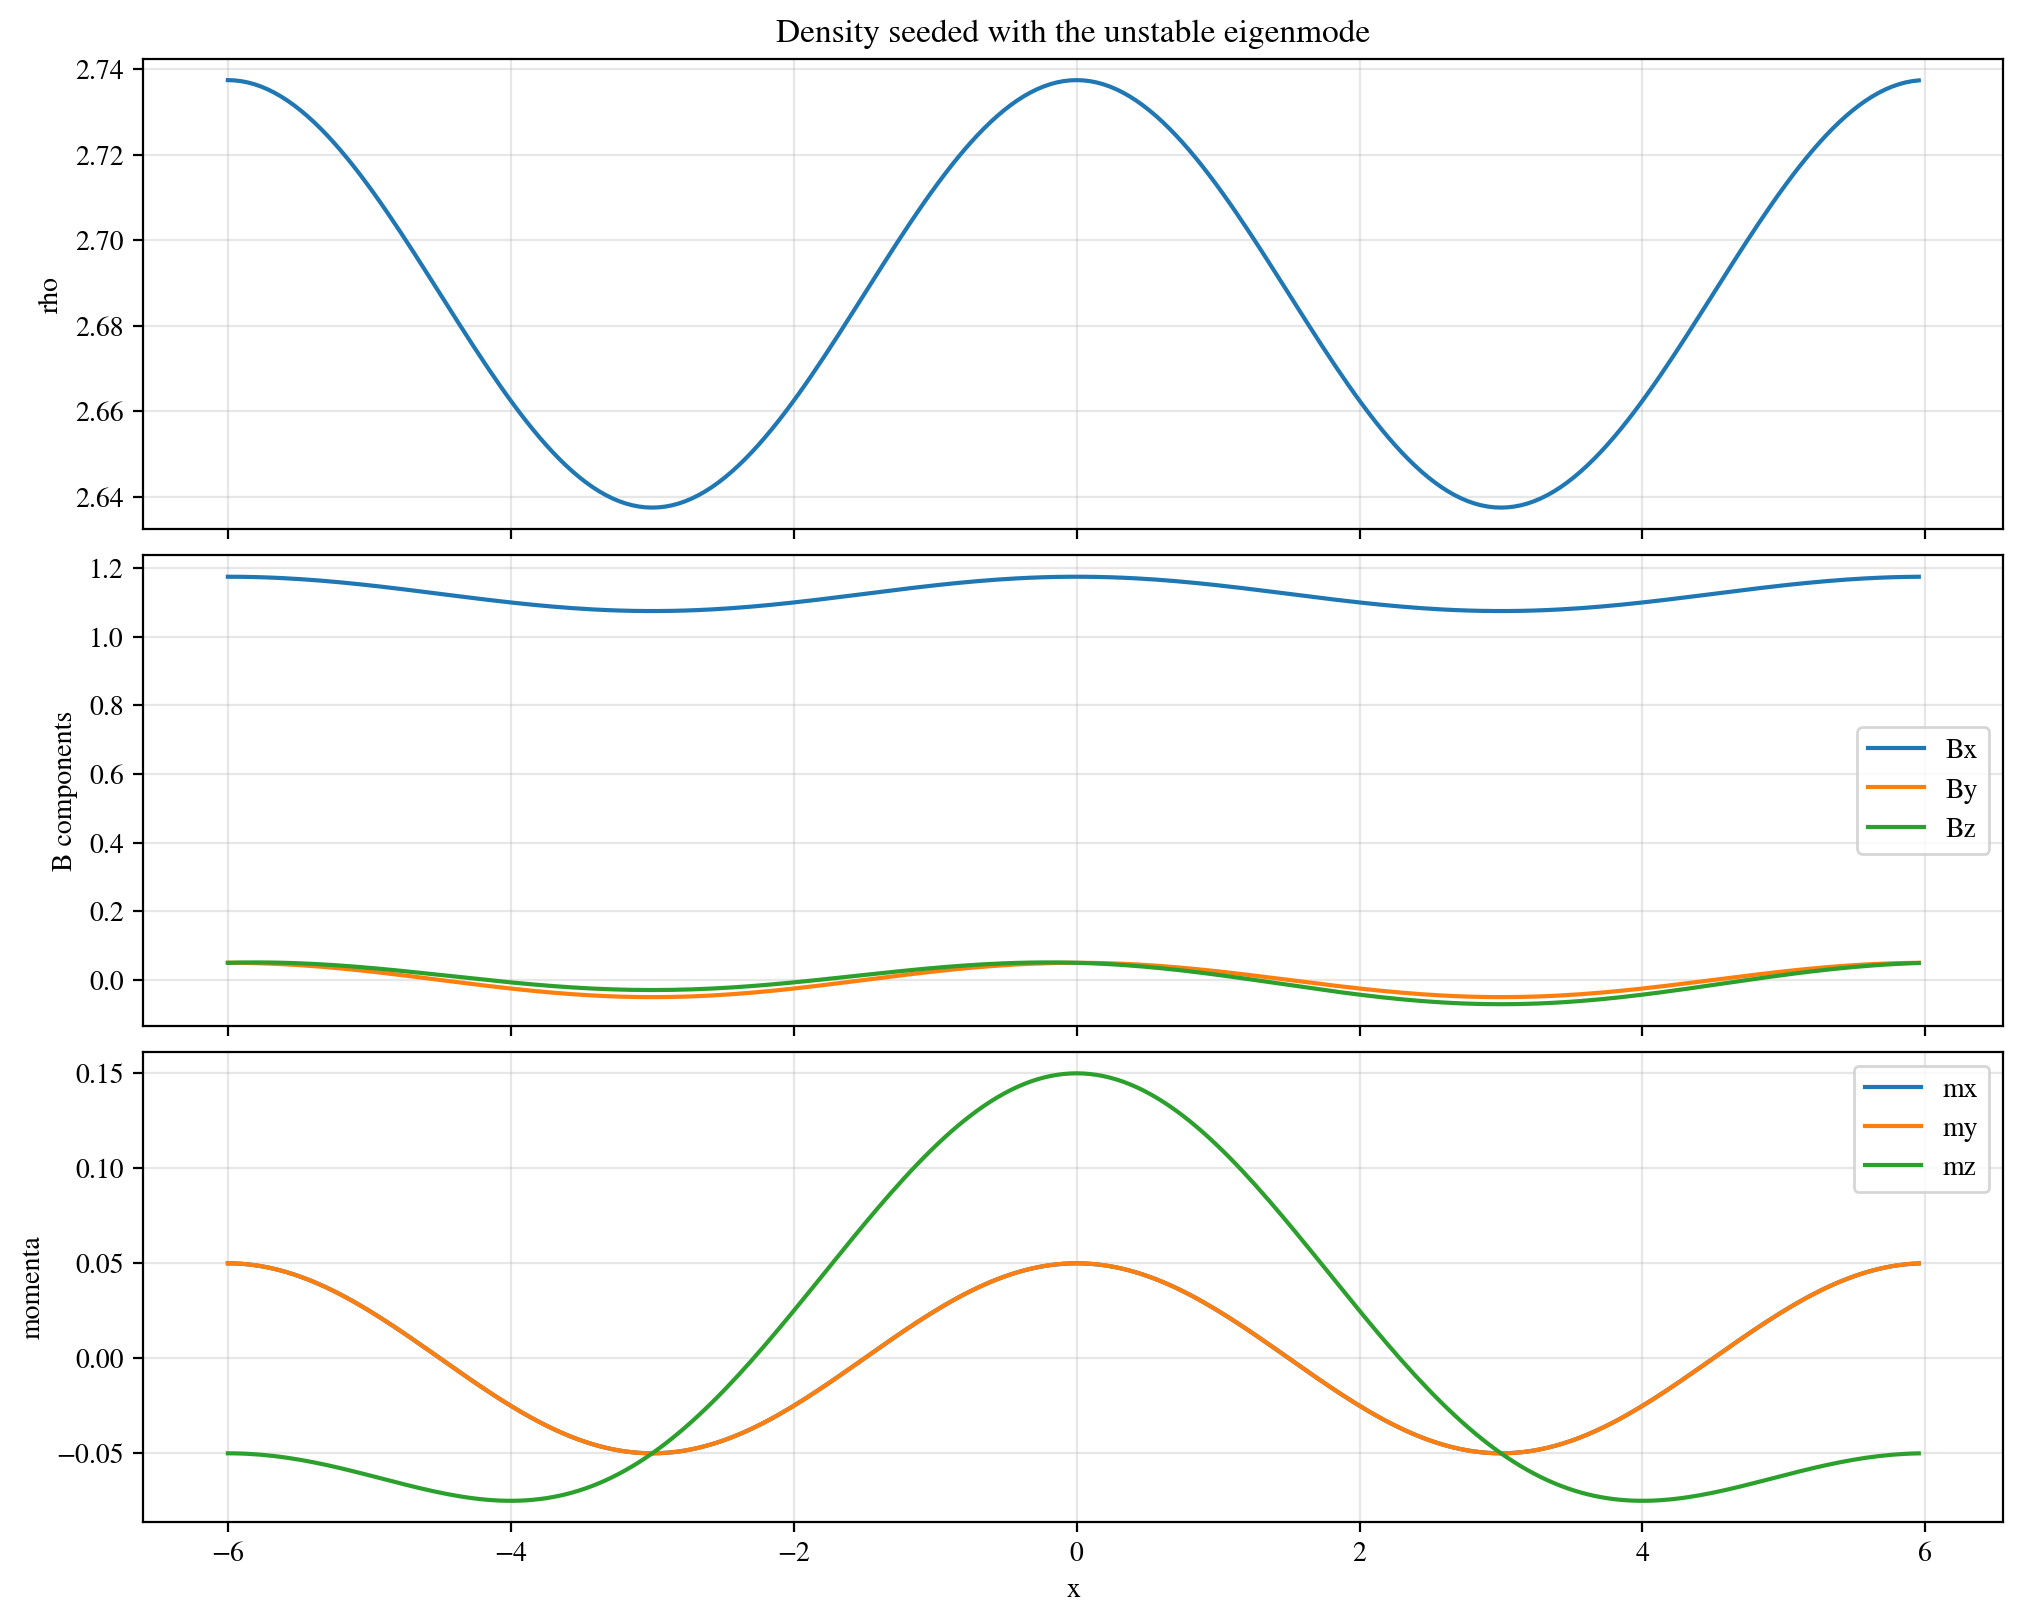

Predicted e-fold time: 0.943
Predicted oscillation period: 6283185307179.586
Minimum seeded density: 2.637500


In [34]:
preview_N = 256
preview_x = np.linspace(-Lx / 2.0, Lx / 2.0, preview_N, endpoint=False)
preview_lin = fh.build_linear_operator(
    selected_equilibrium['rho0'],
    selected_equilibrium['Bx0'],
    selected_equilibrium['k_phys'],
    scan_mu, scan_eta,
    gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=B_floor,
)
# ── Seed amplitudes: intermediate ────────────────────────────────────────
preview_amp = 0.1 #0.03
pert_amp    = 0.05 #0.008
pert_wave = 2.0 * np.pi * 2 / Lx
pert = {name: pert_amp * np.cos(pert_wave * preview_x)
        for name in ['rho', 'mx', 'my', 'mz', 'Bx', 'By', 'Bz']}

preview_mode = fh.make_real_eigenmode_profile(
    preview_lin['best_vec'], preview_x,
    selected_equilibrium['k_phys'], preview_amp,
)
preview_labels = ['rho', 'mx', 'my', 'mz', 'Bx', 'By', 'Bz']

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

axes[0].plot(preview_x, selected_equilibrium['rho0'] + preview_mode[0] + pert['rho'], label='rho')
axes[0].set_ylabel('rho')
axes[0].set_title('Density seeded with the unstable eigenmode')
axes[0].grid(alpha=0.3)

axes[1].plot(preview_x, selected_equilibrium['Bx0'] + preview_mode[4] + pert['Bx'], label='Bx')
axes[1].plot(preview_x, preview_mode[5] + pert['By'], label='By')
axes[1].plot(preview_x, preview_mode[6] + pert['Bz'], label='Bz')
axes[1].set_ylabel('B components')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

axes[2].plot(preview_x, preview_mode[1] + pert['mx'], label='mx')
axes[2].plot(preview_x, preview_mode[2] + pert['my'], label='my')
axes[2].plot(preview_x, preview_mode[3] + pert['mz'], label='mz')
axes[2].set_ylabel('momenta')
axes[2].set_xlabel('x')
axes[2].legend(loc='best')
axes[2].grid(alpha=0.3)
plt.show()

print(f"Predicted e-fold time: {1.0 / selected_equilibrium['growth_rate']:.3f}")
print(f"Predicted oscillation period: {2.0 * np.pi / max(abs(selected_equilibrium['frequency']), 1e-12):.3f}")
print(f"Minimum seeded density: {(selected_equilibrium['rho0'] + preview_mode[0] + pert['rho']).min():.6f}")

## Nonlinear Dedalus Run With Adaptive Tuning

The run function below seeds the nonlinear IVP with the unstable eigenmode. Several attempts are tried from low to higher damping. A run is accepted if it stays finite and shows meaningful transverse-energy growth.

In [35]:
# Build the initial-condition dict from the precomputed eigenmode (cell 6)
rho0 = selected_equilibrium['rho0']
Bx0  = selected_equilibrium['Bx0']
ic = {
    'rho': rho0 + preview_mode[0] + pert['rho'],
    'mx':  preview_mode[1] + pert['mx'],
    'my':  preview_mode[2] + pert['my'],
    'mz':  preview_mode[3] + pert['mz'],
    'Bx':  Bx0 + preview_mode[4] + pert['Bx'],
    'By':  preview_mode[5] + pert['By'],
    'Bz':  preview_mode[6] + pert['Bz'],
}

# ── Solver parameters ────────────────────────────────────────────────────
common_attempt = {
    't_final':      2.00,
    'cfl_safety':   0.05,
    'dt_initial':   1.0e-6,
    'dt_max':       5e-4,
    'sample_every': 10,
    'print_every':  50,
    'max_steps':    20000,
    'wall_time_limit': 120.0,
    'max_state_norm':  10.0,
    'max_high_k_power': 0.15,
    'filter_fraction':  0.50,
    'filter_cadence':   3,
}

# Dissipation scan: base is 4e-3, start at 1.5× for intermediate difficulty.
attempts = [
    {
        'label': f'{s * scan_mu:.0e} mu, {s * scan_eta:.0e} eta',
        'mu_visc': s * scan_mu,
        'eta':     s * scan_eta,
        **common_attempt,
    }
    for s in (1.5, 3.0, 7.0, 15.0, 30.0)
]

sigma = preview_lin['best_sigma']
predicted_growth_rate = float(np.real(sigma))

attempt_results = []
results = []
accepted_result = None
for attempt in attempts:
    label = attempt['label']
    kw = {k: v for k, v in attempt.items() if k != 'label'}
    print(f"\nRunning {label} with mu={kw['mu_visc']:.1e}, eta={kw['eta']:.1e}")

    result = fh.run_firehose_case(
        ic, Lx=Lx, gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=B_floor, **kw,
    )
    result['sigma'] = sigma
    result['linear'] = preview_lin
    results.append(result)

    transverse_energy = np.mean(result['By']**2 + result['Bz']**2, axis=1)
    growth_factor = np.nan
    if len(transverse_energy) > 1:
        growth_factor = float(transverse_energy[-1] / max(transverse_energy[0], 1e-30))

    attempt_results.append({
        'label': label,
        'status': result['status'],
        'predicted_growth_rate': predicted_growth_rate,
        't_end': float(result['t'][-1]) if len(result['t']) else 0.0,
        'energy_growth_factor': growth_factor,
        'rho_min_final': float(result['rho'][-1].min()) if len(result['t']) else np.nan,
        'By_max_final': float(np.abs(result['By'][-1]).max()) if len(result['t']) else np.nan,
    })

attempt_summary = pd.DataFrame(attempt_results)
display(attempt_summary)


Running 6e-03 mu, 6e-03 eta with mu=6.0e-03, eta=6.0e-03
2026-03-27 10:43:28,101 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.6e+02/s
[start] N=256 Lx=12.00 mu=6.00e-03 eta=6.00e-03 filter=on
  iter=     1 t=0.0000 dt=1.00e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     2 t=0.0000 dt=1.00e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     3 t=0.0000 dt=1.10e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     4 t=0.0000 dt=1.21e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     5 t=0.0000 dt=1.33e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     6 t=0.0000 dt=1.46e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     7 t=0.0000 dt=1.61e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000
  iter=     8 t=0.0000 dt=1.77e-06 Egrow=1.000 rho=[2.6375,2.7375] |By|max=5.000e-02 hk=0.000


,label,status,predicted_growth_rate,t_end,energy_growth_factor,rho_min_final,By_max_final
0,"6e-03 mu, 6e-03 eta",high-k ceiling,1.060858,0.291885,1.567809,2.614404,0.092794
1,"1e-02 mu, 1e-02 eta",high-k ceiling,1.060858,0.341885,1.793521,2.605143,0.112813
2,"3e-02 mu, 3e-02 eta",high-k ceiling,1.060858,0.601885,4.534007,2.548325,0.201817
3,"6e-02 mu, 6e-02 eta",finished,1.060858,2.000385,771.330425,1.918922,1.597905
4,"1e-01 mu, 1e-01 eta",finished,1.060858,2.000385,620.423379,2.157668,1.447628


### Dissipation Scan Results

Each attempt in the previous cell ran the same eigenmode IC through Dedalus with a different dissipation multiplier (1.5×, 3×, 7×, 15×, 30× the base scan viscosity/resistivity). The four diagnostic panels below help decide which level of damping produces a *usable* run:

- **Top-left — Density profile**: initial vs. final $\rho(x)$. A good run shows smooth structure, not sharp spikes or negative density.
- **Top-right — Transverse field $B_y(x)$**: the firehose instability should amplify this component. Look for clear mode structure without grid-scale noise.
- **Bottom-left — Transverse magnetic energy** $\langle B_y^2 + B_z^2 \rangle$ vs. time on a log scale. The dashed line is the **linear prediction** $E_\perp(0)\,e^{2\sigma_r t}$. A successful run should track this initially, then deviate as nonlinear saturation or numerical issues set in.
- **Bottom-right — Minimum density** vs. time. If this drops below the density floor, the run is effectively crashed.

The summary table printed after the runs reports the final transverse-energy growth factor, which quantifies how much the instability amplified before the run ended.

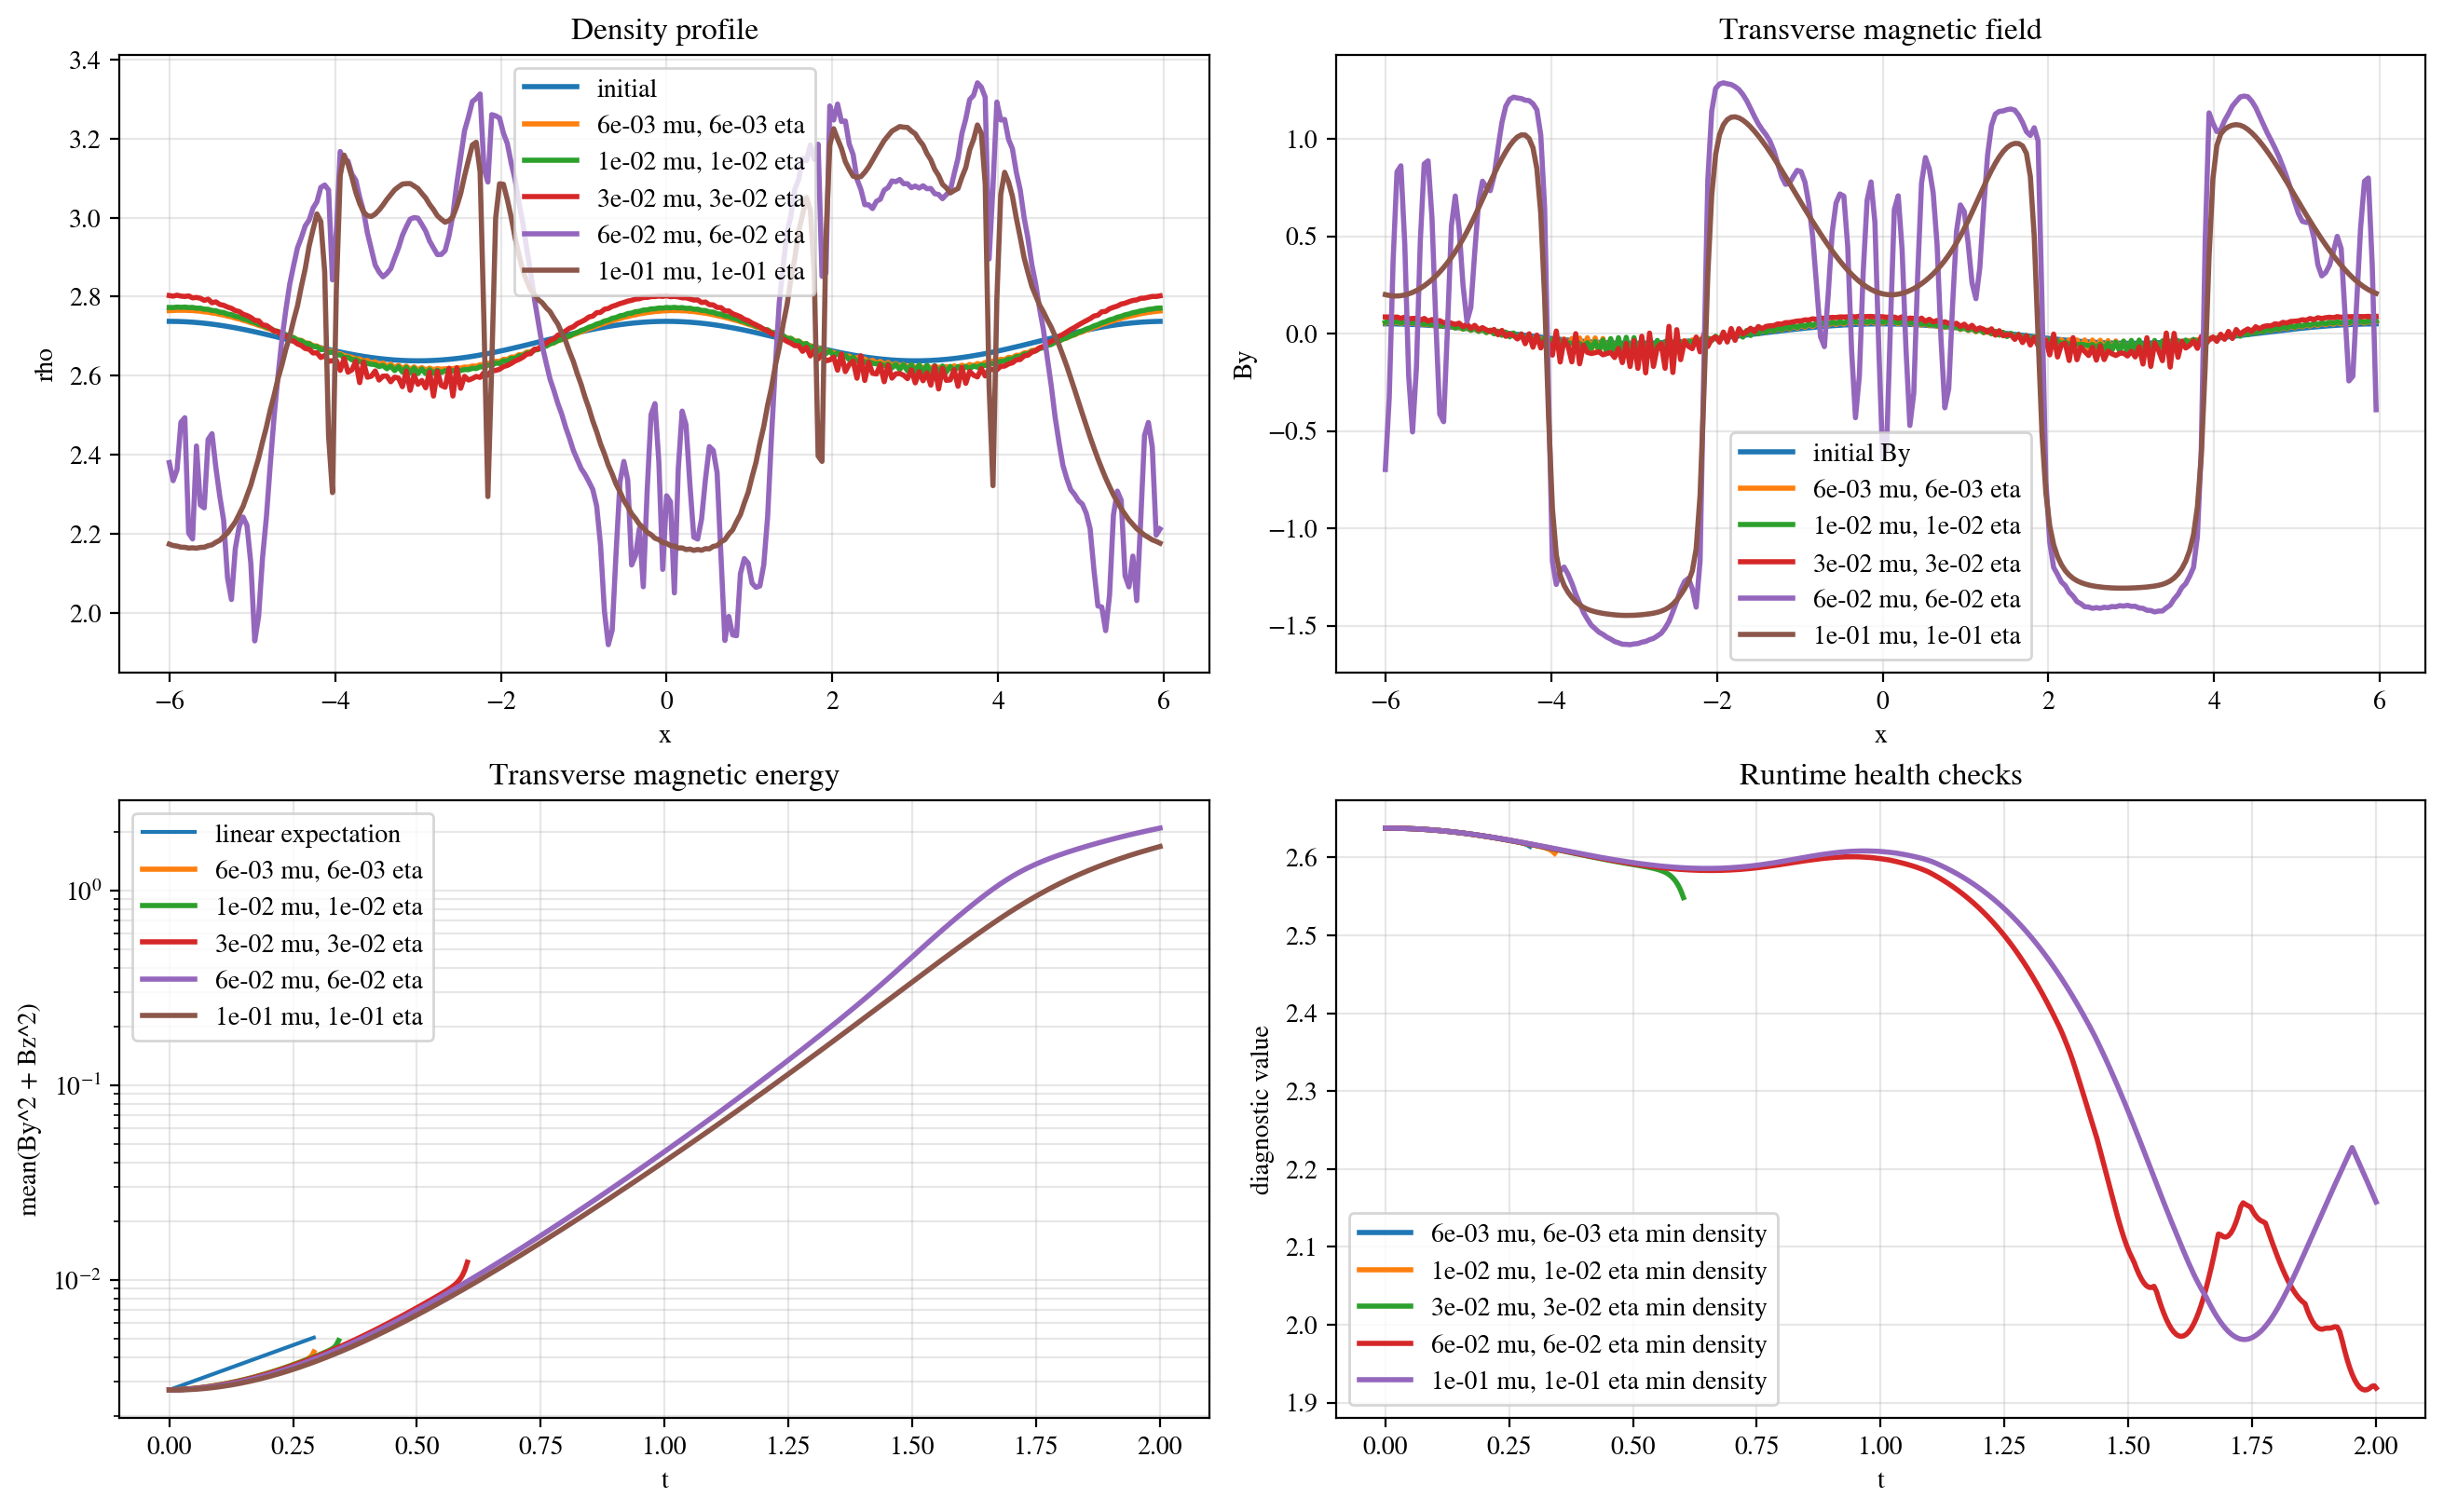

Run status: finished
Predicted growth rate: 1.0609e+00
Observed transverse-energy growth factor: 620.4234
Minimum density during run: 1.981287
Maximum |By| during run: 1.447628


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for i, result in enumerate(results):
    t = result['t']
    x = result['x']
    # Derive per-snapshot diagnostics from (n_t, n_x) arrays
    transverse_energy = np.mean(result['By']**2 + result['Bz']**2, axis=1)
    rho_min = result['rho'].min(axis=1)
    sigma_r = float(np.real(result['sigma']))
    if i == 0: # Plot initial condition once
        axes[0, 0].plot(x, result['rho'][0], lw=2, label='initial')
        axes[0, 1].plot(x, result['By'][0], lw=2, label='initial By')
        axes[1, 0].semilogy(t, transverse_energy[0] * np.exp(2.0 * sigma_r * (t - t[0])), lw=1.5, label='linear expectation')
    axes[0, 0].plot(x, result['rho'][-1], lw=2, label=attempt_summary['label'][i])
    axes[0, 1].plot(x, result['By'][-1], lw=2, label=f"{attempt_summary['label'][i]}")
    axes[1, 0].semilogy(t, transverse_energy, lw=2, label=f"{attempt_summary['label'][i]}")
    axes[1, 1].plot(t, rho_min, lw=2, label=f"{attempt_summary['label'][i]} min density")
    
axis_settings = [
    ((0, 0), 'Density profile', 'x', 'rho', {'alpha': 0.3}),
    ((0, 1), 'Transverse magnetic field', 'x', 'By', {'alpha': 0.3}),
    ((1, 0), 'Transverse magnetic energy', 't', 'mean(By^2 + Bz^2)', {'alpha': 0.3, 'which': 'both'}),
    ((1, 1), 'Runtime health checks', 't', 'diagnostic value', {'alpha': 0.3}),
]

for (row, col), title, xlabel, ylabel, grid_kwargs in axis_settings:
    ax = axes[row, col]
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(**grid_kwargs)
    ax.legend(loc='best')

plt.show()

growth_factor = float(transverse_energy[-1] / max(transverse_energy[0], 1e-30))
print(f"Run status: {result['status']}")
print(f"Predicted growth rate: {sigma_r:.4e}")
print(f"Observed transverse-energy growth factor: {growth_factor:.4f}")
print(f"Minimum density during run: {float(rho_min.min()):.6f}")
print(f"Maximum |By| during run: {float(np.abs(result['By']).max()):.6f}")

### Selecting a Dissipation Level and Inspecting Space-Time Fields

Based on the summary table and diagnostic plots above, we manually pick one of the dissipation attempts (`choose_case`) and extract its full $(t,\,x)$ field arrays. The space-time colour-maps below show all seven conserved variables — $\rho$, $m_x$, $m_y$, $m_z$, $B_x$, $B_y$, $B_z$ — over the entire simulation domain and time span.

What to look for:
- **Transverse fields** ($B_y$, $B_z$, $m_y$, $m_z$) should show growing wave patterns consistent with the firehose mode.
- **Longitudinal fields** ($\rho$, $m_x$, $B_x$) may develop secondary structure through nonlinear coupling.
- Grid-scale noise or checkerboard patterns indicate insufficient resolution or dissipation.

chosen mu_visc: 0.12
chosen eta: 0.12
Plotting field rho with shape (407, 256)
Plotting field mx with shape (407, 256)
Plotting field my with shape (407, 256)
Plotting field mz with shape (407, 256)
Plotting field Bx with shape (407, 256)
Plotting field By with shape (407, 256)
Plotting field Bz with shape (407, 256)


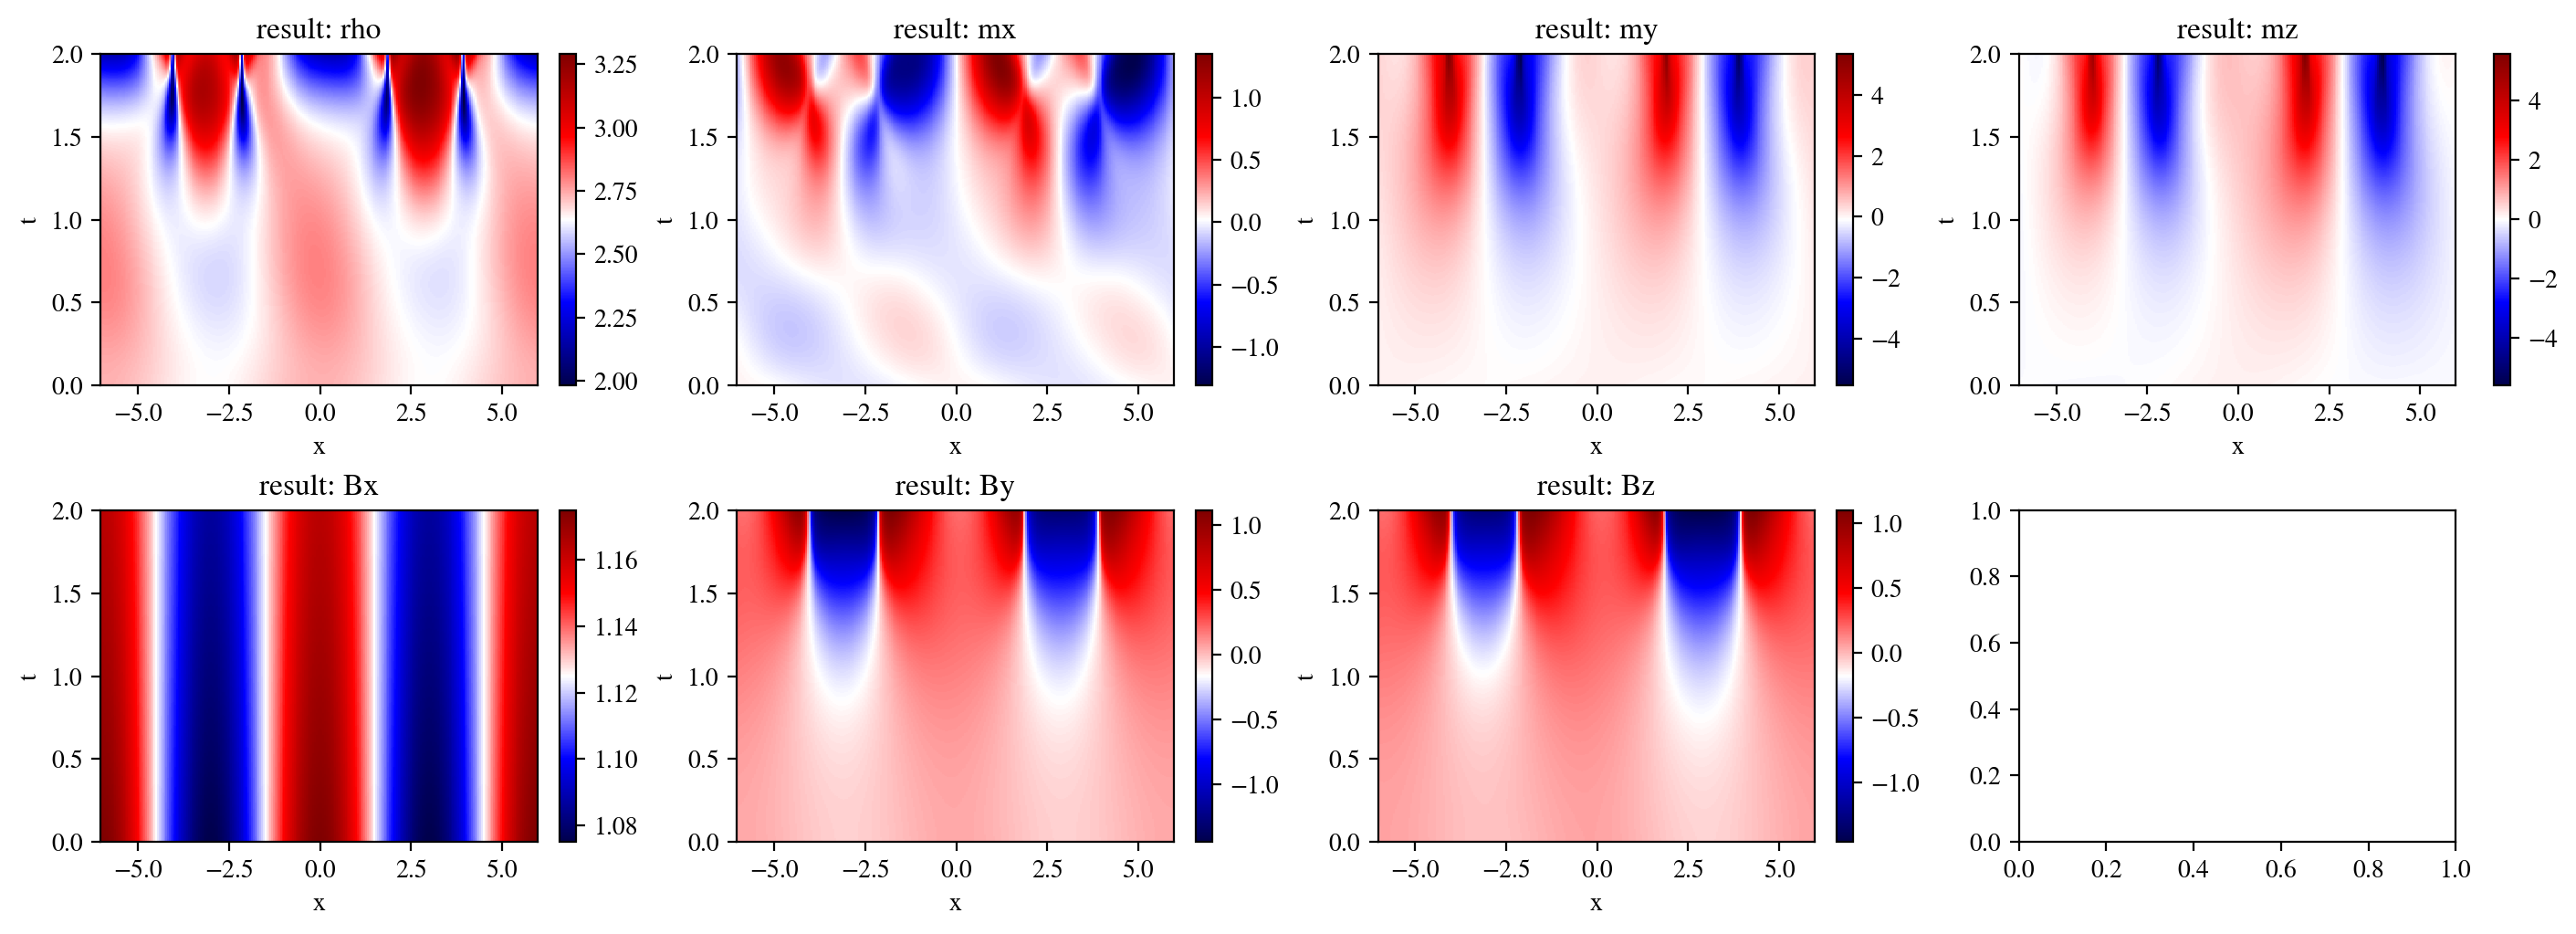

In [38]:
choose_case = 4
chose_mu_visc = attempts[choose_case]['mu_visc']
chose_eta = attempts[choose_case]['eta']
print(f"chosen mu_visc: {chose_mu_visc}")
print(f"chosen eta: {chose_eta}")
result = results[choose_case]
t = result['t']
x = result['x']
fields = {name: result[name] for name in fh.FIELD_NAMES}

fig, axes = plt.subplots(2, 4, figsize=(14, 5), constrained_layout=True)

for ax, (title, field) in zip(axes.flat, fields.items()):
    print(f"Plotting field {title} with shape {field.shape}")
    mesh = ax.pcolormesh(x, t, field, shading='auto', cmap='seismic')
    ax.set_title(f'result: {title}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    fig.colorbar(mesh, ax=ax)

plt.show()


## Multi-Campaign Parameter Study

### Placing Campaign Centres in $(\rho_0, B_{x0})$ Space

A single equilibrium tells us about one point in parameter space. To build a training dataset for a **machine-learning surrogate** of the CGL closure, we need nonlinear simulation data that covers a range of background densities and magnetic-field strengths.

The approach:
1. **Sample `n_campaigns` centre points** uniformly at random inside the scan window $[B_{\min}, B_{\max}] \times [\rho_{\min}, \rho_{\max}]$.
2. Each centre defines one Dedalus run seeded with the same eigenmode structure (phase, wavelength, amplitude) but shifted to a different equilibrium $(\rho_0, B_{x0})$.
3. Runs above the CGL firehose threshold (dashed curve) are expected to show instability growth; runs below it provide stable-regime training data where the closure still needs to be accurate.

The scatter plot below shows the campaign centres overlaid on the scan window, with the analytic firehose threshold for reference.

,Bx0,rho0
campaign,,
1,1.0546,1.3978
2,1.2106,2.3909
3,1.6351,1.8576
4,0.8178,1.0052
5,1.2360,1.7903


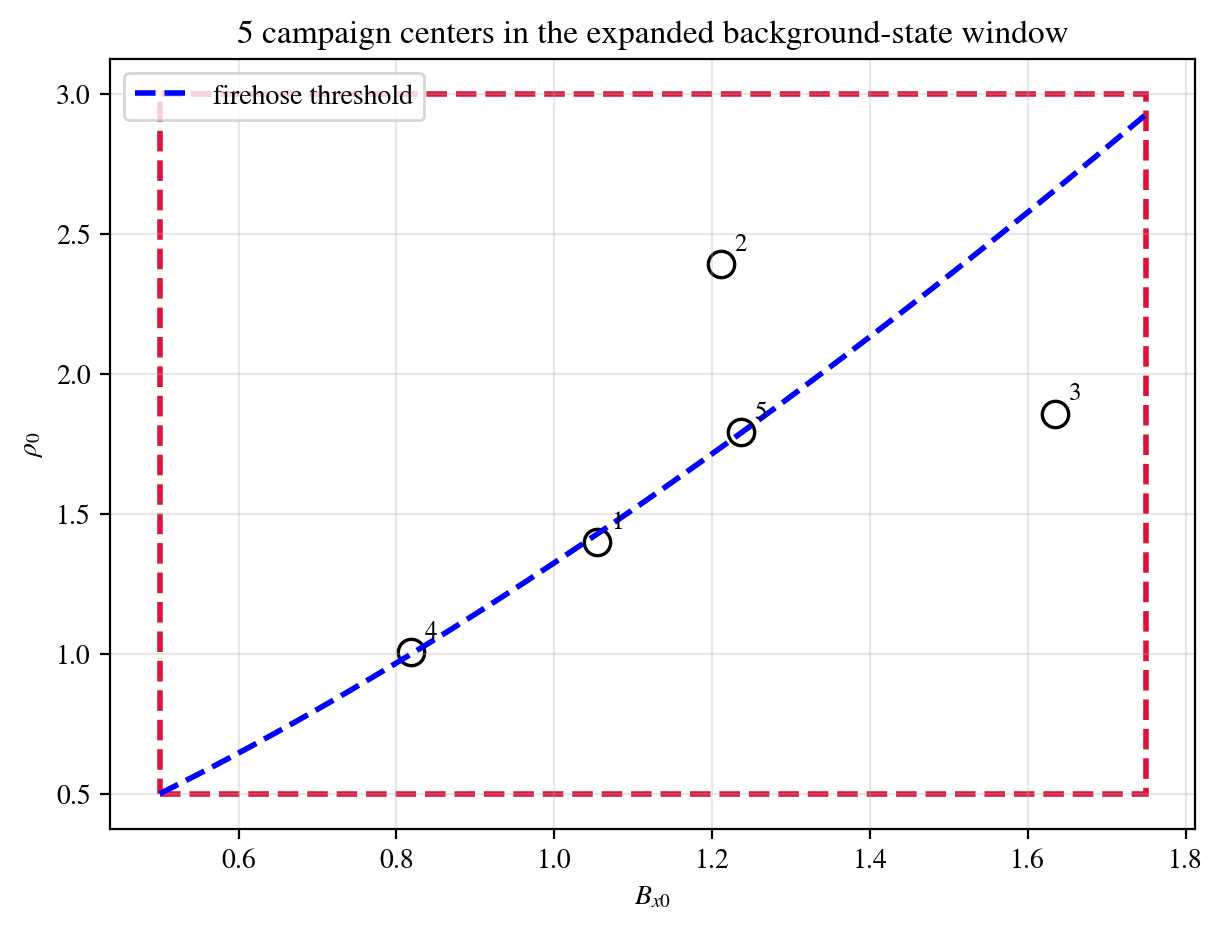

In [67]:
from scipy.stats import qmc
sampler = qmc.LatinHypercube(d=2)

n_campaigns = 5 #20 #40

campaign_rng = np.random.default_rng(33) #2026
campaign_centers = np.column_stack([
    campaign_rng.uniform(scan_B_min, scan_B_max, size=n_campaigns),
    campaign_rng.uniform(scan_rho_min, scan_rho_max, size=n_campaigns),
])

sample = sampler.random(n=n_campaigns)

campaign_centers_df = pd.DataFrame(campaign_centers, columns=['Bx0', 'rho0'])
campaign_centers_df.index = np.arange(1, len(campaign_centers_df) + 1)
campaign_centers_df.index.name = 'campaign'
display(campaign_centers_df.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(campaign_centers[:, 0], campaign_centers[:, 1], s=90, c='white', edgecolors='black', linewidths=1.2)
for idx, (bx0, rho0) in enumerate(campaign_centers, start=1):
    ax.annotate(str(idx), xy=(bx0, rho0), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.add_patch(plt.Rectangle((scan_B_min, scan_rho_min), scan_B_max - scan_B_min, scan_rho_max - scan_rho_min, fill=False, edgecolor='crimson', linestyle='--', linewidth=2))

# Firehose instability threshold curve
bx_threshold = np.linspace(scan_B_min, scan_B_max, 400)
rho_threshold = np.full_like(bx_threshold, np.nan, dtype=float)
for i, bx in enumerate(bx_threshold):
    coeffs = [1.0, 0.0, -bx**3, -bx**4]
    roots = np.roots(coeffs)
    real_positive_roots = roots[np.isclose(roots.imag, 0.0, atol=1e-10) & (roots.real > 0.0)].real
    if len(real_positive_roots):
        rho_threshold[i] = real_positive_roots.max()
ax.plot(bx_threshold, rho_threshold, color='blue', lw=2.0, ls='--', label='firehose threshold')

ax.set_xlabel(r'$B_{x0}$')
ax.set_ylabel(r'$\rho_0$')
ax.set_title(f'{n_campaigns} campaign centers in the expanded background-state window')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

### Equilibrium Diagnostics Across the Parameter Grid

Before running the campaigns, we evaluate the **exact CGL closure** on a uniform $(\rho_0, B_{x0})$ grid to understand the thermodynamic landscape the ML model will need to learn:

- **Parallel plasma beta** $\beta_\parallel = 2 p_\parallel / B^2$: measures the ratio of parallel thermal pressure to magnetic pressure. High $\beta_\parallel$ regions are where pressure forces dominate over magnetic tension — the regime most prone to firehose instability.
- **Pressure anisotropy ratio** $p_\perp / p_\parallel$: the CGL closure produces anisotropy that varies with $\rho$ and $B$. When this ratio is $< 1$ (i.e. $p_\parallel > p_\perp$), the firehose drive is positive.

The **white contour** in each panel marks the firehose threshold $\Lambda_{\mathrm{fh}} = p_\parallel - p_\perp - B^2 = 0$. Campaign centres (white dots) that fall above this contour are in the unstable regime.

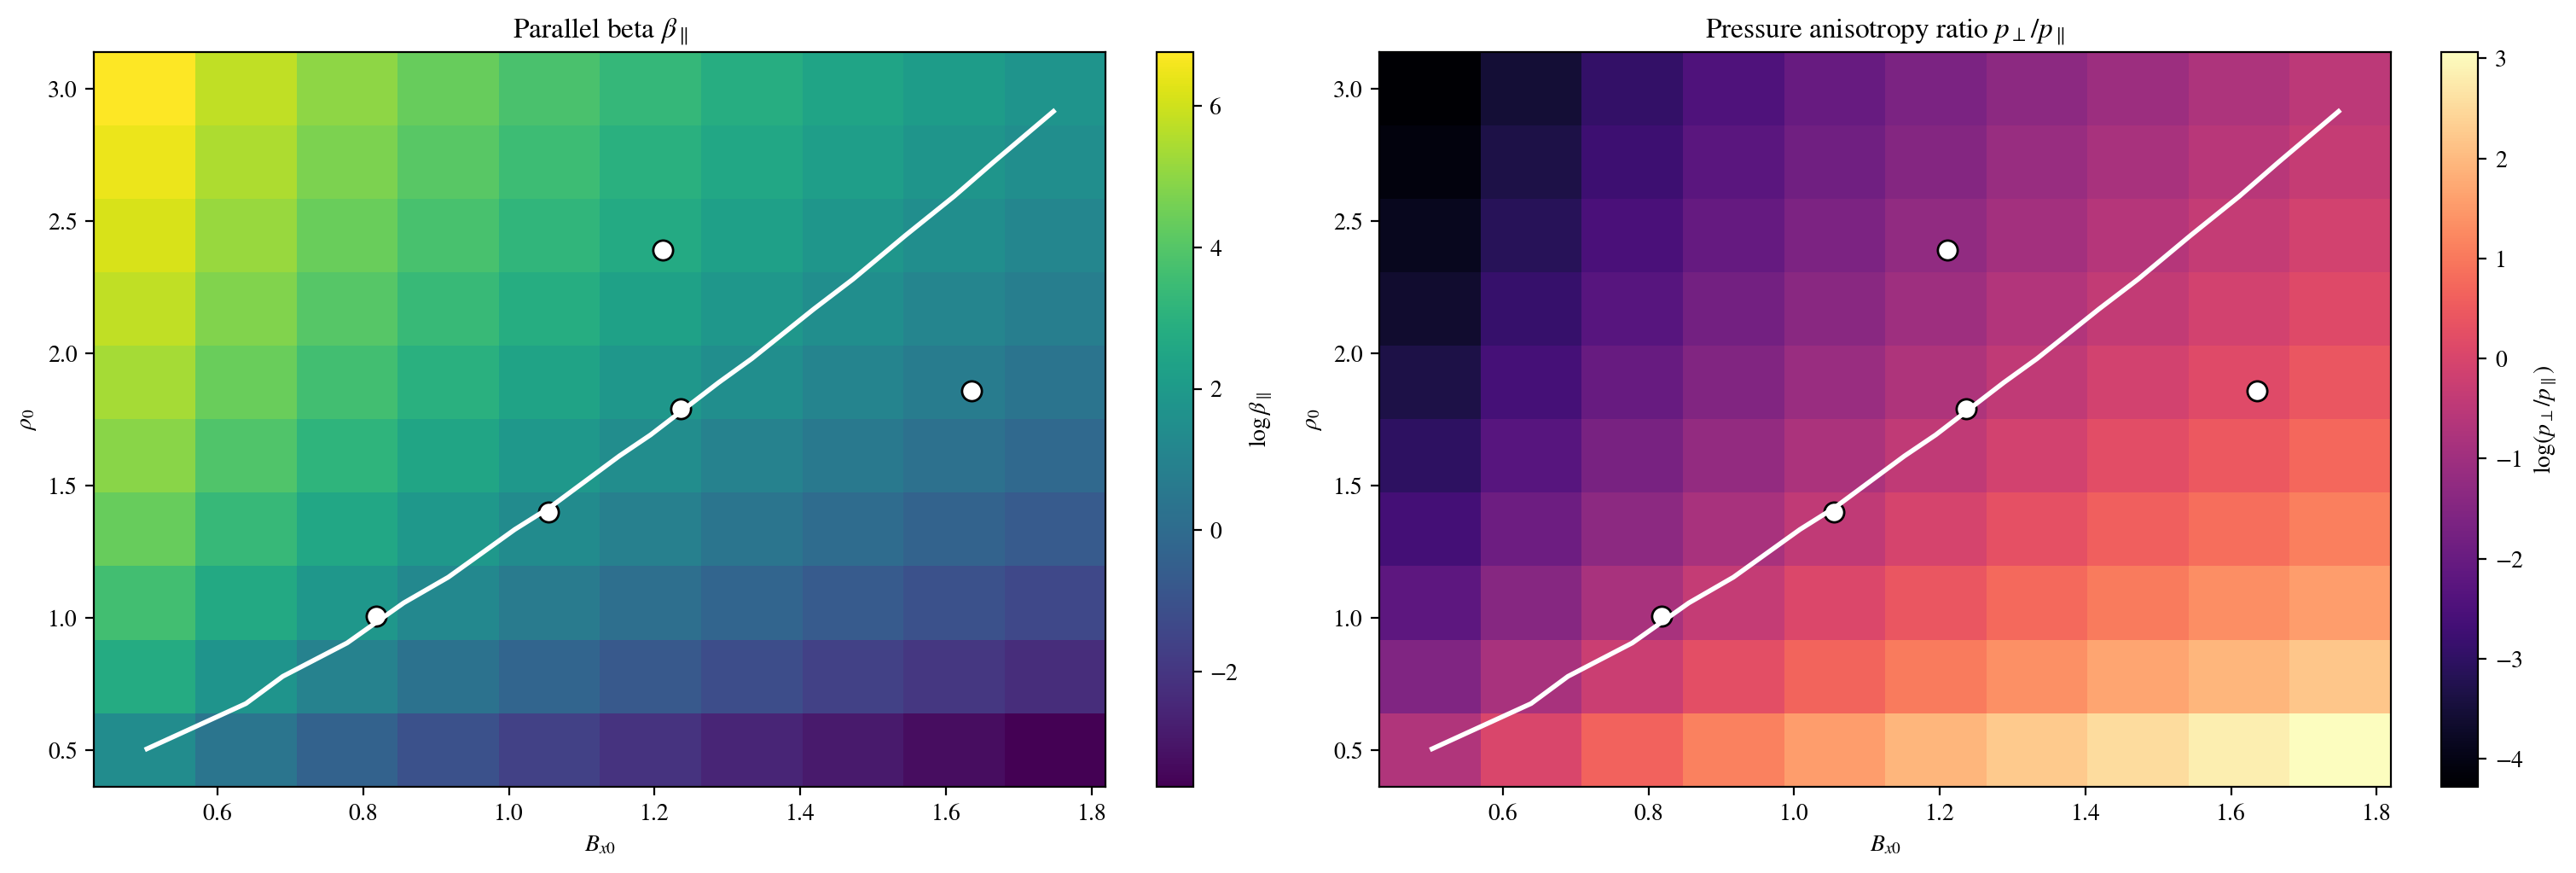

In [68]:
n_B = 10
n_rho = 10
Bx0_values = np.linspace(scan_B_min, scan_B_max, n_B)
rho0_values = np.linspace(scan_rho_min, scan_rho_max, n_rho)
BX0, RHO0 = np.meshgrid(Bx0_values, rho0_values, indexing='xy')

# Evaluate the uniform-state CGL closure on the full parameter grid.
p_par0, p_perp0, B2_0, Bmag0 = fh.cgl_pressures_np(
    RHO0,
    BX0,
    0.0,
    0.0,
    gamma_par=gamma_par,
    gamma_perp=gamma_perp,
    B_floor=B_floor,
)

# The firehose margin is the direct equilibrium indicator used throughout the notebook.
firehose_margin0 = p_par0 - p_perp0 - B2_0
anisotropy_ratio0 = p_perp0 / np.maximum(p_par0, 1e-30)
beta_parallel0 = 2.0 * p_par0 / np.maximum(B2_0, 1e-30)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)



# Panel 2: large parallel beta usually tracks weaker magnetic control.
mesh = axes[0].pcolormesh(BX0, RHO0, np.log(beta_parallel0), shading='auto', cmap='viridis')
axes[0].scatter(campaign_centers[:, 0], campaign_centers[:, 1], s=70, c='white', edgecolors='black')
axes[0].contour(BX0, RHO0, firehose_margin0, levels=[0.0], colors='white', linewidths=2)
axes[0].set_title(r'Parallel beta $\beta_\parallel$')
axes[0].set_xlabel(r'$B_{x0}$')
axes[0].set_ylabel(r'$\rho_0$')
fig.colorbar(mesh, ax=axes[0], label=r'$\log \beta_\parallel$')

# Panel 3: anisotropy ratio clarifies whether the margin changes are pressure-driven or field-driven.
mesh = axes[1].pcolormesh(BX0, RHO0, np.log(anisotropy_ratio0), shading='auto', cmap='magma')
axes[1].scatter(campaign_centers[:, 0], campaign_centers[:, 1], s=70, c='white', edgecolors='black')
axes[1].contour(BX0, RHO0, firehose_margin0, levels=[0.0], colors='white', linewidths=2)

axes[1].set_title(r'Pressure anisotropy ratio $p_\perp / p_\parallel$')
axes[1].set_xlabel(r'$B_{x0}$')
axes[1].set_ylabel(r'$\rho_0$')
fig.colorbar(mesh, ax=axes[1], label=r'$\log (p_\perp / p_\parallel)$')

plt.show()

### Running the Campaign Simulations

Each campaign centre $(\rho_{0,i}, B_{x0,i})$ is turned into a full Dedalus IVP using the same procedure as the single-case study above:

1. The eigenmode perturbation (computed once from the selected equilibrium) is superimposed on the campaign-specific background state.
2. The solver parameters (CFL safety, dissipation, spectral filter, stopping guards) are taken from the accepted dissipation level.
3. Snapshots of all seven conserved fields are stored at regular intervals.

The result is a collection of $(t, x, \text{field})$ arrays — one per campaign — that together span a range of stable and unstable thermodynamic conditions. These become the raw training data for the ML surrogate.

The summary table reports each run's final status, time reached, transverse-energy growth factor, minimum density, and maximum $|B_y|$.

In [69]:
# Build the initial-condition dict from the precomputed eigenmode (cell 6)

# Each attempt varies only solver / dissipation parameters;
# the IC is the same precomputed eigenmode everywhere.
common_attempt = {
    't_final': 2.00,
    'cfl_safety': 0.1,
    'dt_initial': 3.0e-6,
    'dt_max' : 1e-3,
    'sample_every': 10,
    'print_every': 50,
    'max_steps': 10000,
    'wall_time_limit': 75.0,
    'max_state_norm': 8.0,
    'mu_visc' : chose_mu_visc,
    'eta': chose_eta,
}

attempts = [
    {
        'label': f'run{i:02d}',
        **common_attempt,
    }
    for i, (rho0, Bx0) in enumerate(zip(campaign_centers[:, 0], campaign_centers[:, 1]), start=1)
]

# Linear analysis from the preview cell
sigma = preview_lin['best_sigma']
predicted_growth_rate = float(np.real(sigma))
attempt_results = []
results = {}
for i, attempt in enumerate(attempts):
    Bx0  = campaign_centers[i, 0]
    rho0  = campaign_centers[i, 1]
    ic = {
        'rho': rho0 + preview_mode[0]+pert['rho'],
        'mx':  preview_mode[1]+pert['mx'],
        'my':  preview_mode[2]+pert['my'],
        'mz':  preview_mode[3]+pert['mz'],
        'Bx':  Bx0 + preview_mode[4]+pert['Bx'],
        'By':  preview_mode[5]+pert['By'],
        'Bz':  preview_mode[6]+pert['Bz'],
    }

    label = attempt['label']
    kw = {k: v for k, v in attempt.items() if k != 'label'}
    print(f"\nRunning {label} with rho0={rho0:.1e}, Bx0={Bx0:.1e}")

    result = fh.run_firehose_case(
        ic,
        Lx=Lx,
        gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=B_floor,
        **kw,
    )
    results[label] = result
    # Diagnostics from (n_t, n_x) arrays
    transverse_energy = np.mean(result['By']**2 + result['Bz']**2, axis=1)
    growth_factor = np.nan
    if len(transverse_energy) > 1:
        growth_factor = float(transverse_energy[-1] / max(transverse_energy[0], 1e-30))

    attempt_results.append({
        'label': label,
        'rho0': rho0,
        'Bx0': Bx0,
        'status': result['status'],
        't_end': float(result['t'][-1]) if len(result['t']) else 0.0,
        'energy_growth_factor': growth_factor,
        'rho_min_final': float(result['rho'][-1].min()) if len(result['t']) else np.nan,
        'By_max_final': float(np.abs(result['By'][-1]).max()) if len(result['t']) else np.nan,
    })
"""    if result['status'] == 'finished' and np.isfinite(growth_factor) and growth_factor > 1.1:
        accepted_result = result
        break"""

attempt_summary = pd.DataFrame(attempt_results)
display(attempt_summary)



Running run01 with rho0=1.4e+00, Bx0=1.1e+00
2026-03-27 11:54:33,356 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 8.8e+01/s
[start] N=256 Lx=12.00 mu=1.20e-01 eta=1.20e-01 filter=on
  iter=     1 t=0.0000 dt=3.00e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     2 t=0.0000 dt=3.00e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     3 t=0.0000 dt=3.30e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     4 t=0.0000 dt=3.63e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     5 t=0.0000 dt=3.99e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     6 t=0.0000 dt=4.39e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     7 t=0.0000 dt=4.83e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     8 t=0.0000 dt=5.31e-06 Egrow=1.000 rho=[1.3478,1.4478] |By|max=5.000e-02 hk=0.000
  iter=     

,label,rho0,Bx0,status,t_end,energy_growth_factor,rho_min_final,By_max_final
0,run01,1.397808,1.054553,finished,2.000021,3.236759,1.353632,0.070301
1,run02,2.390934,1.210614,finished,2.000021,88.542425,2.147599,0.615581
2,run03,1.857647,1.635130,finished,2.000021,1.381184,1.806314,0.041600
3,run04,1.005211,0.817812,finished,2.000021,4.131044,0.963256,0.085193
4,run05,1.790263,1.235977,finished,2.000021,3.389640,1.747803,0.077883


### Space-Time Field Evolution for Each Campaign

For every completed campaign run, the cell below produces a $2 \times 4$ grid of space-time colour-maps (one per conserved field). These serve as a quick visual sanity check:

- Runs that reached `t_final` should show smooth, bounded field evolution.
- Runs that stopped early (density floor, energy blow-up, or spectral quality guard) will have shorter time axes.
- Comparing across campaigns reveals how the firehose dynamics change with the background $(\rho_0, B_{x0})$: higher-density campaigns typically show faster transverse-field growth.

Plotting field rho with shape (207, 256)
Plotting field mx with shape (207, 256)
Plotting field my with shape (207, 256)
Plotting field mz with shape (207, 256)
Plotting field Bx with shape (207, 256)
Plotting field By with shape (207, 256)
Plotting field Bz with shape (207, 256)


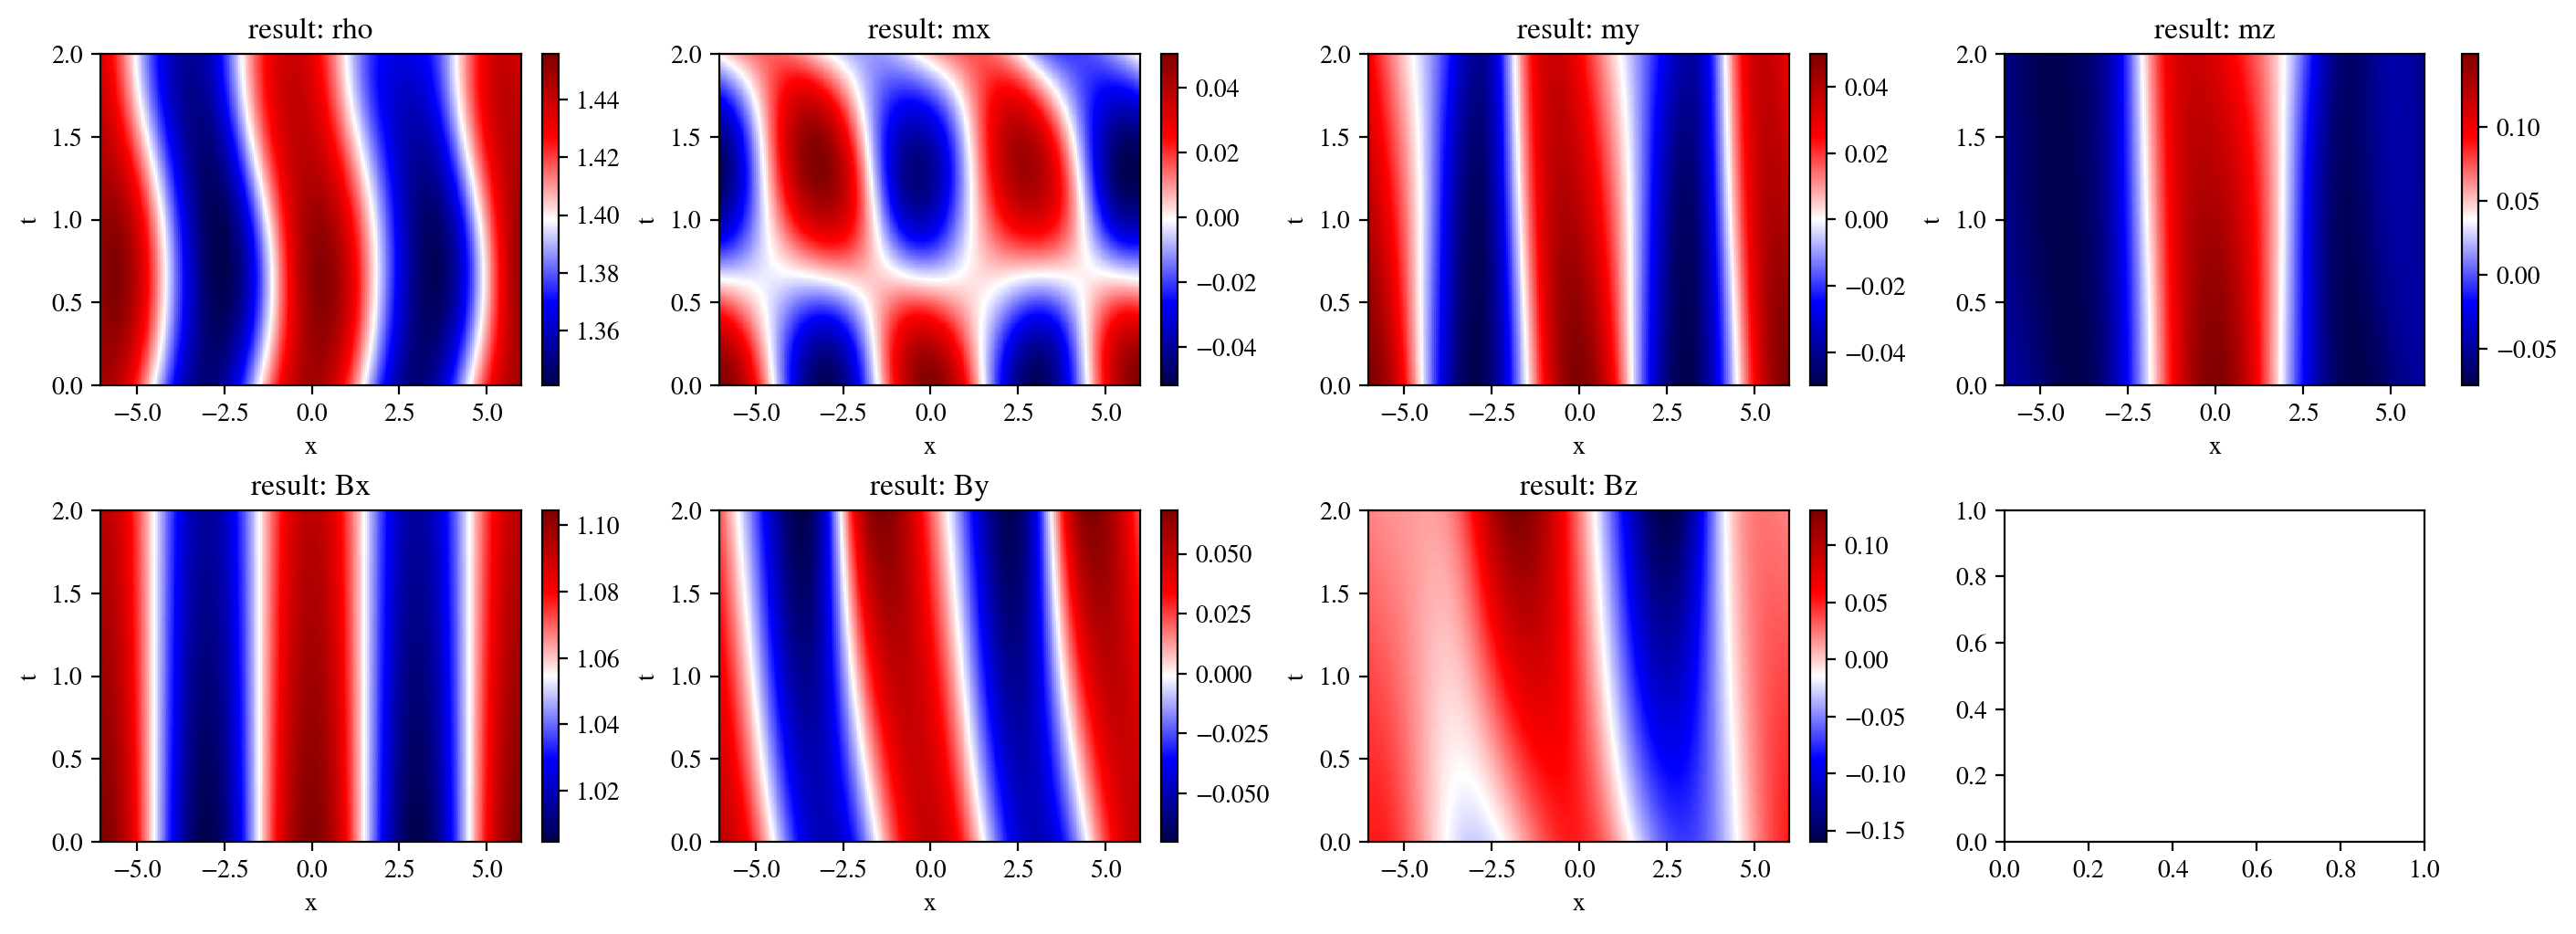

Plotting field rho with shape (207, 256)
Plotting field mx with shape (207, 256)
Plotting field my with shape (207, 256)
Plotting field mz with shape (207, 256)
Plotting field Bx with shape (207, 256)
Plotting field By with shape (207, 256)
Plotting field Bz with shape (207, 256)


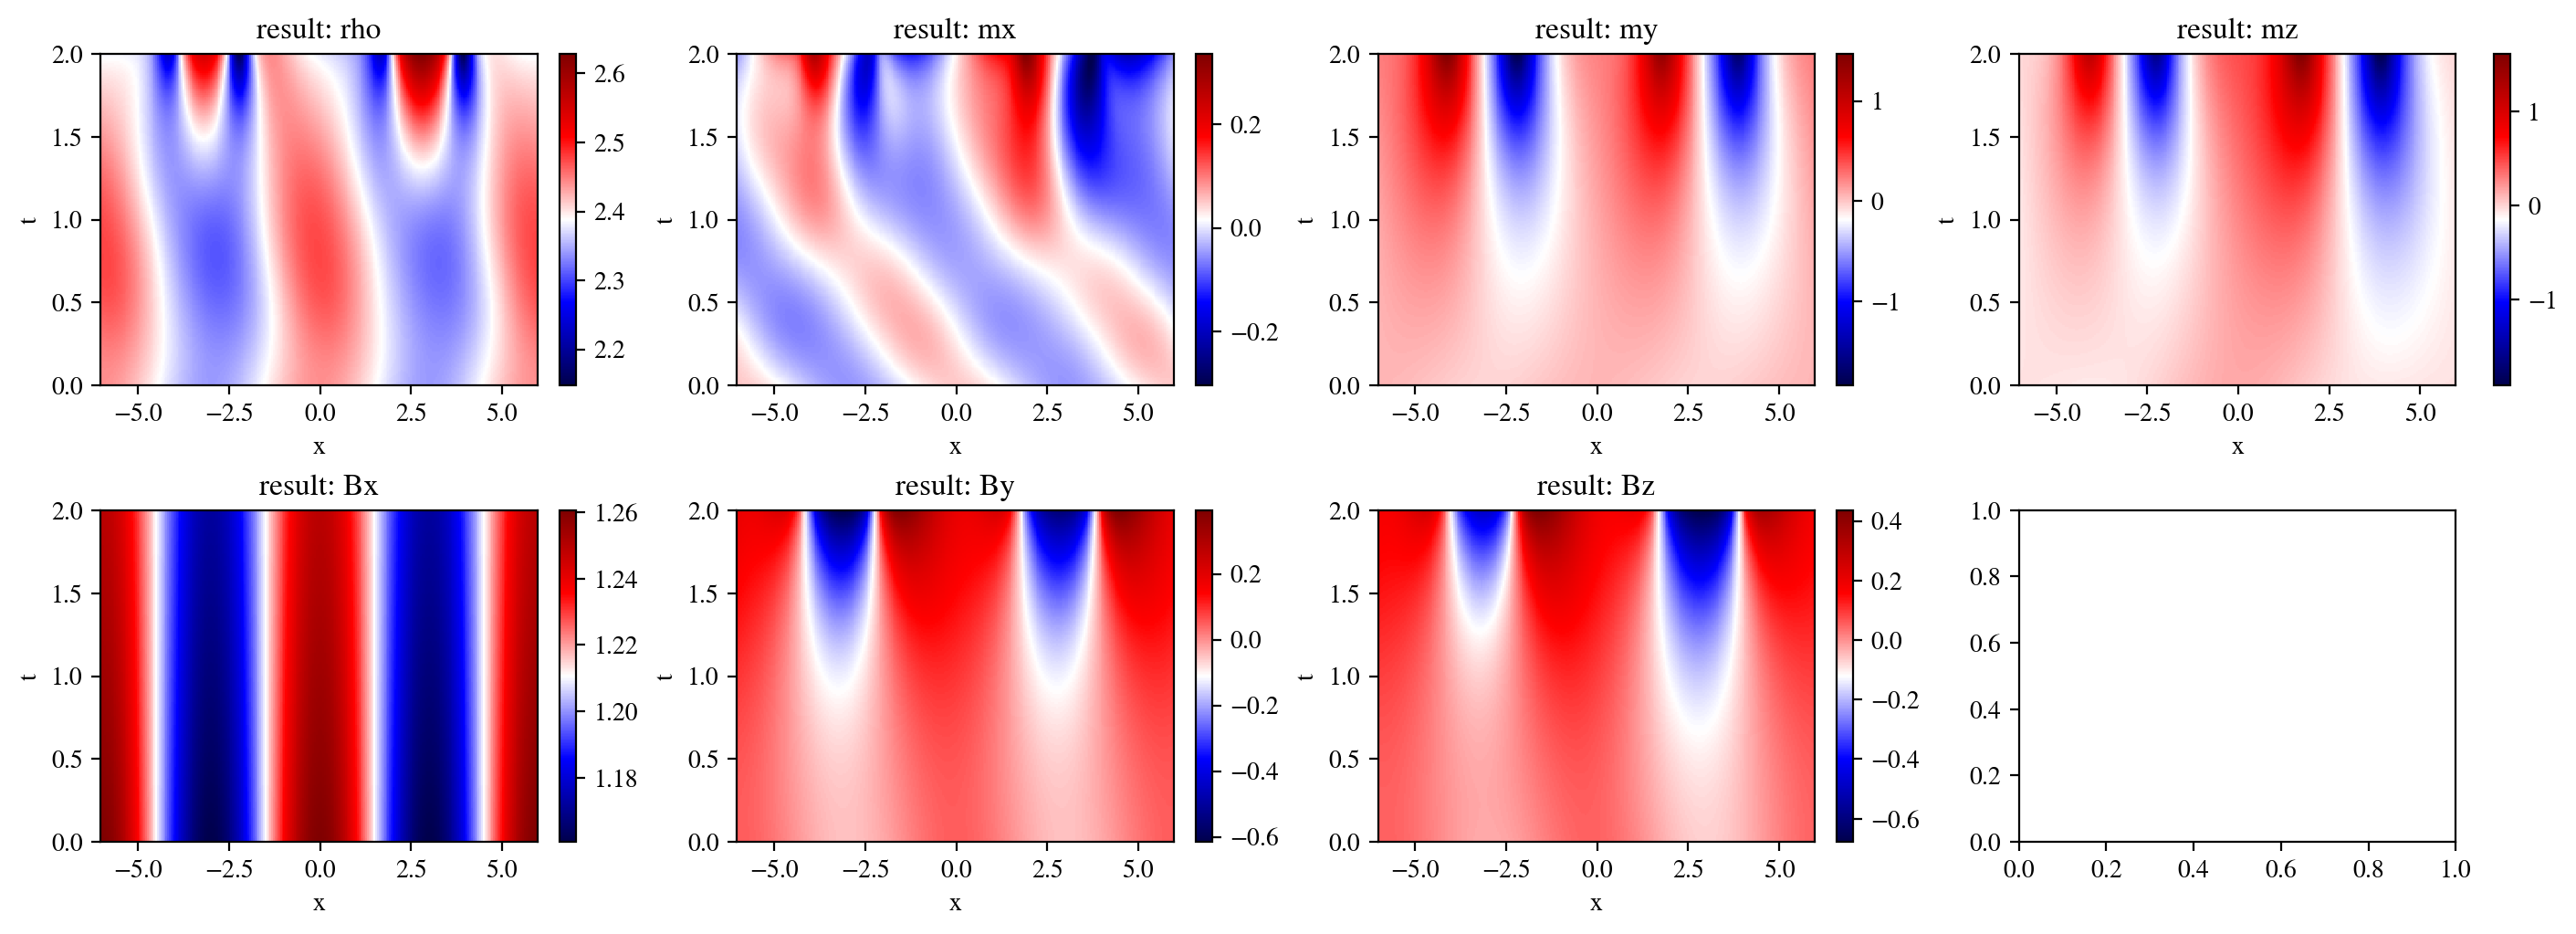

Plotting field rho with shape (207, 256)
Plotting field mx with shape (207, 256)
Plotting field my with shape (207, 256)
Plotting field mz with shape (207, 256)
Plotting field Bx with shape (207, 256)
Plotting field By with shape (207, 256)
Plotting field Bz with shape (207, 256)


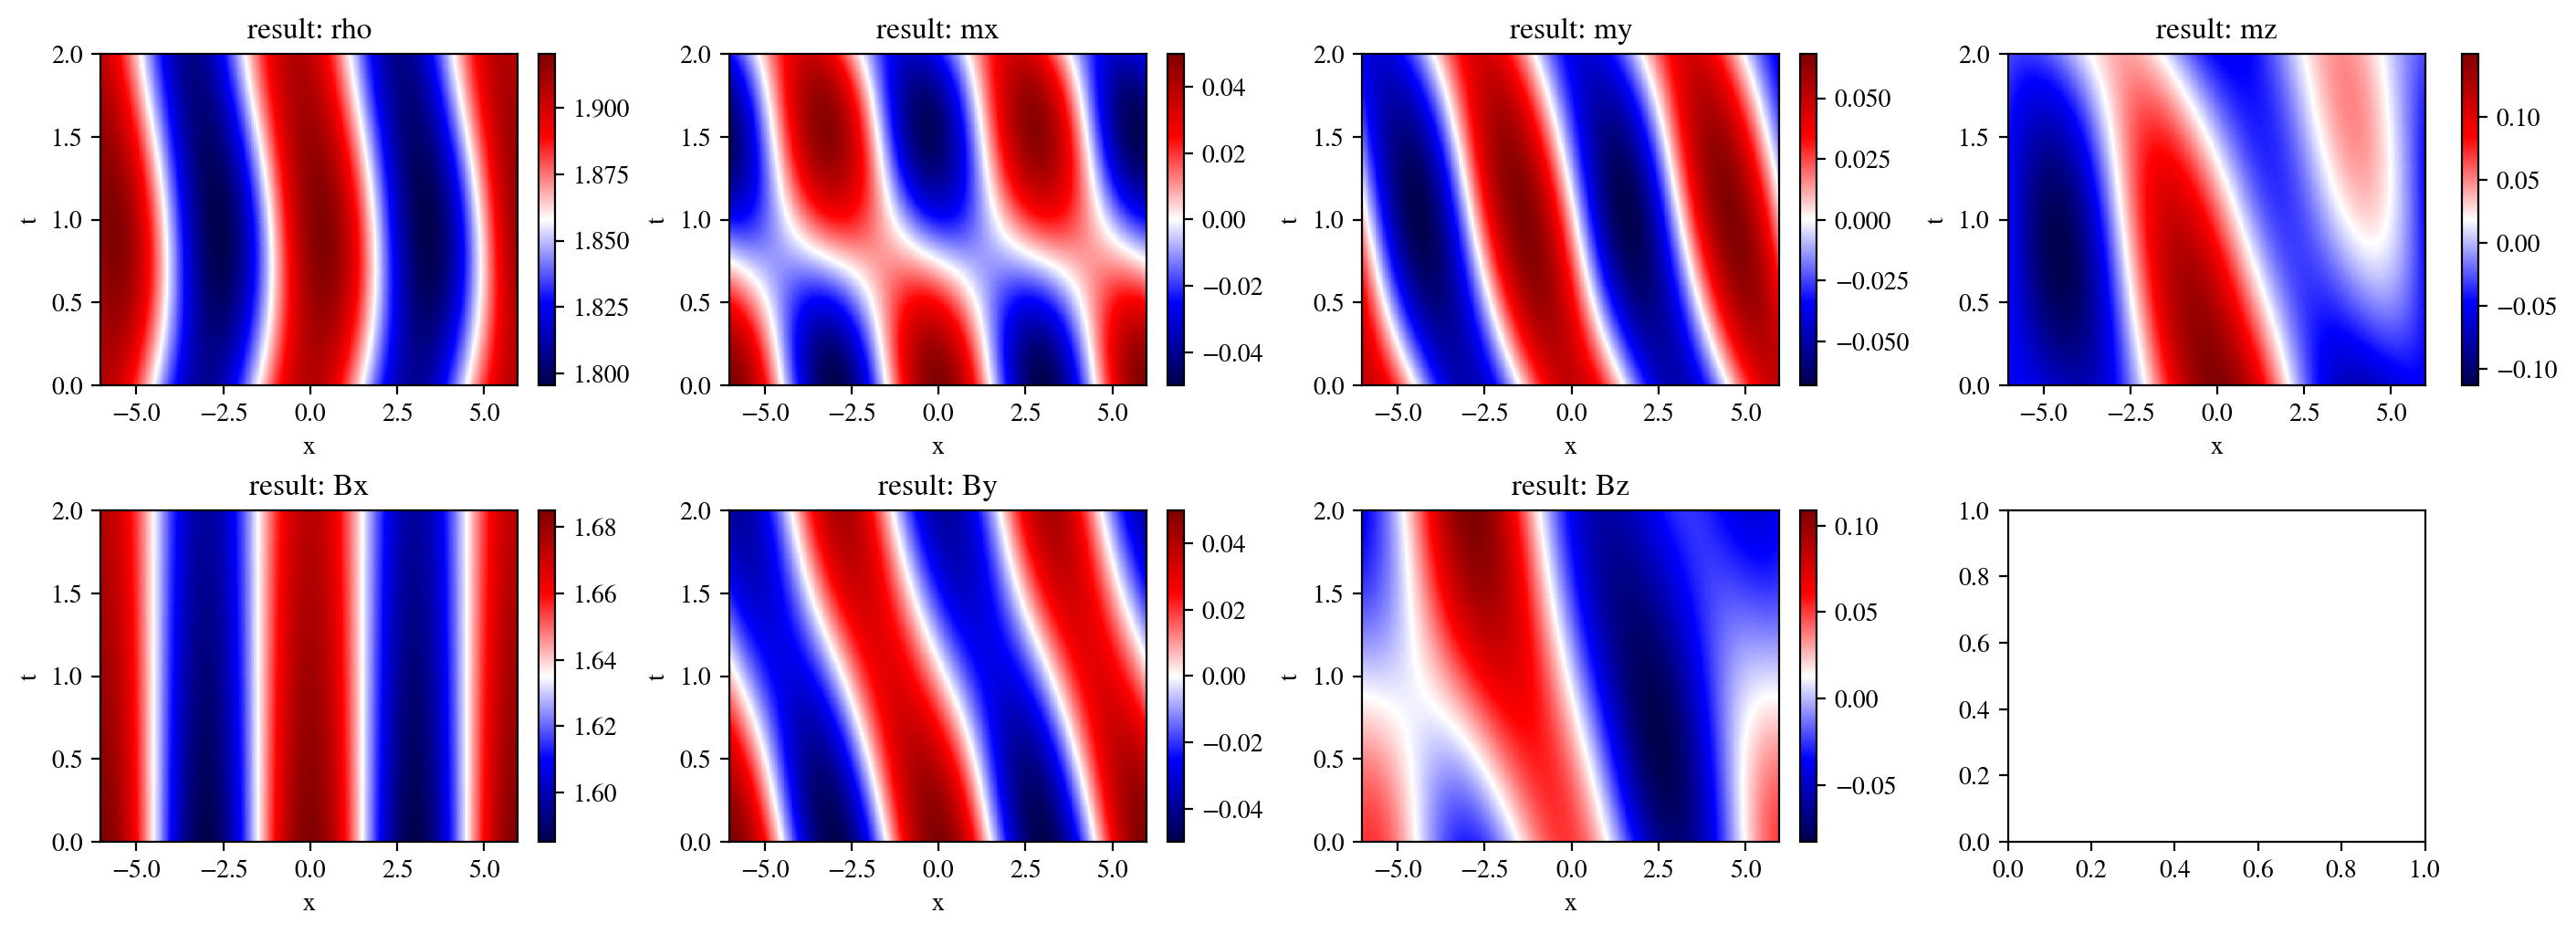

Plotting field rho with shape (207, 256)
Plotting field mx with shape (207, 256)
Plotting field my with shape (207, 256)
Plotting field mz with shape (207, 256)
Plotting field Bx with shape (207, 256)
Plotting field By with shape (207, 256)
Plotting field Bz with shape (207, 256)


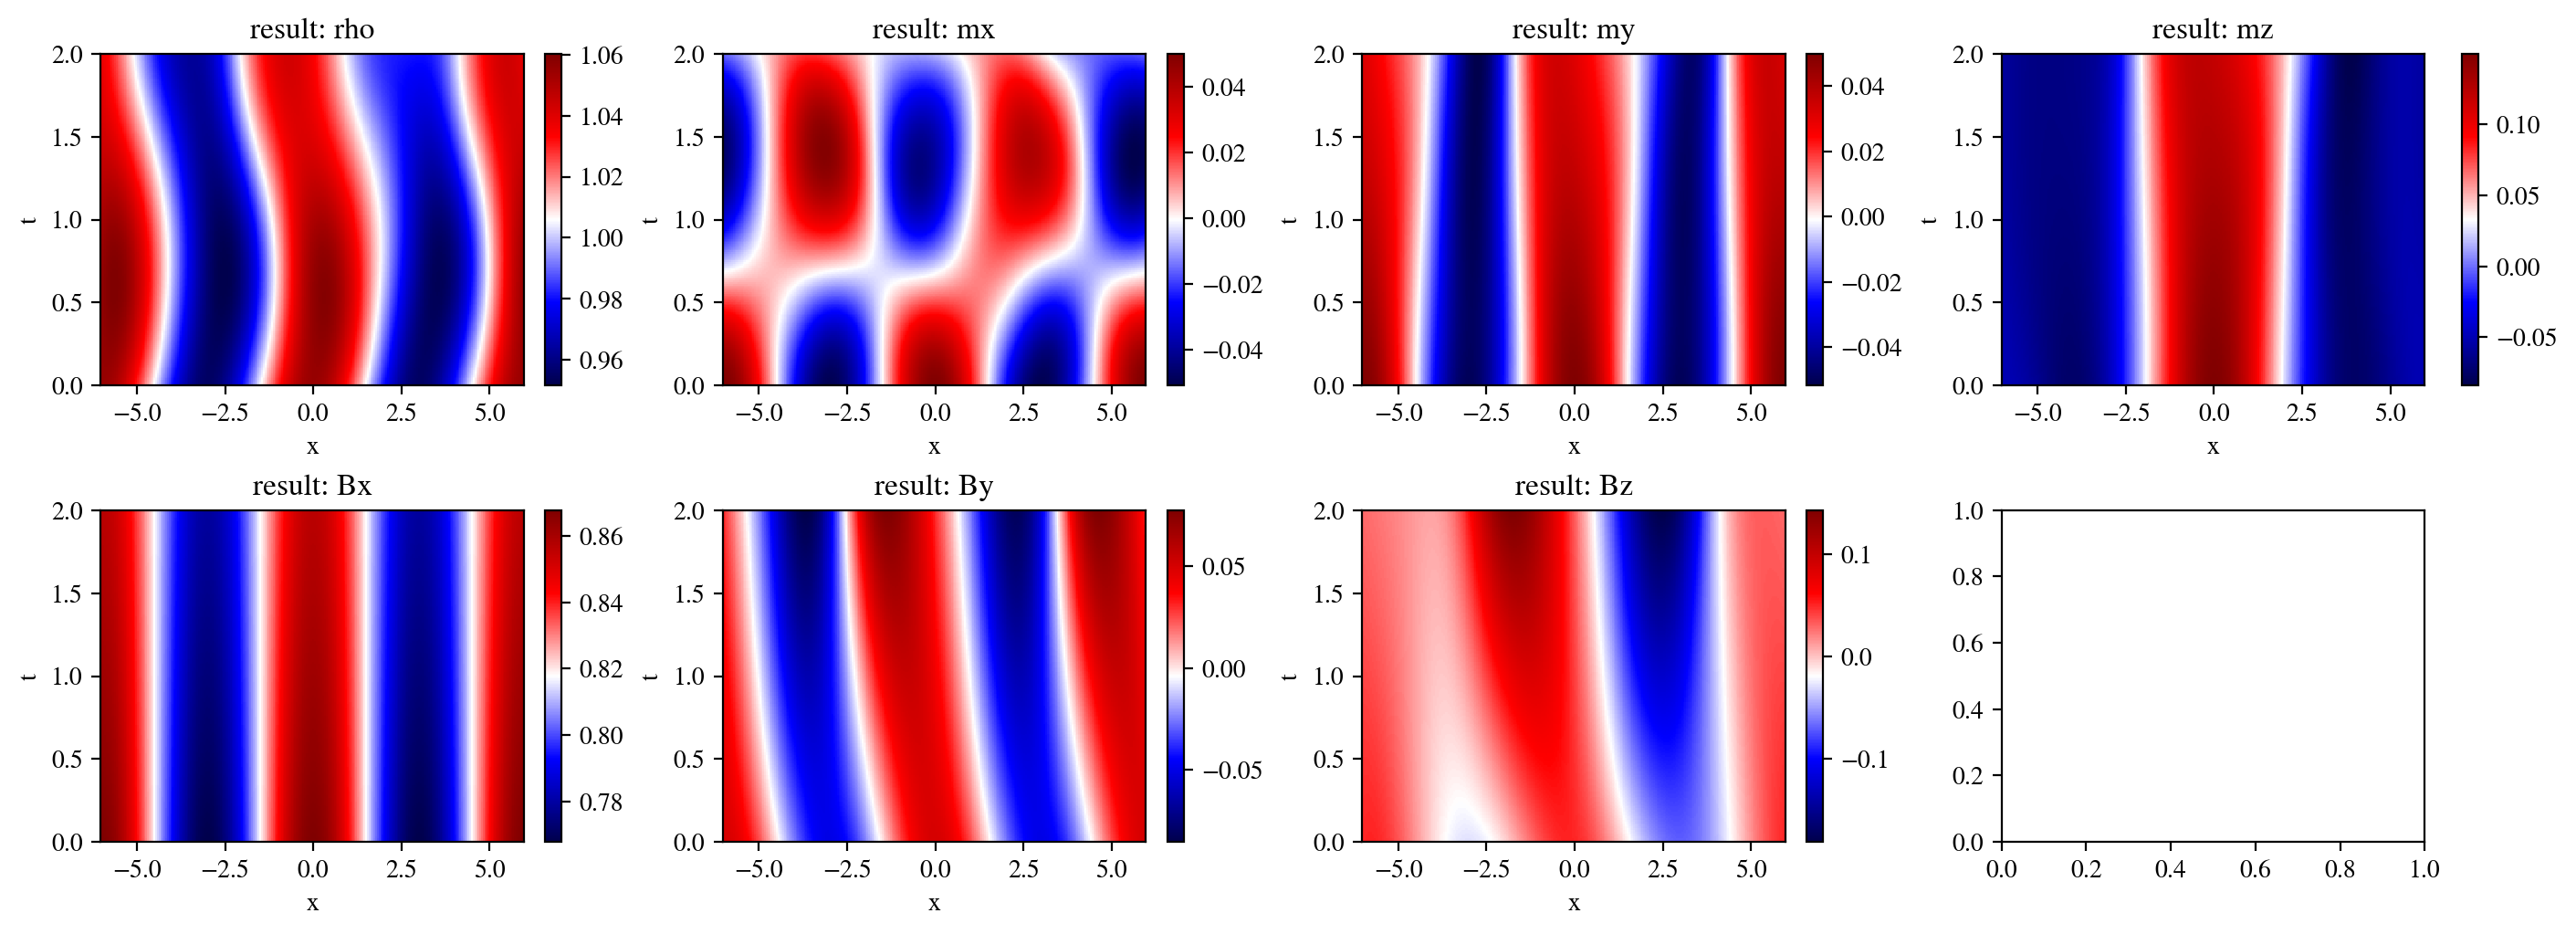

Plotting field rho with shape (207, 256)
Plotting field mx with shape (207, 256)
Plotting field my with shape (207, 256)
Plotting field mz with shape (207, 256)
Plotting field Bx with shape (207, 256)
Plotting field By with shape (207, 256)
Plotting field Bz with shape (207, 256)


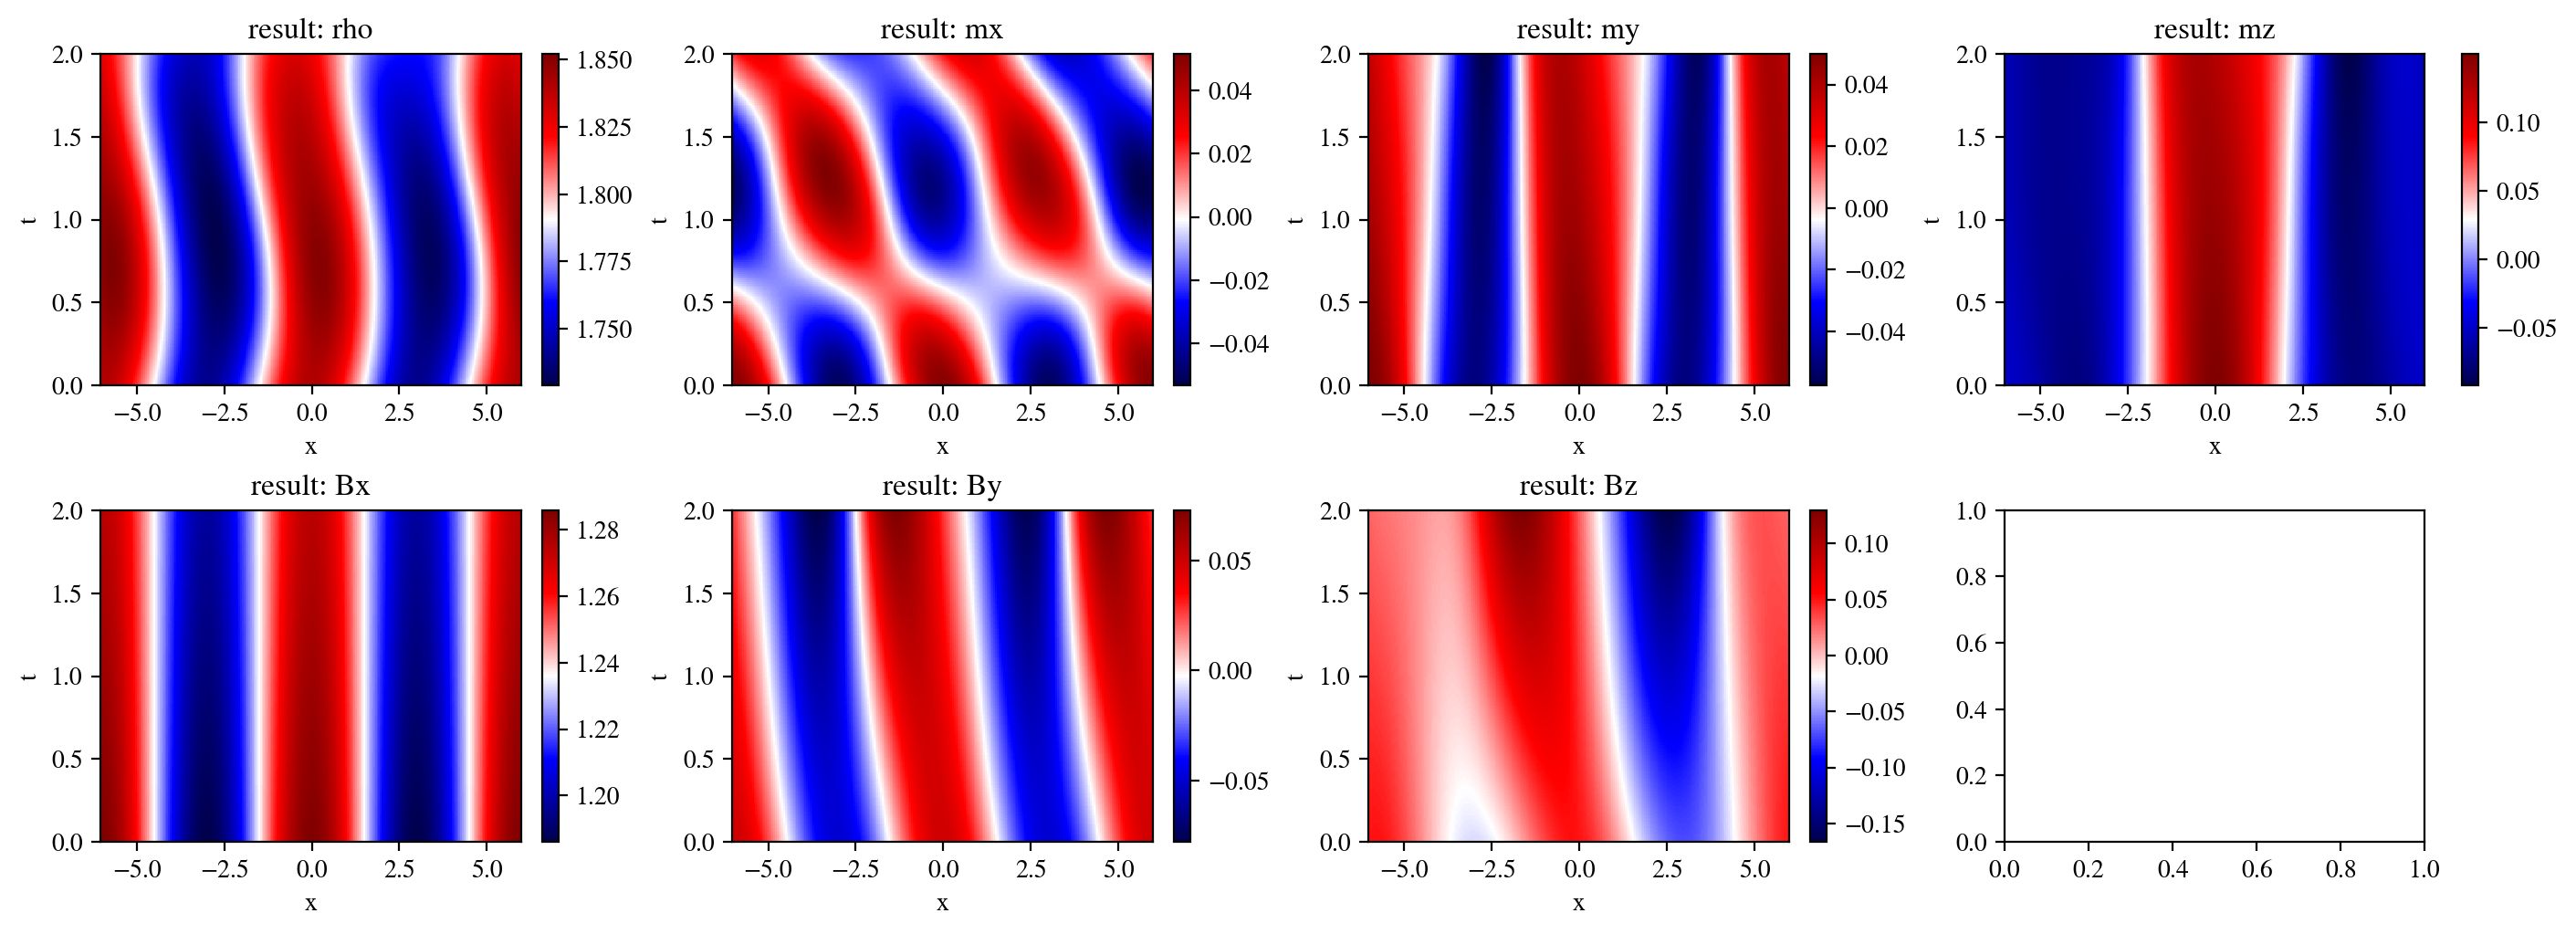

In [70]:
for label, result in results.items():
    
    t = result['t']
    x = result['x']
    fields = {name: result[name] for name in fh.FIELD_NAMES}

    fig, axes = plt.subplots(2, 4, figsize=(14, 5), constrained_layout=True)

    for ax, (title, field) in zip(axes.flat, fields.items()):
        print(f"Plotting field {title} with shape {field.shape}")
        mesh = ax.pcolormesh(x, t, field, shading='auto', cmap='seismic')
        ax.set_title(f'result: {title}')
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        fig.colorbar(mesh, ax=ax)

    plt.show()


## Machine-Learning Surrogate for the CGL Closure

### Building the Training Dataset

The goal is to train a compact MLP that maps the 7 primitive-variable inputs $(\rho,\, u_x,\, u_y,\, u_z,\, B_x,\, B_y,\, B_z)$ to the two CGL pressures $(p_\parallel,\, p_\perp)$. The training data comes directly from the campaign simulations:

1. **Flatten** all $(t, x)$ snapshots from every campaign into individual state vectors.
2. **Compute analytic CGL pressures** at each point using the exact closure $p_\parallel = \rho^{\gamma_\parallel} / |B|^{\gamma_\parallel - 1}$ and $p_\perp = \rho\, |B|^{\gamma_\perp - 1}$.
3. **Package** into train/test splits via `prepare_ml_data`, which also computes normalisation statistics (mean, std) and optionally undersamples the dataset to keep training fast.

The hexbin plots show the support of the training and test sets in $(|B|,\, \rho)$ space. Good coverage of the scan window (crimson dashed rectangle) is essential for the surrogate to generalise — gaps in coverage will lead to extrapolation errors in the growth-rate predictions later.

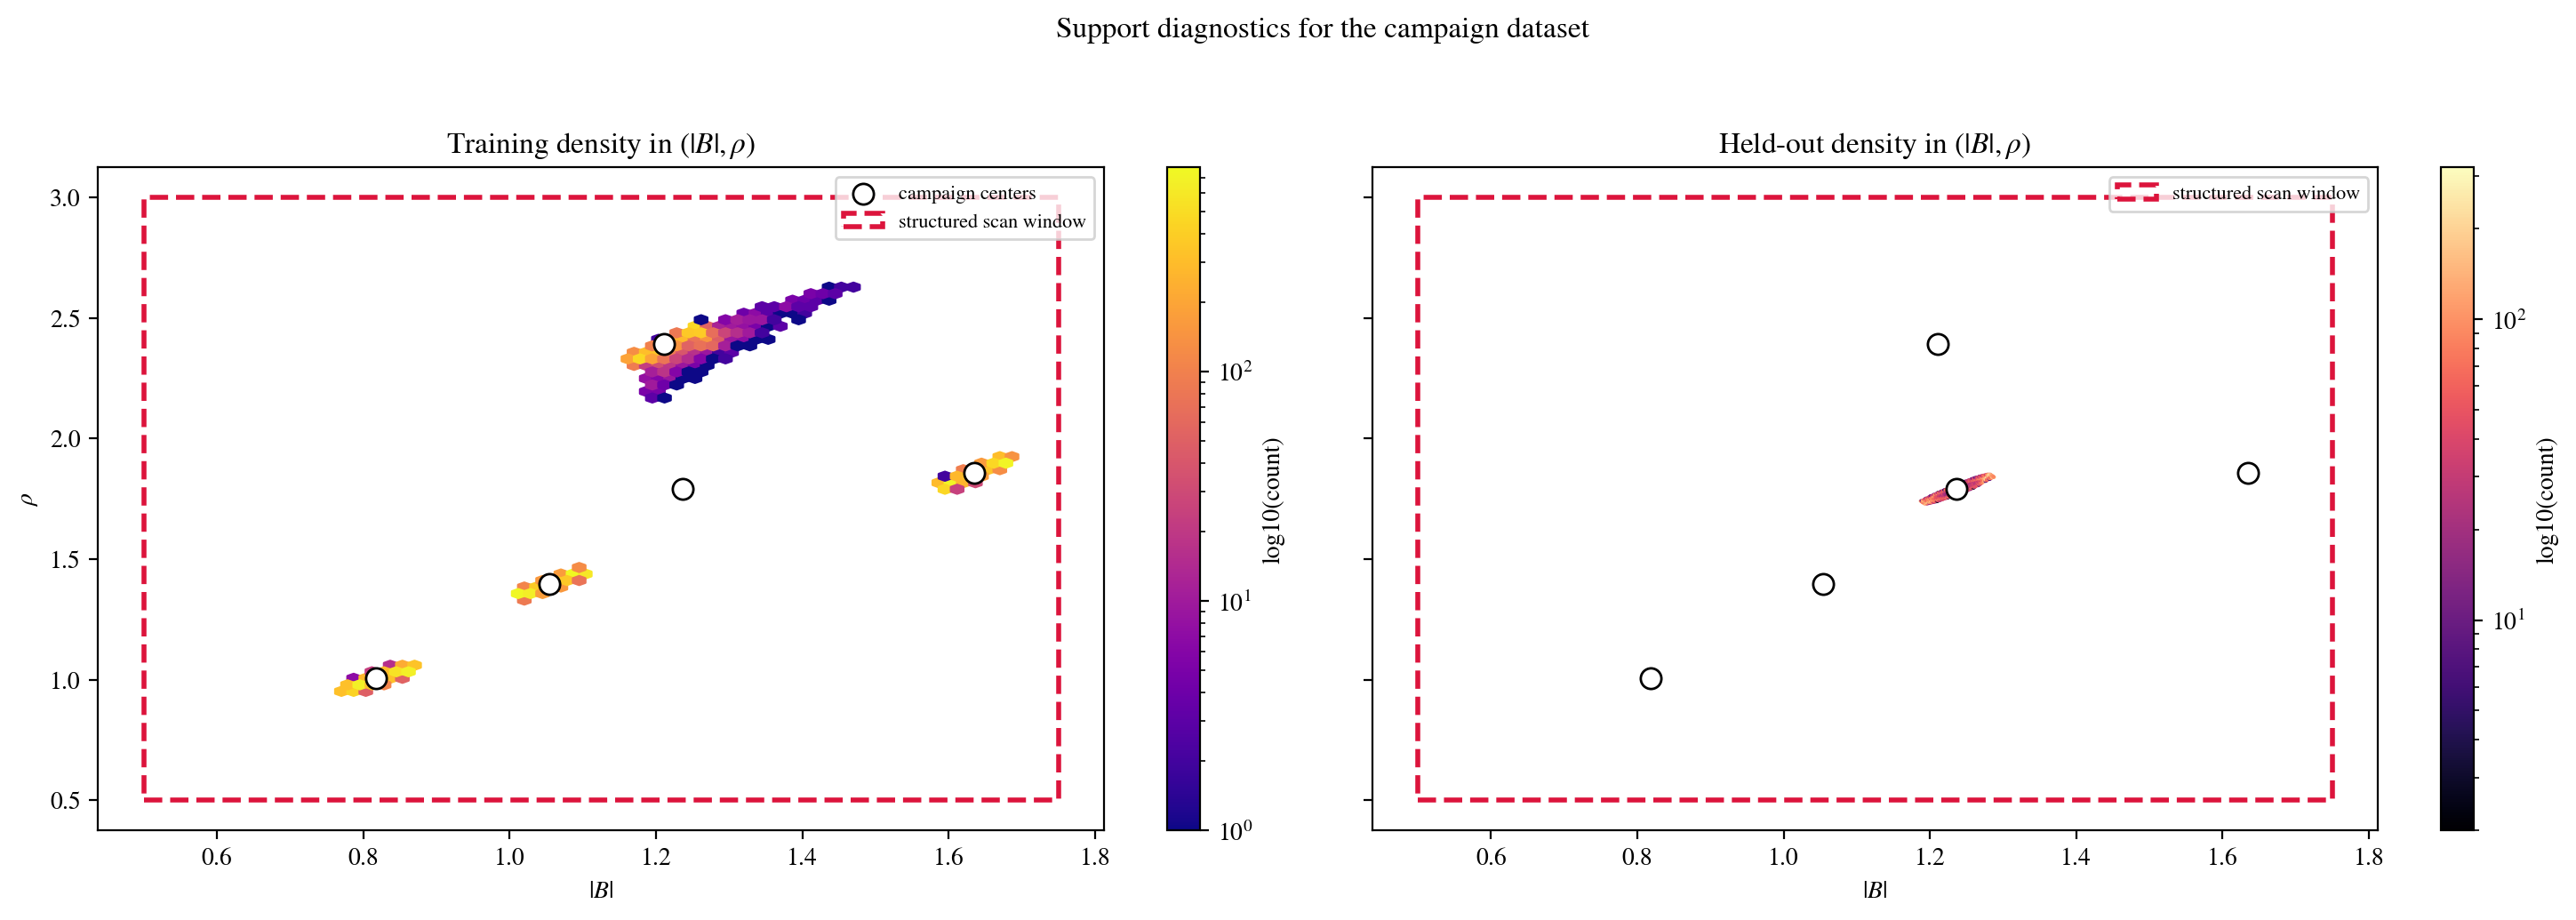

In [71]:
from matplotlib.patches import Rectangle
fh = reload(fh)

for run_name in results.keys():
    results[run_name]['p_par'], results[run_name]['p_perp'], _, _ = fh.cgl_pressures_np(
        results[run_name]['rho'],
        results[run_name]['Bx'],
        results[run_name]['By'],
        results[run_name]['Bz'],
        gamma_par=gamma_par,
        gamma_perp=gamma_perp,
        B_floor=B_floor,
    )

X = np.stack(
    [np.concatenate([results[run_name][field].flatten() for run_name in results.keys()], axis=0) for field in fh.FIELD_NAMES],
    axis=-1,
)
y = np.stack(
    [np.concatenate([results[run_name][field].flatten() for run_name in results.keys()], axis=0) for field in ['p_par', 'p_perp']],
    axis=-1,
)

target_log_eps = 1e-12
data = fh.prepare_ml_data(X, y, target_log_eps=target_log_eps, undersample_fraction=0.1)
data['X_train_raw']

# Support diagnostics for the campaign dataset
Bmag_train = np.sqrt(np.sum(data['X_train_raw'][:, 4:7]**2, axis=1))
rho_train = data['X_train_raw'][:, 0]
Bmag_test = np.sqrt(np.sum(data['X_test_raw'][:, 4:7]**2, axis=1))
rho_test = data['X_test_raw'][:, 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

hb_train = axes[0].hexbin(
    Bmag_train, rho_train, gridsize=55, bins='log', mincnt=1, cmap='plasma'
)
axes[0].scatter(
    campaign_centers[:, 0], campaign_centers[:, 1],
    s=70, c='white', edgecolors='black', linewidths=1.0, label='campaign centers'
)
axes[0].add_patch(Rectangle(
    (scan_B_min, scan_rho_min), scan_B_max - scan_B_min, scan_rho_max - scan_rho_min,
    fill=False, edgecolor='crimson', linewidth=2, linestyle='--', label='structured scan window'
))
axes[0].set_title('Training density in $(|B|, \\rho)$')
axes[0].set_xlabel('$|B|$')
axes[0].set_ylabel('$\\rho$')
axes[0].legend(loc='upper right', fontsize=8)
fig.colorbar(hb_train, ax=axes[0], label='log10(count)')

hb_test = axes[1].hexbin(
    Bmag_test, rho_test, gridsize=55, bins='log', mincnt=1, cmap='magma'
)
axes[1].scatter(
    campaign_centers[:, 0], campaign_centers[:, 1],
    s=70, c='white', edgecolors='black', linewidths=1.0
)
axes[1].add_patch(Rectangle(
    (scan_B_min, scan_rho_min), scan_B_max - scan_B_min, scan_rho_max - scan_rho_min,
    fill=False, edgecolor='crimson', linewidth=2, linestyle='--', label='structured scan window'
))
axes[1].set_title('Held-out density in $(|B|, \\rho)$')
axes[1].set_xlabel('$|B|$')
axes[1].legend(loc='upper right', fontsize=8)
fig.colorbar(hb_test, ax=axes[1], label='log10(count)')

plt.suptitle('Support diagnostics for the campaign dataset', y=1.03)
plt.tight_layout()
plt.show()


### Training the Baseline MLP Surrogate (Data Only — No Physics Loss)

The first surrogate is trained with a **pure data-fitting objective** (MSE on normalised log-pressures). No physics-informed regularisation is applied yet — this serves as the baseline that the three physics-informed methods will be compared against.

Architecture: a 3-hidden-layer MLP with 64 units per layer, dropout 0.10, trained with AdamW + OneCycleLR scheduler, and early stopping with patience 50. After training, the normalisation statistics are embedded into the model so that `model.predict_np(X_raw)` works without external preprocessing.

This "Lumped" model learns the CGL closure purely from simulation data. Its accuracy depends entirely on the coverage of the training campaigns.

In [72]:
fh = reload(fh)

# Train a separate surrogate on the lumped campaign dataset
device = "cuda" if torch.cuda.is_available() else "cpu"
model = fh.MLP(dropout=0.10).to(device)

model, result = fh.train_surrogate(
    model, data['train_dl'], data['test_dl'], device,
    max_epochs=300, patience=50, base_lr=1e-3, weight_decay=1e-4,
    use_rotation_augmentation=False,
    norm_data=data,
)
train_losses = result['train_losses']
test_losses = result['test_losses']

print("\nLumped-campaign training done:")
print(f"  train samples: {len(data['X_train_raw'])}")
print(f"  test samples: {len(data['X_test_raw'])}")
print(f"  best test loss: {result['best_test_loss']:.6f} at epoch {result['best_epoch']}")


epoch    1 | lr 1.01e-04 | train 0.7830 | test 0.0662 | best 0.0662 (ep 1)
epoch   10 | lr 1.60e-04 | train 0.0292 | test 0.0015 | best 0.0013 (ep 8)
epoch   20 | lr 3.25e-04 | train 0.0157 | test 0.0262 | best 0.0013 (ep 8)
epoch   30 | lr 5.50e-04 | train 0.0103 | test 0.0656 | best 0.0013 (ep 8)
epoch   40 | lr 7.75e-04 | train 0.0078 | test 0.1444 | best 0.0013 (ep 8)
epoch   50 | lr 9.40e-04 | train 0.0066 | test 0.2244 | best 0.0013 (ep 8)
Early stopping at epoch 58 (no improvement for 50 epochs).

Lumped-campaign training done:
  train samples: 21196
  test samples: 52992
  best test loss: 0.001349 at epoch 8


### Training Diagnostics and Held-Out Prediction Quality

Two checks for the baseline surrogate:

1. **Training history** (loss vs. epoch): the train and test MSE curves should converge smoothly. A large gap signals overfitting; a plateau signals underfitting or insufficient capacity.
2. **Held-out pressure predictions**: we run the trained model on the test set and compare predicted $p_\parallel$, $p_\perp$ against the analytic CGL values. The RMSE and $R^2$ scores quantify global accuracy. Visual inspection of the time-series overlay catches systematic biases that aggregate metrics can miss.

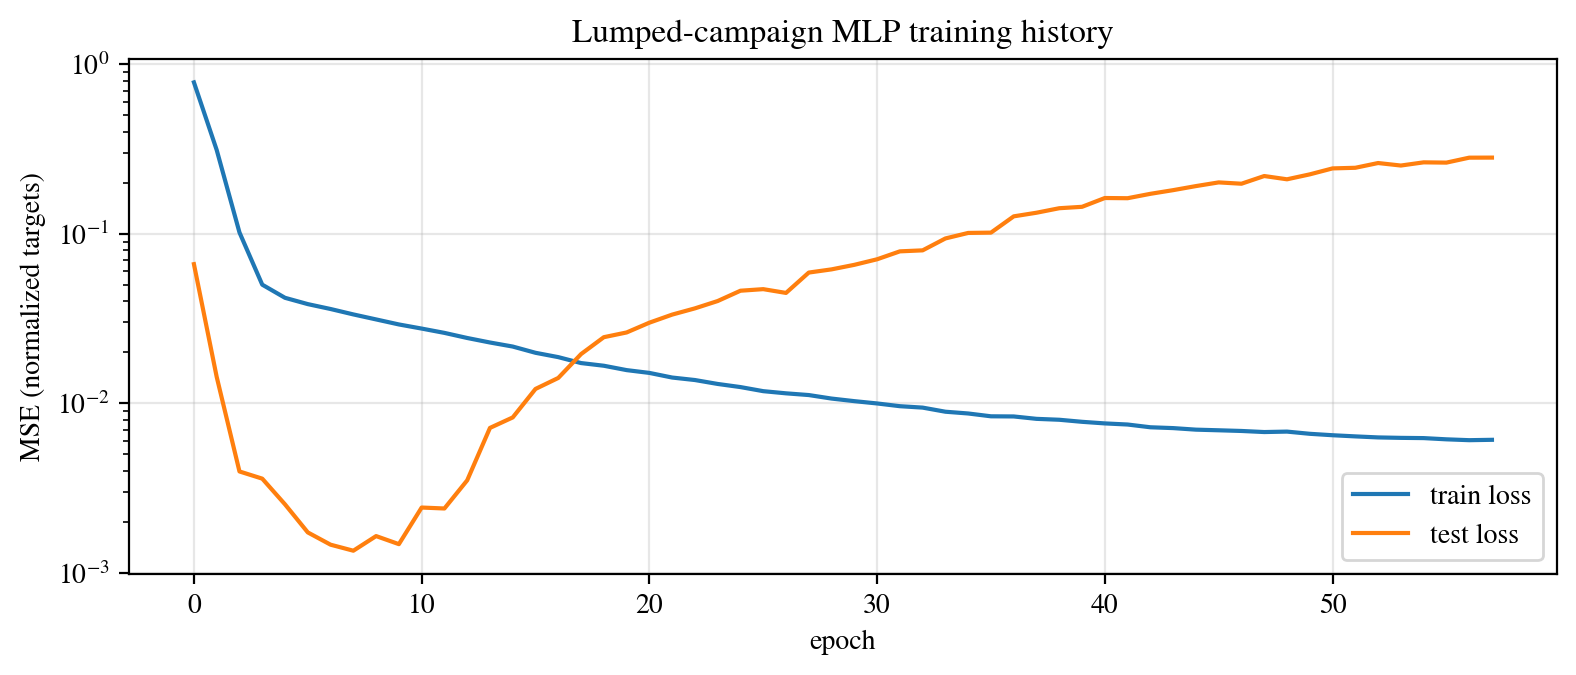

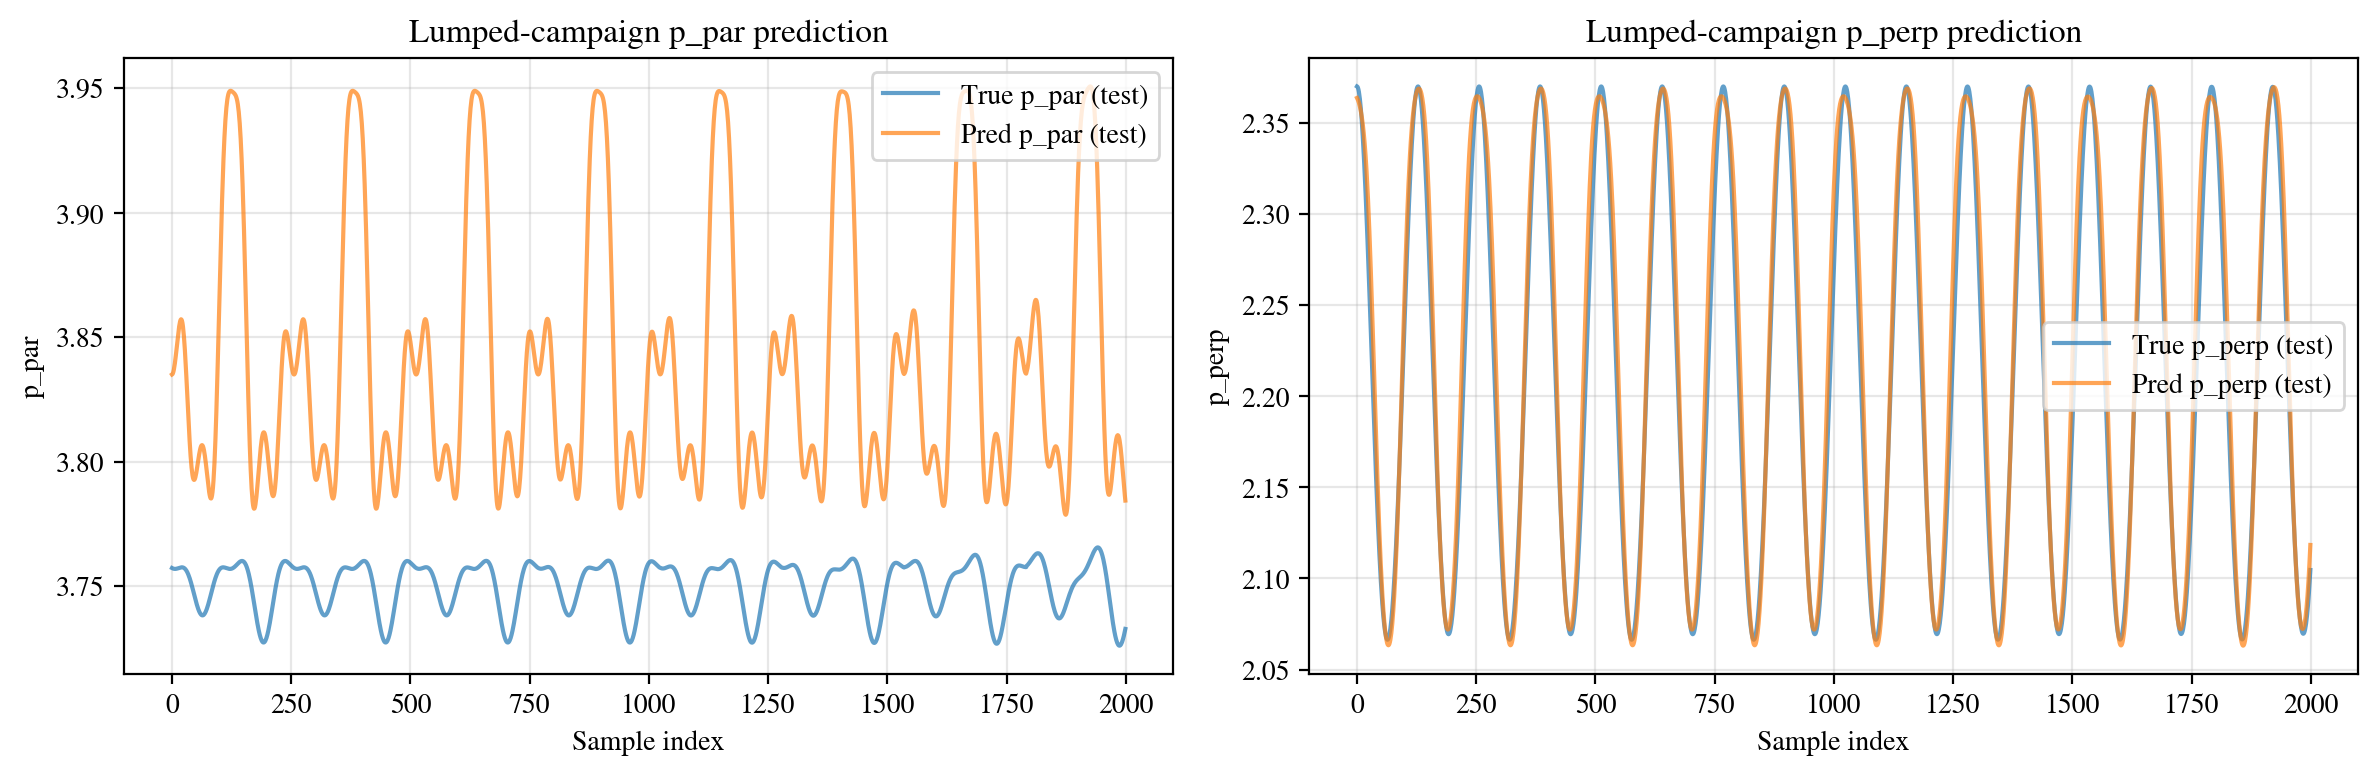

Lumped p_par  Test RMSE: 8.901049e-02
Lumped p_par  Test R²  : -0.295422
Lumped p_perp Test RMSE: 4.701563e-02
Lumped p_perp Test R²  : 0.781728


In [73]:
# Held-out prediction diagnostics for the lumped campaign model
plt.figure(figsize=(8, 3.5))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE (normalized targets)')
plt.title('Lumped-campaign MLP training history')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

y_pred_all = fh.ml_predict_pressures_np(data['X_test_raw'], model, device)
y_true_all = data['y_test_raw']

ppar_pred = y_pred_all[:, 0]
pperp_pred = y_pred_all[:, 1]
ppar_true = y_true_all[:, 0]
pperp_true = y_true_all[:, 1]

sample_size = min(2000, len(ppar_true))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(ppar_true[:sample_size], label='True p_par (test)', alpha=0.7)
axes[0].plot(ppar_pred[:sample_size], label='Pred p_par (test)', alpha=0.7)
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('p_par')
axes[0].set_title('Lumped-campaign p_par prediction')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(pperp_true[:sample_size], label='True p_perp (test)', alpha=0.7)
axes[1].plot(pperp_pred[:sample_size], label='Pred p_perp (test)', alpha=0.7)
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('p_perp')
axes[1].set_title('Lumped-campaign p_perp prediction')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lumped p_par  Test RMSE: {np.sqrt(np.mean((ppar_pred - ppar_true)**2)):.6e}")
print(f"Lumped p_par  Test R²  : {fh.r2_score_np(ppar_true, ppar_pred):.6f}")
print(f"Lumped p_perp Test RMSE: {np.sqrt(np.mean((pperp_pred - pperp_true)**2)):.6e}")
print(f"Lumped p_perp Test R²  : {fh.r2_score_np(pperp_true, pperp_pred):.6f}")


### Flux-Jacobian Eigenvalue Validation

A pointwise pressure fit can look excellent on held-out data yet still produce a **wrong dispersion relation** — because small pressure errors get amplified through the nonlinear flux when computing wave speeds. This cell tests the surrogate at the *dynamical* level:

1. Compute the $7\times 7$ **flux Jacobian** $A_0 = \partial F / \partial Q$ at a reference equilibrium, using PyTorch autograd through the trained ML closure.
2. Extract its **eigenvalues** — these are the characteristic wave speeds (fast magnetosonic, Alfvén, slow magnetosonic, entropy).
3. Compare against the **exact CGL eigenvalues** at the same equilibrium.

The dispersion plot shows $\omega(k) = k \cdot \lambda_i$ for each eigenvalue branch. ML branches (solid) should overlay the CGL theory (dotted). Deviations reveal where the learned closure violates the wave structure of the MHD system.

DATA JACOBIAN ANALYSIS
Equilibrium pressures: p_par=2.226007e+00, p_perp=1.345760e+00
Real parts of ML eigenvalues (sorted):
[-2.37075685 -0.40725525 -0.40725525  0.          0.40725525  0.40725525
  1.9345002 ]
Exact CGL characteristic speeds:
[-2.29582914 -0.305284   -0.305284    0.          0.305284    0.305284
  2.29582914]
Mean relative error (ML vs exact CGL): 2.180e-01
Max  relative error (ML vs exact CGL): 3.340e-01


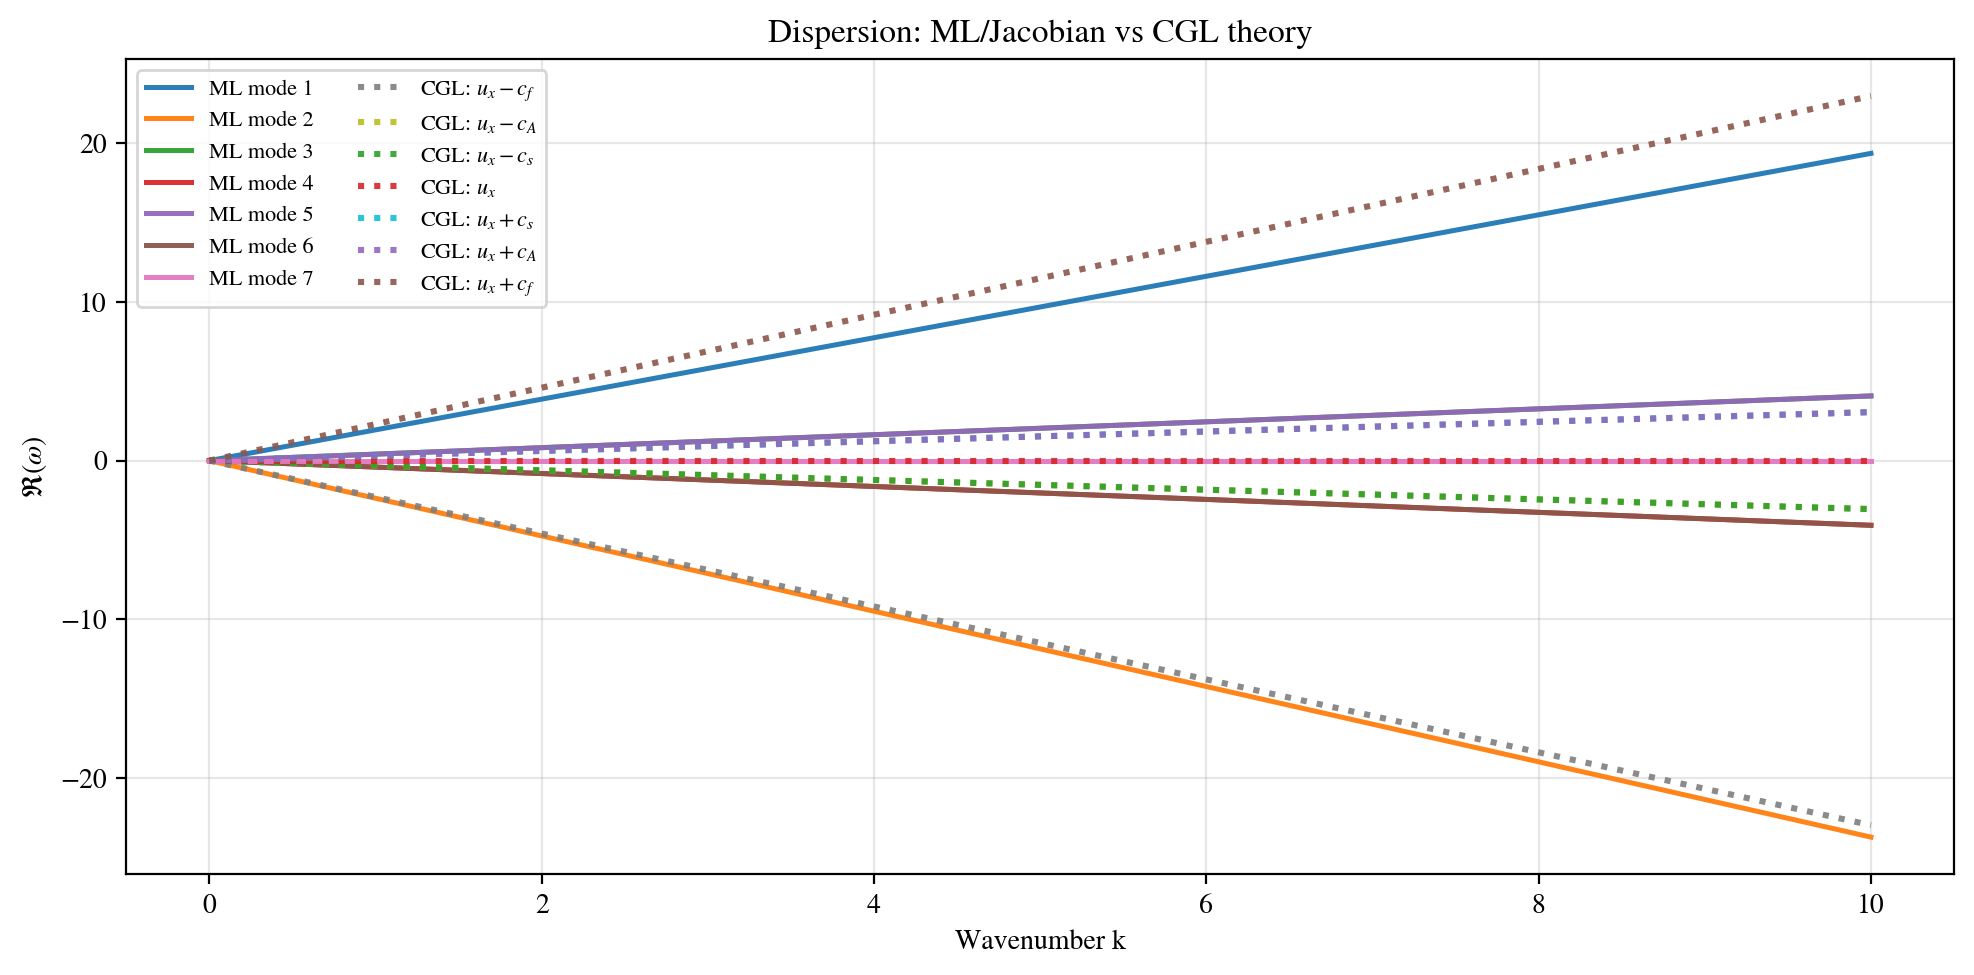

In [74]:
B0_check = campaign_centers[0, 0]
rho0_check = campaign_centers[0, 1]
fh = reload(fh)

# Jacobian/eigenvalue comparison for the lumped campaign model
A0, eigvals, omegas, Q0 = fh.dispersion_from_jacobian(
    rho0=rho0_check, u10=0.0, u20=0.0, u30=0.0,
    B1_0=B0_check, B2_0=0.0, B3_0=0.0,
    net=model, use_cgl=False,
    ks=[0.1, 1.0, 10.0],
)

A0_np = A0.cpu().numpy()
eigvals_np = eigvals.cpu().numpy()

Q0_np = Q0.detach().cpu().numpy()
rho_eq = float(Q0_np[0])
ux_eq = float(Q0_np[1] / max(rho_eq, 1e-14))
uy_eq = float(Q0_np[2] / max(rho_eq, 1e-14))
uz_eq = float(Q0_np[3] / max(rho_eq, 1e-14))
Bx_eq = float(Q0_np[4])
By_eq = float(Q0_np[5])
Bz_eq = float(Q0_np[6])

y_eq = fh.ml_predict_pressures_np(
    np.array([[rho_eq, ux_eq, uy_eq, uz_eq, Bx_eq, By_eq, Bz_eq]], dtype=np.float32),
    model, device,
)[0]

ppar_eq_ml = float(y_eq[0])
pperp_eq_ml = float(y_eq[1])

_, theory_eigvals_t, _, _ = fh.dispersion_from_jacobian(
    rho0=rho0_check, u10=0.0, u20=0.0, u30=0.0,
    B1_0=B0_check, B2_0=0.0, B3_0=0.0,
    net=None, use_cgl=True,
)
theory_eigvals = theory_eigvals_t.cpu().numpy()
theory_speeds = np.sort(np.real(theory_eigvals))
eig_sorted = np.sort(np.real(eigvals_np))
abs_err = np.abs(eig_sorted - theory_speeds)
rel_scale = np.maximum(np.abs(theory_speeds), 1e-8)
rel_err = abs_err / rel_scale

print('=' * 60)
print('DATA JACOBIAN ANALYSIS')
print('=' * 60)
print(f'Equilibrium pressures: p_par={ppar_eq_ml:.6e}, p_perp={pperp_eq_ml:.6e}')
print('Real parts of ML eigenvalues (sorted):')
print(eig_sorted)
print('Exact CGL characteristic speeds:')
print(theory_speeds)
print(f'Mean relative error (ML vs exact CGL): {np.mean(rel_err):.3e}')
print(f'Max  relative error (ML vs exact CGL): {np.max(rel_err):.3e}')

ks_plot = np.linspace(0, 10, 200)
omega_plot = np.outer(ks_plot, eigvals_np)

# ---- Dispersion plot ----
theory_labels = [
    r'CGL: $u_x-c_f$', r'CGL: $u_x-c_A$', r'CGL: $u_x-c_s$',
    r'CGL: $u_x$',
    r'CGL: $u_x+c_s$', r'CGL: $u_x+c_A$', r'CGL: $u_x+c_f$',
]
theory_colors = ['tab:gray', 'tab:olive', 'tab:green', 'tab:red',
                    'tab:cyan', 'tab:purple', 'tab:brown']

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(omega_plot.shape[1]):
    ax.plot(ks_plot, np.real(omega_plot[:, j]), lw=1.8, alpha=0.95, label=f'ML mode {j+1}')
for speed, label, color in zip(theory_speeds, theory_labels, theory_colors):
    ax.plot(ks_plot, ks_plot * speed, linestyle=':', color=color, lw=2.2, alpha=0.9, label=label)
ax.set_xlabel('Wavenumber k')
ax.set_ylabel(r'$\Re(\omega)$')
ax.set_title('Dispersion: ML/Jacobian vs CGL theory')
ax.grid(alpha=0.3)
ax.legend(loc='best', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


### Growth-Rate and Pressure-Surface Comparison (CGL vs Baseline ML)

The single-point eigenvalue check above is necessary but not sufficient. Here we sweep the **entire** $(\rho_0, B_{x0})$ grid and compare three diagnostics side-by-side between exact CGL and the baseline ML surrogate:

| Row | Quantity | Why it matters |
|-----|----------|---------------|
| **Top** | Firehose growth rate $\gamma = \max_i |\mathrm{Im}(\lambda_i)|$ | The instability signature we ultimately want the closure to reproduce |
| **Middle** | $p_\parallel(\rho_0, B_0)$ surface | Direct closure output — errors here propagate to the flux Jacobian |
| **Bottom** | $p_\perp(\rho_0, B_0)$ surface | Same as above for the perpendicular pressure |

The dashed curve is the analytic firehose threshold. Growth-rate maps use a **shared colour scale** (set by the CGL panel) so that differences between CGL and ML are immediately visible. White dots mark the campaign centres that provided the training data.

Printed error metrics give the mean/max absolute and relative growth-rate error on the grid, restricted to the unstable ($\gamma > 10^{-8}$) region where accuracy matters most.

RHO.max() = 3.000e+00, RHO.min() = 5.000e-01, B0.max() = 1.750e+00, B0.min() = 5.000e-01
Scanning cgl Jacobian eigenvalues on 10x10 grid...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Scanning ml Jacobian eigenvalues on 10x10 grid...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Lumped growth-rate mean absolute error vs CGL: 3.828e-01
Lumped growth-rate max  absolute error vs CGL: 3.700e+00
Lumped growth-rate mean relative error vs CGL on unstable points: 2.658e-01
Lumped growth-rate max  relative error vs CGL on unstable points: 1.048e+00
Number of unstable scan points: 54


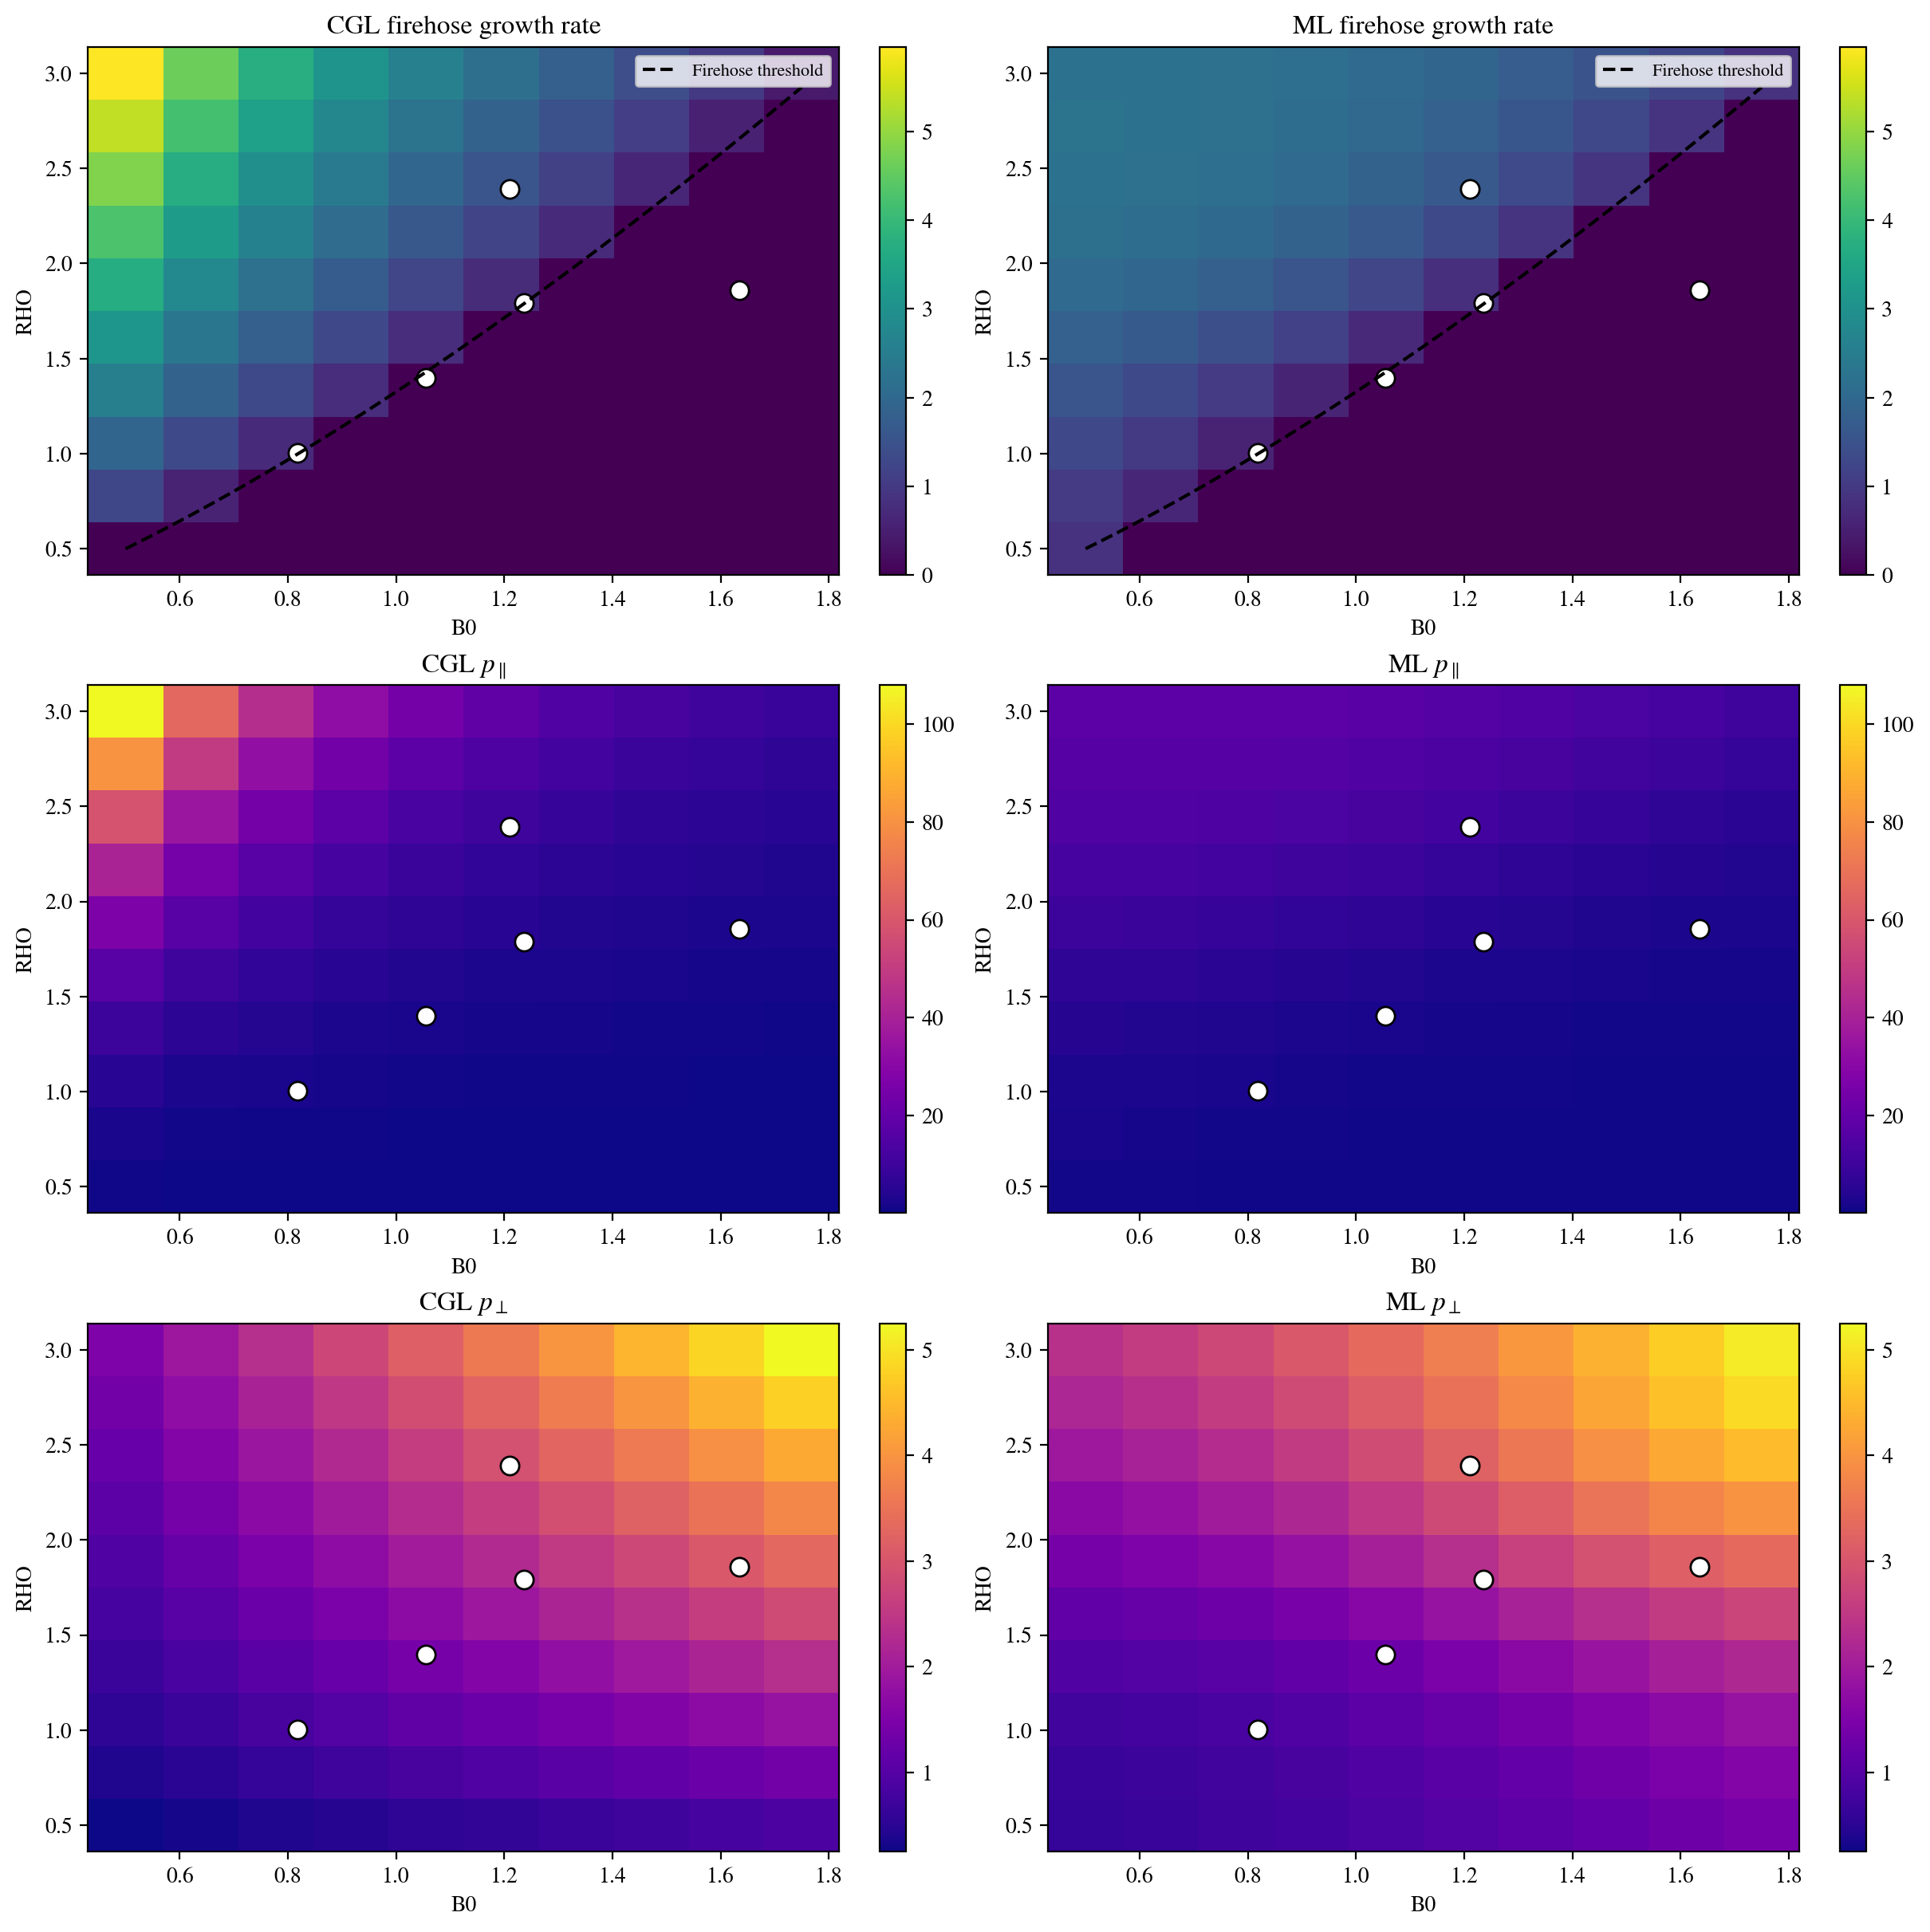

In [75]:
import time as _time
B0, RHO = np.meshgrid(Bx0_values, rho0_values, indexing='xy')
n_bp, n_R  = B0.shape
print(f"{RHO.max() = :.3e}, {RHO.min() = :.3e}, {B0.max() = :.3e}, {B0.min() = :.3e}")
# Growth-rate and pressure-surface diagnostics for the lumped campaign model
gamma = {}
ppar_grid = {}
pperp_grid = {}

fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)

for model_lab, use_cgl, ax_iter in zip(['cgl', 'ml'], [True, False], range(axes.shape[1])):
    gamma[model_lab] = np.zeros_like(B0)

    print(f"Scanning {model_lab} Jacobian eigenvalues on {n_bp}x{n_R} grid...")
    t0 = _time.time()
    for i in range(n_bp):
        for j in range(n_R):
            _, eigs, _, _ = fh.dispersion_from_jacobian(
                rho0=float(RHO[i, j]), u10=0.0, u20=0.0, u30=0.0,
                B1_0=float(B0[i, j]), B2_0=0.0, B3_0=0.0,
                net=model, use_cgl=use_cgl,
            )
            eigs_np = eigs.cpu().numpy()
            gamma[model_lab][i, j] = np.max(np.abs(np.imag(eigs_np)))
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  row {i+1}/{n_bp}  ({_time.time()-t0:.1f}s)")
    print(f"  Done in {_time.time()-t0:.1f}s")

    if use_cgl:
        ppar_grid[model_lab] = RHO**gamma_par / (B0**(gamma_par - 1.0))
        pperp_grid[model_lab] = RHO * (B0**(gamma_perp - 1.0))
    else:
        X_batch = np.column_stack([
            RHO.ravel().astype(np.float32),
            np.zeros(n_bp * n_R, dtype=np.float32),
            np.zeros(n_bp * n_R, dtype=np.float32),
            np.zeros(n_bp * n_R, dtype=np.float32),
            B0.ravel().astype(np.float32),
            np.zeros(n_bp * n_R, dtype=np.float32),
            np.zeros(n_bp * n_R, dtype=np.float32),
        ])
        y_ml     = fh.ml_predict_pressures_np(X_batch, model, device)
        ppar_grid[model_lab] = y_ml[:, 0].reshape(n_bp, n_R)
        pperp_grid[model_lab] = y_ml[:, 1].reshape(n_bp, n_R)

    im0 = axes[0, ax_iter].pcolormesh(
        B0, RHO, gamma[model_lab], shading='auto', cmap='viridis',
        vmax=gamma['cgl'].max(), vmin=gamma['cgl'].min()
    )
    axes[0, ax_iter].scatter(
        campaign_centers[:, 0], campaign_centers[:, 1],
        s=70, c='white', edgecolors='black'
    )
    bx_threshold = np.linspace(Bx_values.min(), Bx_values.max(), 400)
    rho_threshold = np.full_like(bx_threshold, np.nan, dtype=float)
    # firehose threshold
    # The firehose threshold condition p_par - p_perp - B^2 = 0 can be rearranged to find the 
    # critical density rho for a given Bx. For the chosen CGL parameters,
    # p_par = rho^3/B^2 and p_perp = rho Bx, so the threshold condition becomes:
    # rho^3/Bx^2 - rho Bx - Bx^2 = 0 
    # this leads to a cubic equation in rho that can be solved to 
    # find the threshold curve in the (rho0, Bx0) plane.
    for i, bx in enumerate(bx_threshold):
        coeffs = [1.0, 0.0, -bx**3, -bx**4]  # rho^3 - bx^3 rho - bx^4 = 0
        roots = np.roots(coeffs)
        real_positive_roots = roots[np.isclose(roots.imag, 0.0, atol=1e-10) & (roots.real > 0.0)].real
        if len(real_positive_roots):
            rho_threshold[i] = real_positive_roots.max()

    axes[0, ax_iter].plot(bx_threshold, rho_threshold, color='k', linestyle='--', label='Firehose threshold')
    axes[0, ax_iter].set_xlabel('B0')
    axes[0, ax_iter].set_ylabel('RHO')
    axes[0, ax_iter].set_title(f'{model_lab.upper()} firehose growth rate')
    axes[0, ax_iter].legend(loc='best', fontsize=8)
    fig.colorbar(im0, ax=axes[0, ax_iter])

    im1 = axes[1, ax_iter].pcolormesh(
        B0, RHO, ppar_grid[model_lab], shading='auto', cmap='plasma',
        vmax=ppar_grid['cgl'].max(), vmin=ppar_grid['cgl'].min()
    )
    axes[1, ax_iter].scatter(
        campaign_centers[:, 0], campaign_centers[:, 1],
        s=70, c='white', edgecolors='black'
    )
    axes[1, ax_iter].set_xlabel('B0')
    axes[1, ax_iter].set_ylabel('RHO')
    axes[1, ax_iter].set_title(f'{model_lab.upper()} $p_\\parallel$')
    fig.colorbar(im1, ax=axes[1, ax_iter])

    im2 = axes[2, ax_iter].pcolormesh(
        B0, RHO, pperp_grid[model_lab], shading='auto', cmap='plasma',
        vmax=pperp_grid['cgl'].max(), vmin=pperp_grid['cgl'].min()
    )
    axes[2, ax_iter].scatter(
        campaign_centers[:, 0], campaign_centers[:, 1],
        s=70, c='white', edgecolors='black'
    )
    axes[2, ax_iter].set_xlabel('B0')
    axes[2, ax_iter].set_ylabel('RHO')
    axes[2, ax_iter].set_title(f'{model_lab.upper()} $p_\\perp$')
    fig.colorbar(im2, ax=axes[2, ax_iter])

gamma_abs_err = np.abs(gamma['ml'] - gamma['cgl'])
unstable_mask = gamma['cgl'] > 1e-8
print(f"Lumped growth-rate mean absolute error vs CGL: {np.mean(gamma_abs_err):.3e}")
print(f"Lumped growth-rate max  absolute error vs CGL: {np.max(gamma_abs_err):.3e}")
if np.any(unstable_mask):
    gamma_rel_err = gamma_abs_err[unstable_mask] / gamma['cgl'][unstable_mask]
    print(f"Lumped growth-rate mean relative error vs CGL on unstable points: {np.mean(gamma_rel_err):.3e}")
    print(f"Lumped growth-rate max  relative error vs CGL on unstable points: {np.max(gamma_rel_err):.3e}")
    print(f"Number of unstable scan points: {int(np.count_nonzero(unstable_mask))}")
else:
    print('No unstable CGL scan points found; relative growth-rate error not defined.')

plt.show()


## Physics-Informed Training: Three Regularisation Strategies

The baseline surrogate is trained on data alone. When training data is sparse (few campaigns), the model can fit the pressures well in an $L^2$ sense yet still produce **incorrect wave speeds** or **wrong instability thresholds** because it has no structural knowledge of the CGL equations.

We now compare three physics-informed regularisation methods that each add a secondary loss term evaluated on **collocation points** — random equilibrium states sampled uniformly from the scan window at each training step.

### Definitions

| Symbol | Definition |
|--------|-----------|
| $Q$ | Conserved state vector $Q = (\rho,\, m_x,\, m_y,\, m_z,\, B_x,\, B_y,\, B_z)^T$ |
| $Q_q$ | $q$-th collocation state, sampled at zero momentum: $Q_q = (\rho_q,\, 0,\, 0,\, 0,\, B_{x,q},\, B_{y,q},\, B_{z,q})^T$. Momentum is zero because the CGL pressure law depends only on $\rho$ and $\lvert B \rvert$, not on velocity, so non-zero $u$ would add sampling cost without new information. |
| $p_\parallel,\; p_\perp$ | CGL parallel and perpendicular pressures: $p_\parallel = \rho^{\gamma_\parallel} / \lvert B\rvert^{\gamma_\parallel - 1}$, &ensp; $p_\perp = \rho\, \lvert B\rvert^{\gamma_\perp - 1}$, &ensp; with $\gamma_\parallel = 3$, $\gamma_\perp = 2$. |
| $F(Q)$ | 1-D conservative MHD flux vector (7 components: mass, momentum ×3, induction ×3). The pressure enters via the anisotropic pressure tensor $P_{ij} = p_\perp \delta_{ij} + (p_\parallel - p_\perp)\, \hat b_i \hat b_j$. |
| $A(Q) = \partial F / \partial Q$ | $7 \times 7$ flux Jacobian — its eigenvalues are the characteristic wave speeds; complex eigenvalues with $\mathrm{Im}(\lambda) \neq 0$ indicate instability (firehose). |
| $J(Q) = \partial (\log p_\parallel,\, \log p_\perp) / \partial Q$ | $2 \times 7$ closure Jacobian — the local sensitivity of the log-pressures to the conserved state. |
| $\lambda_j(Q)$ | $j$-th eigenvalue of $A(Q)$ (7 total). |
| $\gamma_{\max}(Q)$ | Maximum linear growth rate at state $Q$: $\gamma_{\max} = \max_j\, k\, \lvert \mathrm{Im}(\lambda_j) \rvert$ for wavenumber $k$. |
| $\lVert \cdot \rVert_F$ | Matrix Frobenius norm: $\lVert M \rVert_F = \sqrt{\sum_{ij} M_{ij}^2}$. |
| $\lambda(e)$ | Physics-loss weight at epoch $e$, linearly ramped from 0 over a warmup period. |
| $N$ | Number of collocation points per mini-batch. |

The total loss at each training step is:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda(e)\, \mathcal{L}_{\text{phys}},
$$

where $\mathcal{L}_{\text{data}}$ is the standard MSE on the normalised log-pressures (same as the baseline), and $\mathcal{L}_{\text{phys}}$ differs between the three methods below.

### Method 1: Closure Tangent Matching

**Target quantity:** the $2 \times 7$ closure Jacobian $J(Q) = \partial (\log p_\parallel,\, \log p_\perp) / \partial Q$.

For the CGL closure this Jacobian has a known analytical form (implemented in `cgl_log_pressure_jacobian`). For the ML closure the same $2 \times 7$ matrix is obtained by differentiating $\log p^{\mathrm{ML}}$ with respect to $Q$ via `torch.autograd` with `create_graph=True` (so the tangent loss backpropagates through the model weights — second-order differentiation).

**Physics loss:**

$$
\mathcal{L}_{\text{tangent}} = \frac{1}{N} \sum_{q=1}^{N} \left\| J^{\text{ML}}(Q_q) - J^{\text{CGL}}(Q_q) \right\|_F^2
$$

This enforces that the ML closure has the **same local sensitivity** (tangent plane) as CGL everywhere in the collocation domain. Matching the tangent plane implicitly constrains local wave-speed derivatives without requiring a full eigenvalue decomposition.

**Cost:** 2 backward passes per collocation point (one for each of the 2 log-pressure outputs).

**Hyperparameters used below:** $\lambda = 0.01$, warmup = 30 epochs, $N = 16$ collocation points per batch.

In [76]:
start_time = _time.time()
# ── Re-train on lumped data WITH closure-tangent regularisation (Method 1) ──
from functools import partial
# Physics loss: closure tangent matching against CGL
tangent_loss_fn = partial(
    fh.closure_tangent_loss,
    gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=1e-3,
)

model_phys = fh.MLP(dropout=0.10).to(device)

model_phys, result_phys = fh.train_surrogate(
    model_phys, data['train_dl'], data['test_dl'], device,
    max_epochs=300, patience=50, base_lr=1e-3, weight_decay=1e-4,
    use_rotation_augmentation=False,
    norm_data=data,
    # Physics-informed parameters
    physics_loss_fn=tangent_loss_fn,
    lambda_phys=0.01,              # weight for tangent loss
    lambda_warmup_epochs=30,       # ramp up over first 30 epochs
    n_colloc=16,                   # collocation states per batch
    colloc_rho_range=[scan_rho_min, scan_rho_max],    # match the training data range
    colloc_Bmag_range=[scan_B_min, scan_B_max],
)
end_time = _time.time()
print(f"\nPhysics-informed training completed in {(end_time - start_time)/60:.1f} minutes.")
print(f"\nPhysics-informed training done:")
print(f"  best test loss: {result_phys['best_test_loss']:.6f} at epoch {result_phys['best_epoch']}")
print(f"  final phys loss: {result_phys['phys_losses'][-1]:.4e}")

epoch    1 | lr 1.01e-04 | train 0.7314 | test 0.0801 | best 0.0801 (ep 1) | phys 1.2280e+01 (λ=3.333e-04)
epoch   10 | lr 1.60e-04 | train 0.0311 | test 0.0009 | best 0.0008 (ep 9) | phys 8.0187e+00 (λ=3.333e-03)
epoch   20 | lr 3.25e-04 | train 0.0166 | test 0.0151 | best 0.0008 (ep 9) | phys 6.0521e+00 (λ=6.667e-03)
epoch   30 | lr 5.50e-04 | train 0.0174 | test 0.0088 | best 0.0008 (ep 9) | phys 4.8229e+00 (λ=1.000e-02)
epoch   40 | lr 7.75e-04 | train 0.0203 | test 0.0055 | best 0.0008 (ep 9) | phys 3.3656e+00 (λ=1.000e-02)
epoch   50 | lr 9.40e-04 | train 0.0213 | test 0.0020 | best 0.0002 (ep 41) | phys 2.6221e+00 (λ=1.000e-02)
epoch   60 | lr 1.00e-03 | train 0.0208 | test 0.0052 | best 0.0002 (ep 41) | phys 2.5065e+00 (λ=1.000e-02)
epoch   70 | lr 9.96e-04 | train 0.0201 | test 0.0065 | best 0.0002 (ep 41) | phys 2.1893e+00 (λ=1.000e-02)
epoch   80 | lr 9.83e-04 | train 0.0205 | test 0.0059 | best 0.0002 (ep 41) | phys 1.8434e+00 (λ=1.000e-02)
epoch   90 | lr 9.62e-04 | train 

#### Method 1 — Training Curves

The left panel shows the standard data-loss convergence (train vs. test MSE). The right panel shows the **tangent physics loss** $\| J^{\rm ML} - J^{\rm CGL} \|_F^2$ over epochs. After the warmup ramp, this loss should decrease steadily — indicating that the ML closure's local derivatives are being pulled toward the CGL Jacobian structure.

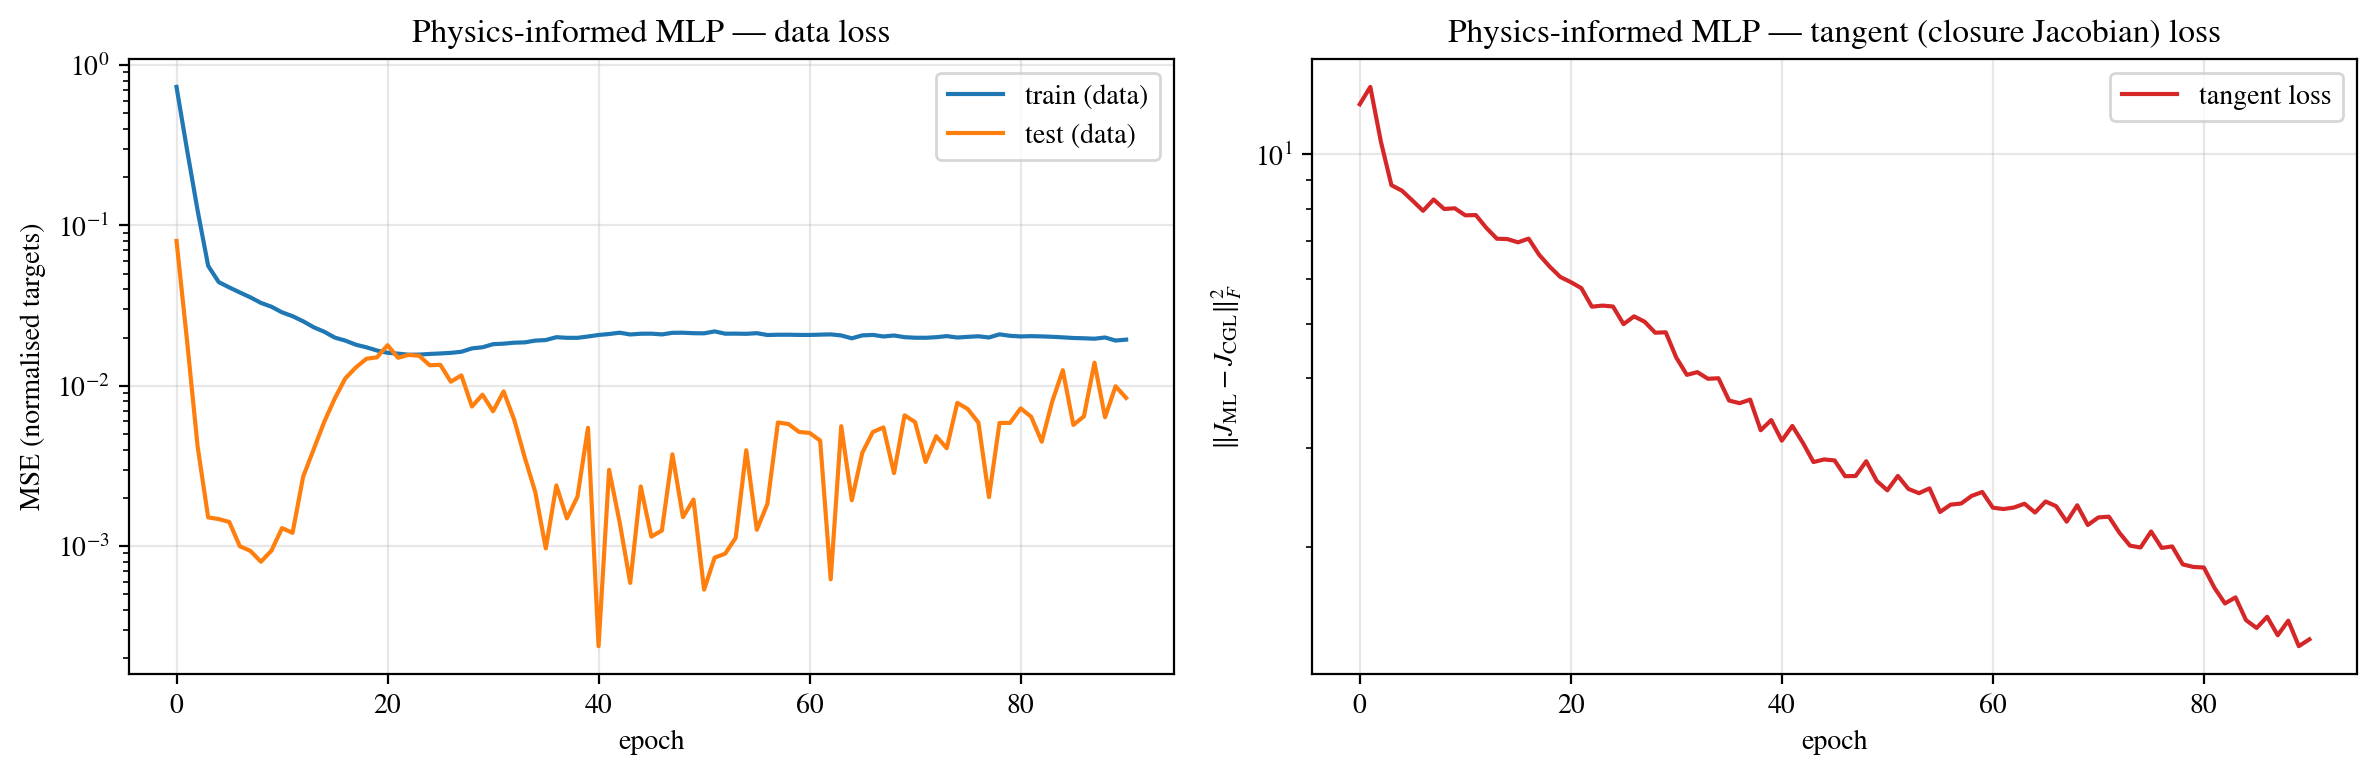

In [77]:
# ── Training curves: data loss + physics loss ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(result_phys['train_losses'], label='train (data)')
axes[0].plot(result_phys['test_losses'], label='test (data)')
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (normalised targets)')
axes[0].set_title('Physics-informed MLP — data loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(result_phys['phys_losses'], color='tab:red', label='tangent loss')
axes[1].set_yscale('log')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel(r'$\|J_{\rm ML} - J_{\rm CGL}\|_F^2$')
axes[1].set_title('Physics-informed MLP — tangent (closure Jacobian) loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Intermediate Growth-Rate Comparison: Baseline vs Method 1

Before training the remaining two methods, we check whether the tangent-matching regularisation actually improved the **growth-rate map**. The panels below compare CGL (analytic), the baseline (data-only) MLP, and the Method 1 (tangent-regularised) MLP across the $(k, B_x)$ grid. Look for reduced spurious growth-rate lobes outside the physical firehose wedge.

Scanning CGL...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Scanning Lumped...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Scanning Lumped+Tangent...
  row 1/10  (0.0s)
  row 10/10  (0.5s)
  Done in 0.5s


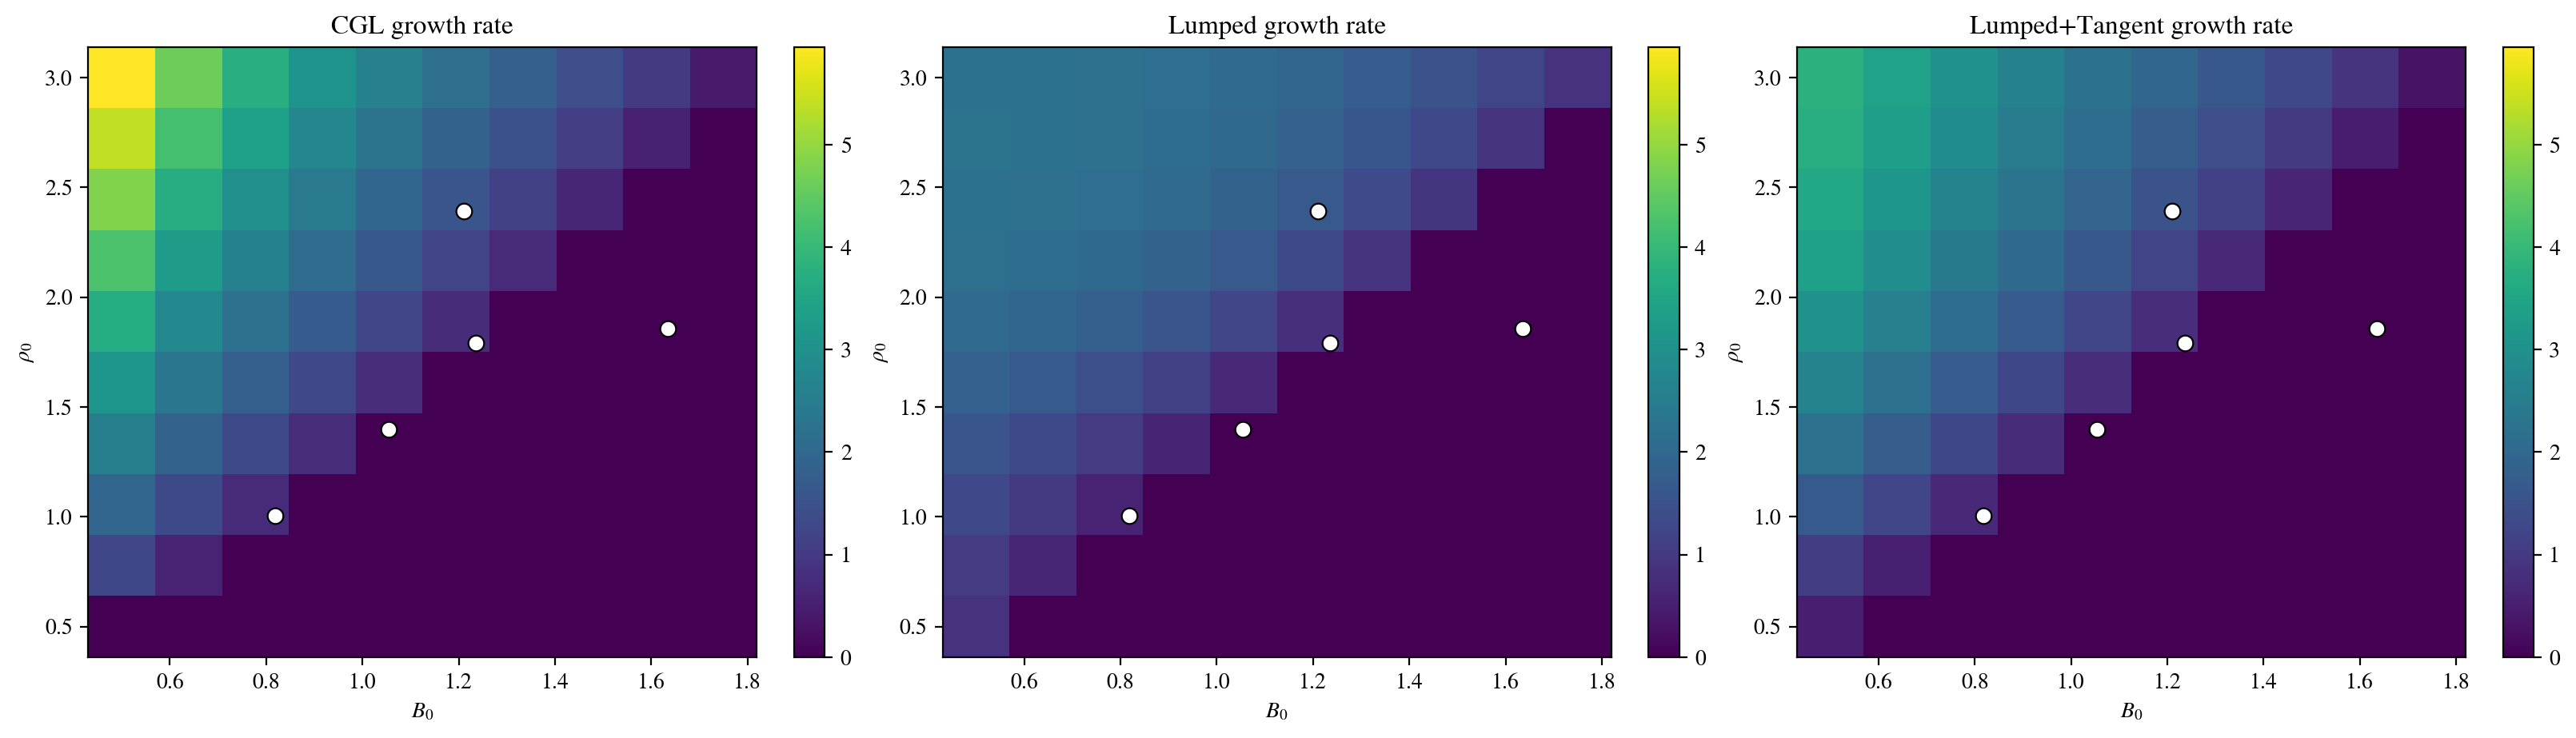


Lumped vs CGL:
  mean |Δγ|: 3.828e-01
  max  |Δγ|: 3.700e+00
  mean rel err (unstable): 2.658e-01
  max  rel err (unstable): 1.048e+00

Lumped+Tangent vs CGL:
  mean |Δγ|: 1.663e-01
  max  |Δγ|: 2.148e+00
  mean rel err (unstable): 9.749e-02
  max  rel err (unstable): 3.610e-01


In [78]:
# ── Growth-rate comparison: lumped (no physics) vs lumped+tangent vs CGL ──
gamma_scans = {}

for label, use_cgl, net in [
    ('CGL', True, None),
    ('Lumped', False, model),
    ('Lumped+Tangent', False, model_phys),
]:
    gamma_scans[label] = np.zeros_like(B0)
    active_net = net
    print(f"Scanning {label}...")
    t0 = _time.time()
    for i in range(n_bp):
        for j in range(n_R):
            _, eigs, _, _ = fh.dispersion_from_jacobian(
                rho0=float(RHO[i, j]), u10=0.0, u20=0.0, u30=0.0,
                B1_0=float(B0[i, j]), B2_0=0.0, B3_0=0.0,
                net=active_net, use_cgl=use_cgl,
            )
            gamma_scans[label][i, j] = np.max(np.abs(eigs.cpu().numpy().imag))
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  row {i+1}/{n_bp}  ({_time.time()-t0:.1f}s)")
    print(f"  Done in {_time.time()-t0:.1f}s")

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
vmax = gamma_scans['CGL'].max()
vmin = gamma_scans['CGL'].min()

for ax, label in zip(axes, ['CGL', 'Lumped', 'Lumped+Tangent']):
    im = ax.pcolormesh(B0, RHO, gamma_scans[label], shading='auto',
                       cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(campaign_centers[:, 0], campaign_centers[:, 1],
               s=50, c='white', edgecolors='black', linewidths=0.8)
    ax.set_xlabel('$B_0$')
    ax.set_ylabel(r'$\rho_0$')
    ax.set_title(f'{label} growth rate')
    fig.colorbar(im, ax=ax)

plt.show()

# Error metrics
for label in ['Lumped', 'Lumped+Tangent']:
    ae = np.abs(gamma_scans[label] - gamma_scans['CGL'])
    mask = gamma_scans['CGL'] > 1e-8
    print(f"\n{label} vs CGL:")
    print(f"  mean |Δγ|: {ae.mean():.3e}")
    print(f"  max  |Δγ|: {ae.max():.3e}")
    if mask.any():
        re = ae[mask] / gamma_scans['CGL'][mask]
        print(f"  mean rel err (unstable): {re.mean():.3e}")
        print(f"  max  rel err (unstable): {re.max():.3e}")

### Method 2: Flux Jacobian Matching

**Target quantity:** the full $7 \times 7$ flux Jacobian $A(Q) = \partial F / \partial Q$.

This matrix encodes **all** wave-propagation information of the system: its eigenvalues are the characteristic speeds $\lambda_j$, and its eigenvectors define the wave polarisation. By penalising $\lVert A^{\mathrm{ML}} - A^{\mathrm{CGL}} \rVert_F^2$ we constrain not just the pressure response (as in Method 1) but also the coupling between all seven conservation equations.

For the CGL reference, $A^{\mathrm{CGL}}(Q_q)$ is evaluated with `torch.no_grad` (no graph needed since we only need the target value). For the ML closure, $A^{\mathrm{ML}}(Q_q)$ is computed with `create_graph=True` so the loss backpropagates into the network weights.

**Physics loss:**

$$
\mathcal{L}_{\text{Jacobian}} = \frac{1}{N} \sum_{q=1}^{N} \left\| A^{\text{ML}}(Q_q) - A^{\text{CGL}}(Q_q) \right\|_F^2
$$

where $\lVert \cdot \rVert_F$ is the Frobenius norm over all $7 \times 7 = 49$ entries.

**Cost:** 7 backward passes with `create_graph=True` per collocation point (one per row of the $7 \times 7$ Jacobian), roughly $3.5\times$ the cost of Method 1.

**Why a smaller $\lambda$?** The Frobenius norm of a $7 \times 7$ matrix is inherently larger than that of a $2 \times 7$ matrix, so a smaller weight keeps the physics term comparable in magnitude to the data loss.

**Hyperparameters used below:** $\lambda = 0.001$, warmup = 30 epochs, $N = 8$ collocation points per batch.

In [79]:
# ── Method 2: Flux Jacobian matching ──────────────────────────────────────
flux_jac_loss_fn = partial(
    fh.flux_jacobian_loss,
    gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=1e-3,
)

model_fluxjac = fh.MLP(dropout=0.10).to(device)

model_fluxjac, result_fluxjac = fh.train_surrogate(
    model_fluxjac, data['train_dl'], data['test_dl'], device,
    max_epochs=300, patience=50, base_lr=1e-3, weight_decay=1e-4,
    use_rotation_augmentation=False,
    norm_data=data,
    physics_loss_fn=flux_jac_loss_fn,
    lambda_phys=0.001,             # smaller weight — 7x7 Frobenius norm is larger
    lambda_warmup_epochs=30,
    n_colloc=8,                    # fewer collocation pts (7 backward passes each)
    colloc_rho_range=[scan_rho_min, scan_rho_max],
    colloc_Bmag_range=[scan_B_min, scan_B_max],
)

print(f"\nFlux-Jacobian training done:")
print(f"  best test loss: {result_fluxjac['best_test_loss']:.6f} at epoch {result_fluxjac['best_epoch']}")
print(f"  final phys loss: {result_fluxjac['phys_losses'][-1]:.4e}")

epoch    1 | lr 1.01e-04 | train 0.7358 | test 0.0697 | best 0.0697 (ep 1) | phys 3.5990e+03 (λ=3.333e-05)
epoch   10 | lr 1.60e-04 | train 0.0446 | test 0.0144 | best 0.0027 (ep 3) | phys 1.7324e+03 (λ=3.333e-04)
epoch   20 | lr 3.25e-04 | train 0.0455 | test 0.0101 | best 0.0027 (ep 3) | phys 1.0102e+03 (λ=6.667e-04)
epoch   30 | lr 5.50e-04 | train 0.0454 | test 0.0020 | best 0.0020 (ep 30) | phys 4.2199e+02 (λ=1.000e-03)
epoch   40 | lr 7.75e-04 | train 0.0395 | test 0.0107 | best 0.0020 (ep 30) | phys 3.7707e+02 (λ=1.000e-03)
epoch   50 | lr 9.40e-04 | train 0.0354 | test 0.0140 | best 0.0020 (ep 30) | phys 3.3314e+02 (λ=1.000e-03)
epoch   60 | lr 1.00e-03 | train 0.0348 | test 0.0102 | best 0.0020 (ep 30) | phys 3.0997e+02 (λ=1.000e-03)
epoch   70 | lr 9.96e-04 | train 0.0342 | test 0.0107 | best 0.0020 (ep 30) | phys 3.4989e+02 (λ=1.000e-03)
epoch   80 | lr 9.83e-04 | train 0.0332 | test 0.0122 | best 0.0020 (ep 30) | phys 4.4209e+02 (λ=1.000e-03)
Early stopping at epoch 80 (no 

#### Method 2 — Training Curves

Same two-panel layout as Method 1: data MSE on the left, physics loss (flux-Jacobian Frobenius norm) on the right. The Jacobian loss may start higher than the tangent loss because the full system Jacobian has more entries to match.

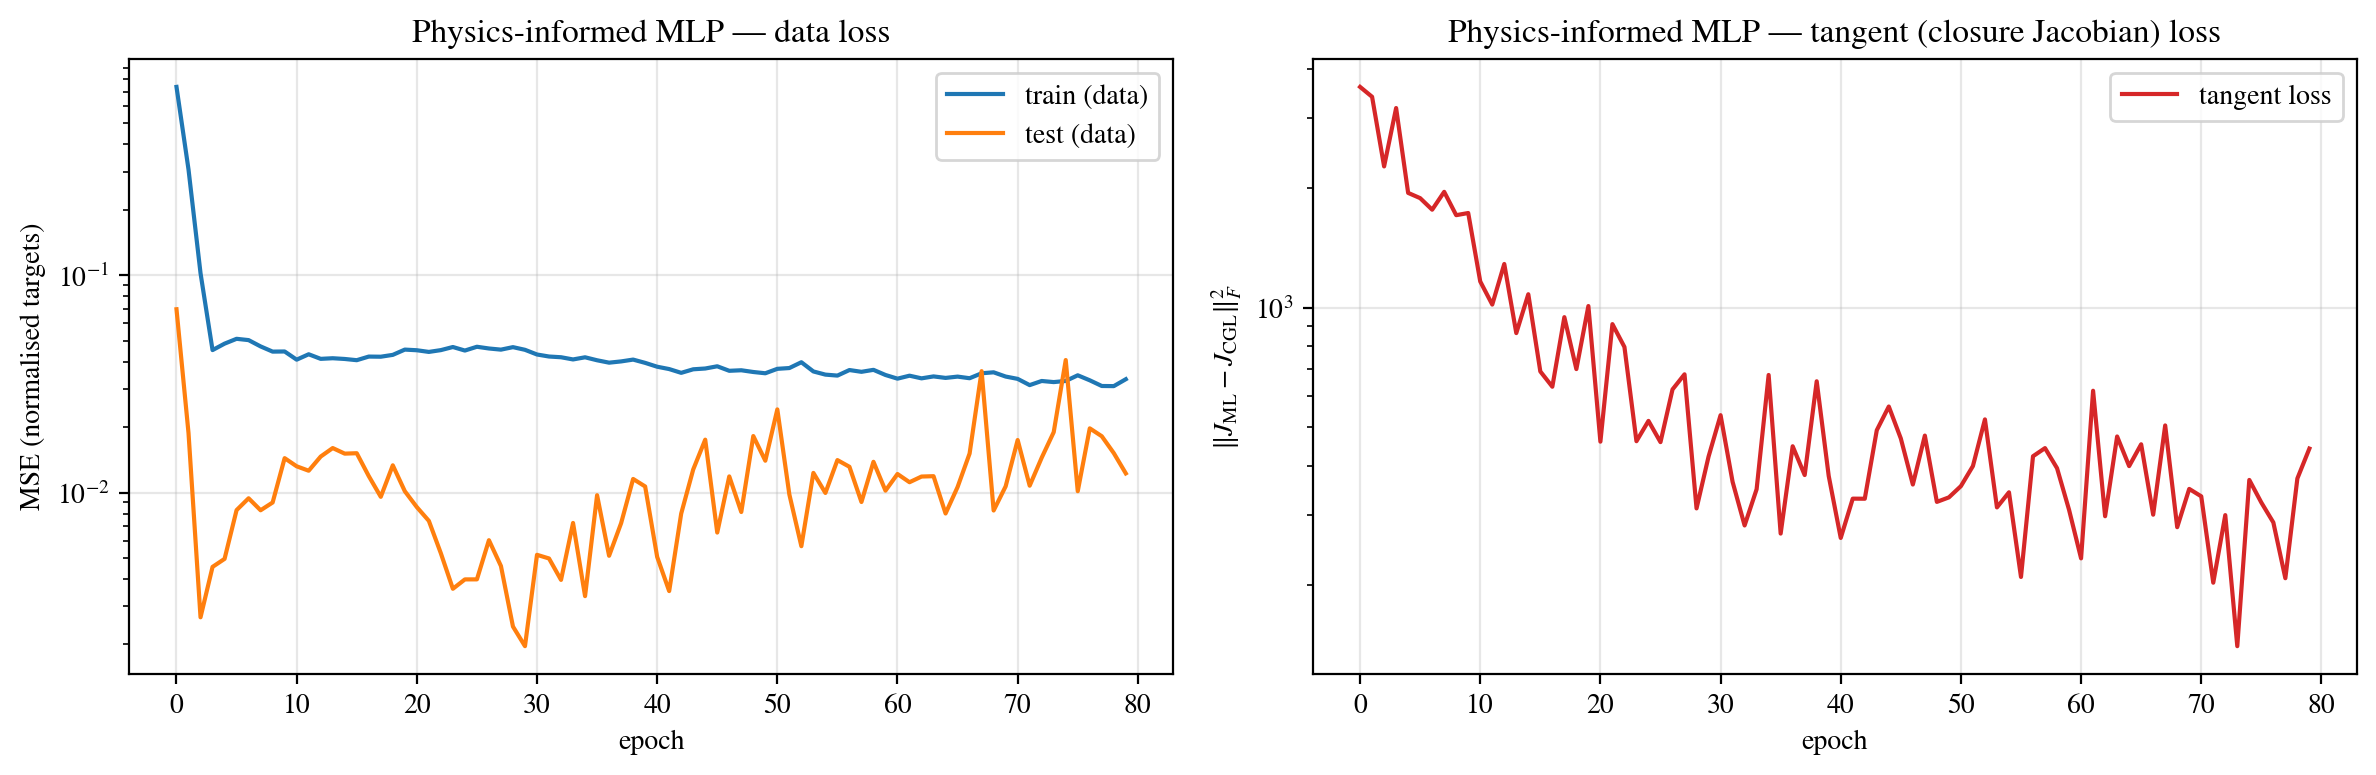

In [80]:
# ── Training curves: data loss + physics loss ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(result_fluxjac['train_losses'], label='train (data)')
axes[0].plot(result_fluxjac['test_losses'], label='test (data)')
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (normalised targets)')
axes[0].set_title('Physics-informed MLP — data loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(result_fluxjac['phys_losses'], color='tab:red', label='tangent loss')
axes[1].set_yscale('log')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel(r'$\|J_{\rm ML} - J_{\rm CGL}\|_F^2$')
axes[1].set_title('Physics-informed MLP — tangent (closure Jacobian) loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Method 3: Growth-Rate Matching

**Target quantity:** the maximum linear growth rate $\gamma_{\max}(Q)$, the single scalar most directly relevant to firehose instability.

Given a flux Jacobian $A(Q)$ with eigenvalues $\lambda_j(Q)$ ($j = 1, \ldots, 7$), the growth rates at wavenumber $k$ are $\gamma_j = k\,\lvert \mathrm{Im}(\lambda_j) \rvert$. Taking the hard $\max$ is not differentiable, so we use a **logsumexp soft-max** with temperature $T$:

$$
\tilde\gamma_{\max}(Q) \;=\; T \,\ln\!\Bigl(\sum_{j=1}^{7} \exp\!\bigl(\gamma_j(Q) / T\bigr)\Bigr)
$$

As $T \to 0^+$ this recovers the true maximum; at finite $T$ it provides a smooth, differentiable approximation. We use $T = 5$ and $k = 1$.

To keep $\gamma_j$ differentiable at zero (where $\lvert \cdot \rvert$ has a kink), the implementation uses the smooth approximation $\gamma_j = k\,\sqrt{\mathrm{Im}(\lambda_j)^2 + \epsilon}$ with $\epsilon = 10^{-12}$.

**Physics loss:**

$$
\mathcal{L}_{\text{growth}} = \frac{1}{N} \sum_{q=1}^{N} \bigl(\tilde\gamma_{\max}^{\,\text{ML}}(Q_q) - \tilde\gamma_{\max}^{\,\text{CGL}}(Q_q)\bigr)^2
$$

The CGL target $\tilde\gamma_{\max}^{\,\text{CGL}}$ is computed with `torch.no_grad` and then `.detach()`-ed, so only the ML branch receives gradients.

**Cost:** requires a full eigendecomposition (`torch.linalg.eigvals`) of the $7 \times 7$ flux Jacobian per collocation point, plus the Jacobian itself. This is the most expensive method, but provides the most **physically direct** constraint — it directly penalises wrong instability growth rates.

**Why a larger $\lambda$?** The growth-rate loss is a single squared scalar (rather than a sum over matrix entries), so its magnitude is much smaller. A larger weight $\lambda = 1.0$ compensates.

**Caveat:** differentiating through eigenvalue decomposition is numerically fragile near degenerate eigenvalues and complex-conjugate crossings; prefer Methods 1 or 2 when growth-rate accuracy is not the dominant concern.

**Hyperparameters used below:** $\lambda = 1.0$, warmup = 30 epochs, $N = 8$ collocation points per batch, $k = 1.0$, $T = 5.0$.

In [81]:
# ── Method 3: Growth-rate matching ────────────────────────────────────────
growth_loss_fn = partial(
    fh.growth_rate_loss,
    gamma_par=gamma_par, gamma_perp=gamma_perp, B_floor=1e-3,
    k=1.0, temperature=5.0,
)

model_growth = fh.MLP(dropout=0.10).to(device)

model_growth, result_growth = fh.train_surrogate(
    model_growth, data['train_dl'], data['test_dl'], device,
    max_epochs=300, patience=50, base_lr=1e-3, weight_decay=1e-4,
    use_rotation_augmentation=False,
    norm_data=data,
    physics_loss_fn=growth_loss_fn,
    lambda_phys=1.0,               # growth-rate loss is small — needs larger weight
    lambda_warmup_epochs=30,
    n_colloc=8,                    # fewer pts (eigen-decomposition per pt)
    colloc_rho_range=[scan_rho_min, scan_rho_max],
    colloc_Bmag_range=[scan_B_min, scan_B_max],
)

print(f"\nGrowth-rate training done:")
print(f"  best test loss: {result_growth['best_test_loss']:.6f} at epoch {result_growth['best_epoch']}")
print(f"  final phys loss: {result_growth['phys_losses'][-1]:.4e}")

epoch    1 | lr 1.01e-04 | train 0.7089 | test 0.0870 | best 0.0870 (ep 1) | phys 1.0671e+00 (λ=3.333e-02)
epoch   10 | lr 1.60e-04 | train 0.0378 | test 0.0040 | best 0.0016 (ep 4) | phys 2.7254e-01 (λ=3.333e-01)
epoch   20 | lr 3.25e-04 | train 0.0333 | test 0.0154 | best 0.0016 (ep 4) | phys 1.1257e-01 (λ=6.667e-01)
epoch   30 | lr 5.50e-04 | train 0.0296 | test 0.0171 | best 0.0016 (ep 4) | phys 9.1520e-02 (λ=1.000e+00)
epoch   40 | lr 7.75e-04 | train 0.0291 | test 0.0151 | best 0.0016 (ep 4) | phys 7.5340e-02 (λ=1.000e+00)
epoch   50 | lr 9.40e-04 | train 0.0271 | test 0.0101 | best 0.0016 (ep 4) | phys 6.3177e-02 (λ=1.000e+00)
Early stopping at epoch 54 (no improvement for 50 epochs).

Growth-rate training done:
  best test loss: 0.001597 at epoch 4
  final phys loss: 6.1262e-02


#### Training Convergence Comparison: All Three Methods

The $2 \times 3$ panel below puts all three methods side by side. Each column is one method; the top row shows data MSE, the bottom row shows the respective physics loss. This makes it easy to spot trade-offs: a method with lower physics loss but higher data loss may be over-regularised.

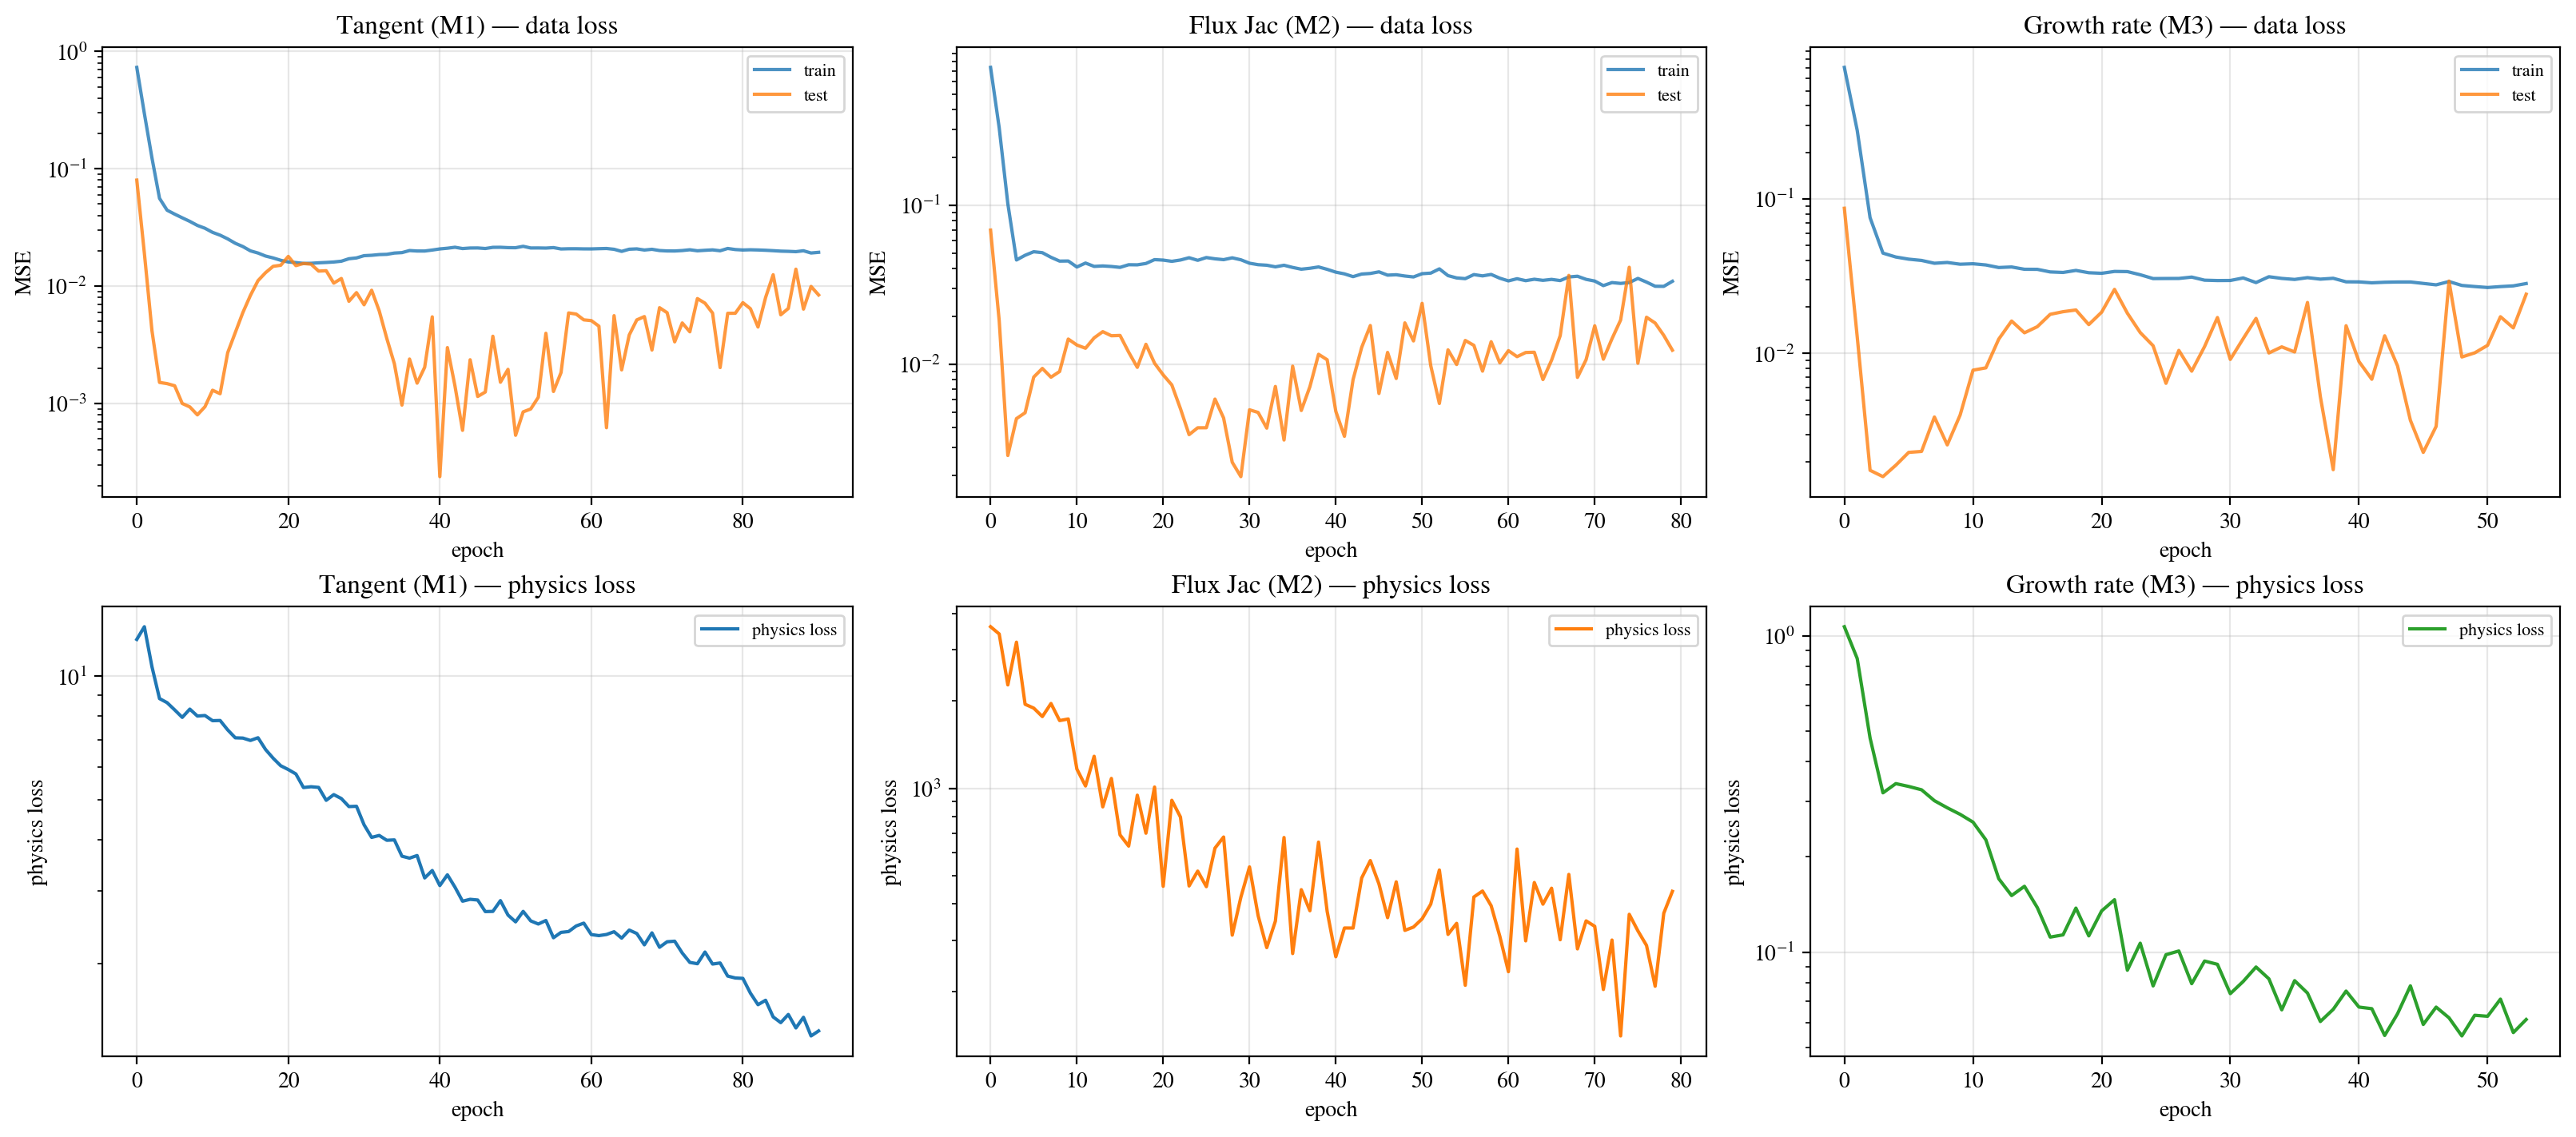

In [82]:
# ── Training curves for all three methods ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

for col, (label, res, color) in enumerate([
    ('Tangent (M1)', result_phys, 'tab:blue'),
    ('Flux Jac (M2)', result_fluxjac, 'tab:orange'),
    ('Growth rate (M3)', result_growth, 'tab:green'),
]):
    axes[0, col].plot(res['train_losses'], label='train', alpha=0.8)
    axes[0, col].plot(res['test_losses'], label='test', alpha=0.8)
    axes[0, col].set_yscale('log')
    axes[0, col].set_xlabel('epoch')
    axes[0, col].set_ylabel('MSE')
    axes[0, col].set_title(f'{label} — data loss')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    phys = res['phys_losses']
    # filter out zeros for log scale
    phys_nz = [max(p, 1e-20) for p in phys]
    axes[1, col].plot(phys_nz, color=color, label='physics loss')
    axes[1, col].set_yscale('log')
    axes[1, col].set_xlabel('epoch')
    axes[1, col].set_ylabel('physics loss')
    axes[1, col].set_title(f'{label} — physics loss')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

plt.show()

### Final Growth-Rate Benchmark: All Five Models

The definitive comparison: we evaluate the growth-rate map $\gamma(k, B_x)$ for **all five closures** on the same grid:

| Label | Description |
|-------|-------------|
| **CGL** | Analytic double-adiabatic closure (ground truth) |
| **Lumped** | Baseline MLP trained on simulation data only |
| **M1 – Tangent** | MLP + closure-tangent regularisation |
| **M2 – Jacobian** | MLP + flux-Jacobian regularisation |
| **M3 – Growth** | MLP + growth-rate regularisation |

All panels share the same colour scale so discrepancies are immediately visible. The bottom row shows the **error** $|\gamma^{\rm ML} - \gamma^{\rm CGL}|$ for each ML model. A successful physics-informed method should shrink these errors, especially inside the firehose-unstable wedge $\Lambda_{\rm fh} > 0$.

Scanning CGL...
  row 1/10  (0.2s)
  row 10/10  (0.5s)
  Done in 0.5s
Scanning Lumped...
  row 1/10  (0.1s)
  row 10/10  (0.4s)
  Done in 0.4s
Scanning M1: Tangent...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Scanning M2: Flux Jac...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s
Scanning M3: Growth rate...
  row 1/10  (0.0s)
  row 10/10  (0.3s)
  Done in 0.3s


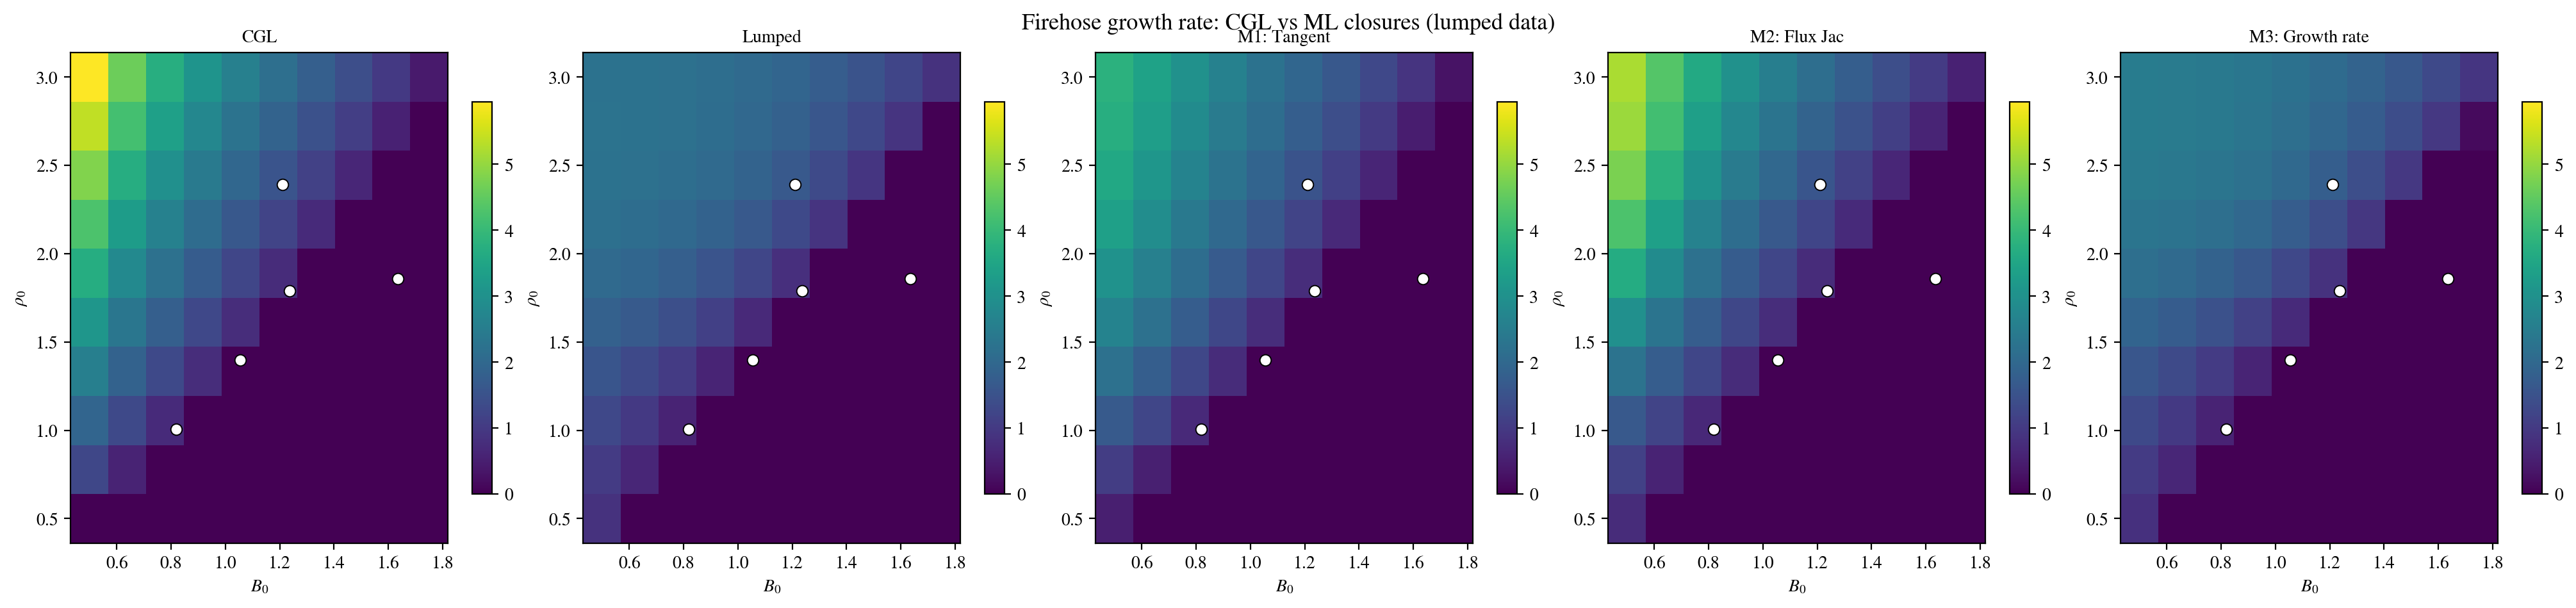


Method               |  mean |Δγ| |   max |Δγ| |  mean rel (unstable) |   max rel (unstable)
------------------------------------------------------------------------------------------
Lumped               |  3.828e-01 |  3.700e+00 |            2.658e-01 |            1.048e+00
M1: Tangent          |  1.663e-01 |  2.148e+00 |            9.749e-02 |            3.610e-01
M2: Flux Jac         |  4.643e-02 |  7.507e-01 |            3.491e-02 |            3.148e-01
M3: Growth rate      |  3.544e-01 |  3.466e+00 |            2.632e-01 |            1.258e+00


In [83]:
# ── Full growth-rate scan: CGL vs Lumped vs all three physics methods ─────
all_models = [
    ('CGL',              True,  None),
    ('Lumped',           False, model),
    ('M1: Tangent',      False, model_phys),
    ('M2: Flux Jac',     False, model_fluxjac),
    ('M3: Growth rate',  False, model_growth),
]

gamma_all = {}
for lbl, use_cgl, net in all_models:
    gamma_all[lbl] = np.zeros_like(B0)
    print(f"Scanning {lbl}...")
    t0 = _time.time()
    for i in range(n_bp):
        for j in range(n_R):
            _, eigs, _, _ = fh.dispersion_from_jacobian(
                rho0=float(RHO[i, j]), u10=0.0, u20=0.0, u30=0.0,
                B1_0=float(B0[i, j]), B2_0=0.0, B3_0=0.0,
                net=net, use_cgl=use_cgl,
            )
            gamma_all[lbl][i, j] = np.max(np.abs(eigs.cpu().numpy().imag))
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  row {i+1}/{n_bp}  ({_time.time()-t0:.1f}s)")
    print(f"  Done in {_time.time()-t0:.1f}s")

# Plot
labels = [lbl for lbl, _, _ in all_models]
fig, axes = plt.subplots(1, len(labels), figsize=(4 * len(labels), 4.5),
                         constrained_layout=True)
vmax = gamma_all['CGL'].max()
vmin = gamma_all['CGL'].min()

for ax, lbl in zip(axes, labels):
    im = ax.pcolormesh(B0, RHO, gamma_all[lbl], shading='auto',
                       cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(campaign_centers[:, 0], campaign_centers[:, 1],
               s=40, c='white', edgecolors='black', linewidths=0.7)
    ax.set_xlabel('$B_0$')
    ax.set_ylabel(r'$\rho_0$')
    ax.set_title(lbl, fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Firehose growth rate: CGL vs ML closures (lumped data)',
             fontsize=13, y=1.02)
plt.show()

# Error table
print(f"\n{'Method':<20s} | {'mean |Δγ|':>10s} | {'max |Δγ|':>10s} | {'mean rel (unstable)':>20s} | {'max rel (unstable)':>20s}")
print('-' * 90)
cgl_gamma = gamma_all['CGL']
unstable = cgl_gamma > 1e-8
for lbl in labels[1:]:
    ae = np.abs(gamma_all[lbl] - cgl_gamma)
    row = f"{lbl:<20s} | {ae.mean():>10.3e} | {ae.max():>10.3e}"
    if unstable.any():
        re = ae[unstable] / cgl_gamma[unstable]
        row += f" | {re.mean():>20.3e} | {re.max():>20.3e}"
    else:
        row += f" | {'N/A':>20s} | {'N/A':>20s}"
    print(row)